## Package Imports

In [3]:
# Package imports
import numpy as np
import pandas as pd
import s4l_v1.document as document
import s4l_v1.materials.database as database
import s4l_v1.model as model
import s4l_v1.simulation.emlf as emlf
import s4l_v1.units as units
from s4l_v1.model import Vec3, Rotation
from s4l_v1 import ReleaseVersion
from s4l_v1 import Unit
import s4l_v1.simulation.neuron as neuron
import importlib
import sys
import s4l_v1.analysis as analysis
import time
import re
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter, FixedLocator, FuncFormatter
import math
import warnings

# Redirect this PATH to wherever 'modules' are stored.
sys.path.append(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.0")
sys.path.append('modules')

# Project module imports
import modules.sim_entities as sim_entities
import modules.material_settings as ms
import modules.boundaries_voxels as bv
import modules.point_sensor_settings as ps
from s4l_v1 import renderer
from s4l_v1.renderer import SetViewDirection, ShowScreenCapture, ZoomToEntity
import os
os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.0")

importlib.reload(sim_entities)
importlib.reload(ms)
importlib.reload(bv)
importlib.reload(ps)

# os.chdir(r"C:\Users\kramerlab\Documents\sim4life9.0_projects")
# os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.0")

# "C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.0\full_body_sim_notebook.ipynb"

ModuleNotFoundError: No module named 's4l_v1'

## Disable Read-Only Entity Property

In [8]:
for i in model.AllEntities():
    if i.Name.__contains__('Vertebra'):
        i.ReadOnly = False
        # i.Selected = True    

## Update Material Parameters

In [30]:
simulation = document.AllSimulations["DV-PU 2"]

freq = 30.0
quasi_static_setup_settings = [x for x in simulation.AllSettings if isinstance(x, emlf.QuasiStaticSetupSettings) and x.Name == "Setup"][0]
quasi_static_setup_settings.Frequency = freq, units.Hz
db = "IT'IS LF 5.0"

simulation.UpdateAllMaterials()

## LF Setup

### Defining Electrode Combinations

In [40]:
electrode_combinations = {
    "DV-U": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_umbilicus_right", "Anode_umbilicus_left"],
    },
    "DV-I": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    "DV-PU": {
        "cathodes": ["Cathode_paraspinal_left", "Cathode_paraspinal_right"],
        "anodes": ["Anode_umbilicus_right", "Anode_umbilicus_left"],
    },
    "DV-PI": {
        "cathodes": ["Cathode_paraspinal_left", "Cathode_paraspinal_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    "DM-C": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_caudal_midline"],
    },
    "DM-R": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_rostral_midline"],
    },
    
    "DM-R - Reversed": {
        "cathodes": ["Anode_rostral_midline"],
        "anodes": ["Cathode_midline"],
    },
    
    "DV-I - Reversed": {
    "cathodes": ["Cathode_midline"],
    "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },    
    
}


In [17]:
electrode_combinations = {
    "DM-C2": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_caudal_midline_2"],
    },
    "DM-R2": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_rostral_midline_2"],
    }
}


In [48]:
electrode_combinations = {

    "DM-R - Reversed": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_rostral_midline_2"],
    },
    
        "DM-C - Reversed": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_rostral_midline_2"],
    }
}


In [2]:
electrode_combinations = {

    "DO-I": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    
    "DO-C": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_caudal_midline"],
    }
}


In [5]:
for i in electrode_combinations.keys():
    print(i)


### Cloning

In [25]:
simulation = document.AllSimulations["DO-I"]

for i in electrode_combinations.keys():
    # if i != 'DV-U':
    if i != 'DO-I':
        new_sim = simulation.Clone()
        new_sim.Name = i
        document.AllSimulations.Add(new_sim)


### Updating Material Settings

In [26]:
def update_material_settings(simulation, Unit, electrode_combinations, model):
    
        # Remove old boundary settings
    for i in list(simulation.AllSettings):
        if i is None:
            continue
        if i.Name == "Gel":
            simulation.RemoveSettings(i)
            
            
    combo = electrode_combinations[simulation.Name]

    cathodes = combo["cathodes"]
    anodes = combo["anodes"]

    gel_components = []

    for name in cathodes:

        gel_name = (f'{name}_gel')
        gel_entity = model.AllEntities()[gel_name]
        gel_components.append(gel_entity)

    for name in anodes:

        gel_name = (f'{name}_gel')
        gel_entity = model.AllEntities()[gel_name]
        gel_components.append(gel_entity)

    # Adding a new MaterialSettings
    material_settings = emlf.MaterialSettings()
    components = gel_components
    material_settings.Name = "Gel"
    material_settings.ElectricProps.Conductivity = 0.6, Unit("S/m")
    material_settings.ElectricProps.RelativePermittivity = 76.5
    simulation.Add(material_settings, components)
    
    simulation.UpdateAllMaterials()
    

In [27]:
for i in electrode_combinations.keys():
    simulation = document.AllSimulations[i]
    update_material_settings(simulation, Unit, electrode_combinations, model)


In [3]:
diaphragm = model.AllEntities()["Diaphragm"]
diaphragm.ReadOnly = 0
diaphragm.Name = 'Diaphragm - corrupted'

### Updating Boundary Settings

In [28]:
def boundary_settings(simulation, units, electrode_combinations, voltage, model):

    # Remove old boundary settings
    for i in list(simulation.AllSettings):
        if i is None:
            continue
        if i.Name.startswith("Cathode") or i.Name.startswith("Anode"):
            simulation.RemoveSettings(i)
 
    combo = electrode_combinations[simulation.Name]

    cathodes = combo["cathodes"]
    anodes = combo["anodes"]
        
    cathode_list = []
    anode_list = []

    for name in cathodes:

        electrode_name = (f'{name}_electrode')
        electrode_entity = model.AllEntities()[electrode_name]
        cathode_list.append(electrode_entity)
        
    cathode_bc = emlf.BoundarySettings()
    cathode_bc.Name = f"Cathode"
    cathode_bc.DirichletValue = -(voltage/2.0), units.Volts
    simulation.Add(cathode_bc, cathode_list)

    for name in anodes:

        electrode_name = (f'{name}_electrode')
        electrode_entity = model.AllEntities()[electrode_name]
        anode_list.append(electrode_entity)
        
    anode_bc = emlf.BoundarySettings()
    anode_bc.Name = f"Anode"
    anode_bc.DirichletValue = (voltage/2.0), units.Volts
    simulation.Add(anode_bc, anode_list)


In [29]:
voltage = 100

for i in electrode_combinations.keys():
    simulation = document.AllSimulations[i]
    boundary_settings(simulation, units, electrode_combinations, voltage, model)


### Updating Grid/Voxel Settings

In [30]:
def electrode_grid_voxels(simulation, units, electrode_combinations, model):
    
    for i in list(simulation.AllSettings):
        if i is None:
            continue
        if i.Name.startswith("Electrode"):
            simulation.RemoveSettings(i)
            
    combo = electrode_combinations[simulation.Name]
    
    cathodes = combo["cathodes"]
    anodes = combo["anodes"]
    
    components = []
    
    for name in cathodes:

        electrode_name = (f'{name}_electrode')
        electrode_entity = model.AllEntities()[electrode_name]
        components.append(electrode_entity)
        
        gel_name = (f'{name}_gel')
        gel_entity = model.AllEntities()[gel_name]
        components.append(gel_entity)
        

    for name in anodes:

        electrode_name = (f'{name}_electrode')
        electrode_entity = model.AllEntities()[electrode_name]
        components.append(electrode_entity)
        
        gel_name = (f'{name}_gel')
        gel_entity = model.AllEntities()[gel_name]
        components.append(gel_entity)
        
        
    # Adding a new AutomaticGridSettings
    automatic_grid_settings = simulation.AddAutomaticGridSettings(components)
    automatic_grid_settings.Name = "Electrodes"
    automatic_grid_settings.AutoRefinement = automatic_grid_settings.AutoRefinement.enum.AutoRefinementVeryFine

        # Adding a new ManualVoxelerSettings
    manual_voxeler_settings = emlf.AutomaticVoxelerSettings()
    manual_voxeler_settings.Name = "Electrode Voxeler Settings"
    manual_voxeler_settings.Priority = 0
    simulation.Add(manual_voxeler_settings, components)
    
    simulation.UpdateGrid()
    

In [31]:
for i in electrode_combinations.keys():
    simulation = document.AllSimulations[i]
    electrode_grid_voxels(simulation, units, electrode_combinations, model)


### Create Voxels

In [106]:
for i in electrode_combinations.keys():
    simulation = document.AllSimulations[i]
    simulation.CreateVoxels()

### Solver Settings

In [26]:
for i in electrode_combinations.keys():
    simulation = document.AllSimulations[i]
    solver_settings = simulation.SolverSettings
    solver_settings.Parallelization = solver_settings.Parallelization.enum.Automatic
    solver_settings.PredefinedTolerances = solver_settings.PredefinedTolerances.enum.UserDefined
    solver_settings.RelativeSolverTolerance = 1.5e-06

## Running Simulations

### Select remote server

In [58]:
# Use this to check for available servers
servers = simulation.GetAvailableServers() 
for server in servers: 
    print(server.Name, server.Description, server.Id)


In [62]:
# Select server by number (make sure you have enough credits to run!)
server_no = 3
server = servers[server_no]
server.Name

'RAM [LARGE]'

## Field Scaling and Normalization

In [46]:
# This takes a while to run!!

for i in electrode_combinations.keys():
    
    simulation = document.AllSimulations[i]

    sim_name = simulation.Name
    simulation_extractor = simulation.Results()
    em_sensor_extractor = simulation_extractor["Overall Field"]
    em_sensor_extractor.FrequencySettings.ExtractedFrequency = u"All"

    em_sensor_extractor.Name = f'Overall Field - {sim_name}'

    document.AllAlgorithms.Add(em_sensor_extractor)

    inputs = [em_sensor_extractor.Outputs["EM Potential(x,y,z,f0)"], em_sensor_extractor.Outputs["J(x,y,z,f0)"]]
    current_extractor = analysis.extractors.CurrentExtractor(inputs=inputs)
    current_extractor.Name = f"Current Extractor - {sim_name}"
    current_extractor.UpdateAttributes()
    document.AllAlgorithms.Add(current_extractor)
    current_extractor.Update()


In [47]:
## Only run this after manually refreshing current extractors

current_to_normalize_to = 0.1 # In Amps
data_list = []

for i in document.AllAlgorithms:
    
    if i.Name.startswith('Current Extractor'):  
        
        print(i.Name)
        current_extractor = i
        c = current_extractor.Outputs["Total Flux(J(x,y,z,f0))"]
        total_unnormalized_current = np.real(c.Data.GetComponent(0)[0])
        i_rms = total_unnormalized_current/np.sqrt(2)
        factor = current_to_normalize_to/i_rms
        
        prefix = "Current Extractor - "
        sim_name = current_extractor.Name.split(prefix, 1)[1]
        em_sensor_extractor = document.AllAlgorithms[f'Overall Field - {sim_name}']
        inputs = [em_sensor_extractor.Outputs["EM Potential(x,y,z,f0)"]]
        # inputs = [em_sensor_extractor.Outputs["EM E(x,y,z,f0)"]]
        multiplier = analysis.core.Multiplier(inputs=inputs)
        multiplier.Name = f'Voltage Multiplier - {sim_name}'
        multiplier.UpdateAttributes()
        multiplier.Factor = factor
        multiplier.UpdateAttributes()
        document.AllAlgorithms.Add(multiplier)
        
        data_list.append({'Sim Name':i.Name, 
                          'I_RMS': i_rms, 
                          'Scaling Factor': factor, 
                          'Impedance': 100/total_unnormalized_current})
      

In [7]:
for i in data_list:
    print(i['Scaling Factor'] * 100)

In [20]:
data_list

[{'Sim Name': 'Current Extractor - DV-U',
  'I_RMS': 0.5456629829376283,
  'Scaling Factor': 0.18326330194077037,
  'Impedance': 129.58672354495647},
 {'Sim Name': 'Current Extractor - DV-I',
  'I_RMS': 0.7404744411526223,
  'Scaling Factor': 0.13504855055407455,
  'Impedance': 95.49374588620037},
 {'Sim Name': 'Current Extractor - DV-PU',
  'I_RMS': 0.6015057870469255,
  'Scaling Factor': 0.16624943957887253,
  'Impedance': 117.55610609468397},
 {'Sim Name': 'Current Extractor - DV-PI',
  'I_RMS': 0.953284921758436,
  'Scaling Factor': 0.10490043188298762,
  'Impedance': 74.17580673385805},
 {'Sim Name': 'Current Extractor - DM-C',
  'I_RMS': 0.6120808949536424,
  'Scaling Factor': 0.16337709741385373,
  'Impedance': 115.52505347191112},
 {'Sim Name': 'Current Extractor - DM-R',
  'I_RMS': 0.7903662788395752,
  'Scaling Factor': 0.12652361655259528,
  'Impedance': 89.46570724458661}]

## NEURON Setup

### Discretizing Nerves

In [9]:
# Select Nerve Trajectories

sciatic_name_patterns = [
    "L5_sciatic_nerve",
    "L5_sciatic_muscular_branches",
    "S1_sciatic_nerve",
    "S1_sciatic_muscular_branches",
    "S2_sciatic_nerve",
    "S2_sciatic_muscular_branches",
    "L5_muscular_branches_of_nerve_sciatic",
    "S1_muscular_branches_of_nerve_sciatic",
    "S2_muscular_branches_of_nerve_sciatic",
]

sciatic_ents = [
    ent for ent in model.AllEntities()
    if any(pat in ent.Name for pat in sciatic_name_patterns)
]


#### Motor Nerves

In [ ]:
# Create 10um motor nerves

motor_props = model.MotorMrgNeuronProperties()
motor_props.AxonDiameter = 10
discretized_motor_10 = model.CreateAxonNeurons(sciatic_ents, motor_props)

model.CreateGroup('Soleus_Nerves_10um')

for i in discretized_motor_10:
    model.AllEntities()['Soleus_Nerves_10um'].Add(i)
    

In [19]:
# Create 15um motor nerves

motor_props = model.MotorMrgNeuronProperties()
motor_props.AxonDiameter = 15
discretized_motor_15 = model.CreateAxonNeurons(sciatic_ents, motor_props)

model.CreateGroup('Soleus_Motor_Nerves_15um')

for i in discretized_motor_15:
    model.AllEntities()['Soleus_Motor_Nerves_15um'].Add(i)
    

In [20]:
# Create 20um motor nerves

motor_props = model.MotorMrgNeuronProperties()
motor_props.AxonDiameter = 20
discretized_motor_20 = model.CreateAxonNeurons(sciatic_ents, motor_props)

model.CreateGroup('Soleus_Motor_Nerves_20um')

for i in discretized_motor_20:
    model.AllEntities()['Soleus_Motor_Nerves_20um'].Add(i)
    

#### Sensory Nerves

In [22]:
# Create 10um motor nerves

sensory_props = model.SensoryMrgNeuronProperties()
sensory_props.AxonDiameter = 10
discretized_motor_10 = model.CreateAxonNeurons(sciatic_ents, sensory_props)

model.CreateGroup('Soleus_Sensory_Nerves_10um')

for i in discretized_motor_10:
    model.AllEntities()['Soleus_Sensory_Nerves_10um'].Add(i)
    

In [23]:
# Create 15um motor nerves

sensory_props = model.SensoryMrgNeuronProperties()
sensory_props.AxonDiameter = 15
discretized_motor_15 = model.CreateAxonNeurons(sciatic_ents, sensory_props)

model.CreateGroup('Soleus_Sensory_Nerves_15um')

for i in discretized_motor_15:
    model.AllEntities()['Soleus_Sensory_Nerves_15um'].Add(i)
    

In [24]:
# Create 20um motor nerves

sensory_props = model.SensoryMrgNeuronProperties()
sensory_props.AxonDiameter = 20
discretized_motor_20 = model.CreateAxonNeurons(sciatic_ents, sensory_props)

model.CreateGroup('Soleus_Sensory_Nerves_20um')

for i in discretized_motor_20:
    model.AllEntities()['Soleus_Sensory_Nerves_20um'].Add(i)
    

### NEURON Simulation Setup

In [9]:
neurosimulation = neuron.Simulation()
neurosimulation.Name = "NEURON - DM-R2"


In [17]:
document.AllSimulations.Add( neurosimulation )

In [64]:
neurosimulation = document.AllSimulations["NEURON - DV-PI"] 

#### Adding Motor Fibers

In [10]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Soleus_Motor_Nerves_10um'

discretized_motor_10 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Soleus_Motor_Nerves_10um':
            discretized_motor_10.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_motor_10);

In [11]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Soleus_Motor_Nerves_15um'

discretized_motor_15 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Soleus_Motor_Nerves_15um':
            discretized_motor_15.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_motor_15);

In [12]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Soleus_Motor_Nerves_20um'

discretized_motor_20 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Soleus_Motor_Nerves_20um':
            discretized_motor_20.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_motor_20);

#### Adding Sensory Fibers

In [13]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Soleus_Sensory_Nerves_10um'

discretized_sensory_10 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Soleus_Sensory_Nerves_10um':
            discretized_sensory_10.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_sensory_10);

In [14]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Soleus_Sensory_Nerves_15um'

discretized_sensory_15 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Soleus_Sensory_Nerves_15um':
            discretized_sensory_15.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_sensory_15);

In [15]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Soleus_Sensory_Nerves_20um'

discretized_sensory_20 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Soleus_Sensory_Nerves_20um':
            discretized_sensory_20.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_sensory_20);

#### Additional Setup

In [18]:
link_0_overall_field = document.AllSimulations["DV-PI"].AllComponents["Overall Field"]

source_settings = neurosimulation.AddGenericSource([link_0_overall_field])

source_settings.DurationP1 = 0.001, units.Seconds
source_settings.PulseType = 0

overall_line_sensor_settings = neuron.OverallLineSensorSettings()
components = []
overall_line_sensor_settings.RecordEExtracellular = False
overall_line_sensor_settings.RecordIMembrane = False
overall_line_sensor_settings.NumberOfSnapshots = 250
neurosimulation.Add(overall_line_sensor_settings, components)

solver_settings = neurosimulation.SolverSettings

solver_settings.Parallelization = solver_settings.Parallelization.enum.Automatic
solver_settings.Duration = 0.006, units.Seconds
solver_settings.TimeStep = 1e-05, units.Seconds


In [20]:
for i in electrode_combinations.keys():
    print(i)

#### Cloning

In [18]:
neurosimulation = document.AllSimulations["NEURON - DV-PI"] 

for i in electrode_combinations.keys():
    if i != 'DV-PI':
        
        new_sim = neurosimulation.Clone()
        new_sim.Name = (f'NEURON - {i}')
                        
        ss = new_sim.AllSettings['Source Settings']
        if ss != None:
            new_sim.RemoveSettings(ss)
                        
        link_0_overall_field = document.AllSimulations[i].AllComponents["Overall Field"]

        # Adding a new SourceSettings
        source_settings = new_sim.AddGenericSource([])
        source_settings.SourceType = source_settings.SourceType.enum.DataObject
        source_settings.SourceDataObject.DataOriginType = source_settings.SourceDataObject.DataOriginType.enum.Pipeline
        source_settings.SourceDataObject.DataOrigin = document.AllAlgorithms[f"Voltage Multiplier - {i}"].Outputs[0].raw
        source_settings.InitialTime = 0.001, units.Seconds
        source_settings.DurationP1 = 0.001, units.Seconds
        source_settings.AmplitudeP1 = 1
        source_settings.PulseType = 0

        document.AllSimulations.Add(new_sim)


In [21]:
# neurosimulation = document.AllSimulations["NEURON - DV-PI"] 

for i in electrode_combinations.keys():
    if i != 'DV-PI':
        
        # new_sim = neurosimulation.Clone()
        # new_sim.Name = (f'NEURON - {i}')
        
        new_sim = document.AllSimulations["NEURON - DM-R2"]               
        ss = new_sim.AllSettings['Source Settings']
        if ss != None:
            new_sim.RemoveSettings(ss)
                        
        link_0_overall_field = document.AllSimulations[i].AllComponents["Overall Field"]

        # Adding a new SourceSettings
        source_settings = new_sim.AddGenericSource([])
        source_settings.SourceType = source_settings.SourceType.enum.DataObject
        source_settings.SourceDataObject.DataOriginType = source_settings.SourceDataObject.DataOriginType.enum.Pipeline
        source_settings.SourceDataObject.DataOrigin = document.AllAlgorithms[f"Voltage Multiplier - {i}"].Outputs[0].raw
        source_settings.InitialTime = 0.001, units.Seconds
        source_settings.DurationP1 = 0.001, units.Seconds
        source_settings.AmplitudeP1 = 1
        source_settings.PulseType = 0

        # document.AllSimulations.Add(new_sim)


### Field Scaling and Normalization

In [11]:
# This takes a while to run!!

for i in electrode_combinations.keys():
    
    simulation = document.AllSimulations[i]

    sim_name = simulation.Name
    simulation_extractor = simulation.Results()
    em_sensor_extractor = simulation_extractor["Overall Field"]
    em_sensor_extractor.FrequencySettings.ExtractedFrequency = u"All"

    em_sensor_extractor.Name = f'Overall Field - {sim_name}'

    document.AllAlgorithms.Add(em_sensor_extractor)

    inputs = [em_sensor_extractor.Outputs["EM Potential(x,y,z,f0)"], em_sensor_extractor.Outputs["J(x,y,z,f0)"]]
    current_extractor = analysis.extractors.CurrentExtractor(inputs=inputs)
    current_extractor.Name = f"Current Extractor - {sim_name}"
    current_extractor.UpdateAttributes()
    document.AllAlgorithms.Add(current_extractor)
    current_extractor.Update()


In [12]:
## Only run this after manually refreshing current extractors

current_to_normalize_to = 0.1 # In Amps
data_list = []

for i in document.AllAlgorithms:
    
    if i.Name.startswith('Current Extractor'):  
        
        print(i.Name)
        current_extractor = i
        c = current_extractor.Outputs["Total Flux(J(x,y,z,f0))"]
        total_unnormalized_current = np.real(c.Data.GetComponent(0)[0])
        i_rms = total_unnormalized_current/np.sqrt(2)
        factor = current_to_normalize_to/i_rms
        
        prefix = "Current Extractor - "
        sim_name = current_extractor.Name.split(prefix, 1)[1]
        em_sensor_extractor = document.AllAlgorithms[f'Overall Field - {sim_name}']
        inputs = [em_sensor_extractor.Outputs["EM Potential(x,y,z,f0)"]]
        # inputs = [em_sensor_extractor.Outputs["EM E(x,y,z,f0)"]]
        multiplier = analysis.core.Multiplier(inputs=inputs)
        multiplier.Name = f'Voltage Multiplier - {sim_name}'
        multiplier.UpdateAttributes()
        multiplier.Factor = factor
        multiplier.UpdateAttributes()
        document.AllAlgorithms.Add(multiplier)
        
        data_list.append({'Sim Name':i.Name, 
                          'I_RMS': i_rms, 
                          'Scaling Factor': factor, 
                          'Impedance': 100/total_unnormalized_current})
      

In [16]:
for i in data_list:
    print(i['Scaling Factor'] * 100)

## Data Extraction and Analysis

### Titration Sensor Extraction

In [73]:
# For Cole: Fix this, make it automatically check if sensors are present. If they are, use the necessary internal functions to extract that data.

def Neuron_Data_Extraction(sim_name):
    
    def tit_extract(name):
        simulation = document.AllSimulations[name]
        simulation_extractor = simulation.Results()
        simulation_extractor.UpdateAttributes()
        simulation_extractor.UpdateAll()
        
        combo = sim_name.split(' - ')[1]

        exists = any(getattr(alg, "Name", None) == f'Titration Sensor - {combo}'
                 for alg in document.AllAlgorithms)
        print (exists)

        if exists:

            print("found it")
            target = f'Titration Sensor - {combo}'

            idx = next(
                (i for i, alg in enumerate(document.AllAlgorithms)
                 if getattr(alg, "Name", None) == target),
                -1  # return -1 if not found
            )
            # print(idx)  # e.g., 7, or -1 if absent
            tit_sensor = document.AllAlgorithms[idx]
            titration_evaluator = document.AllAlgorithms[idx+1]

            document.AllAlgorithms.Remove(tit_sensor)
            document.AllAlgorithms.Remove(titration_evaluator)


        sensor_extractor = simulation_extractor["Titration Sensor"]
        sensor_extractor.Name = f'Titration Sensor - {combo}'
        document.AllAlgorithms.Add(sensor_extractor)
        titration_evaluator = document.AllAlgorithms[f'Titration Evaluator - {combo}']
        inputs = [sensor_extractor.Outputs["Titration"]]
        titration_evaluator = analysis.neuron_evaluators.TitrationEvaluator(inputs=inputs)
        titration_evaluator.UpdateAttributes()
        titration_evaluator.UpdateAll()
        document.AllAlgorithms.Add(titration_evaluator)

        return titration_evaluator

    def titration_eval(combo, freq, total_unnormalized_current, document, titration_evaluator):
    
        titration_data = pd.DataFrame(columns = ['NeuronName', 
                                                 'NeuronType', 
                                                 'Fibre_Diameter', 
                                                 'Location', 
                                                 'Electrode_Config', 
                                                 'Frequency', 
                                                 'Titration_Factor', 
                                                 'Activation_Threshold (mA)',
                                                 'First_Spike_Loc'])

        tit_data = []

        for i in range(len(titration_evaluator.TitrationData())):

            neuron_name = titration_evaluator.TitrationData()[i].NeuronName
            spike_loc = titration_evaluator.LocationOfFirstSpike[i]
            titration_factor = titration_evaluator.TitrationData()[i].TitrationFactor
            a_t = titration_factor * total_unnormalized_current * 1000

            after = neuron_name.split("root_", 1)[1]
            location = "_".join(after.split("_", 2)[:2])  # "T11_left"

            match = re.search(r'\[(.*?)\]', neuron_name)
            if match:
                neuron_type = match.group(1)  # Text inside the brackets

            m = re.match(r'^(.*\S)\s+([+-]?\d+(?:\.\d+)?\s*(?:um|µm|mm|nm|m)?)\s*$', neuron_type, re.IGNORECASE)

            fibre_type = m.group(1)        # "Sensory MRG Neuron"
            fibre_diameter = m.group(2)

            tit_data.append({'NeuronName': neuron_name,
                            'NeuronType': fibre_type,
                            'Fibre_Diameter': fibre_diameter,
                            'Location': location,
                            'Electrode_Config': combo,
                            'Frequency' : freq,
                            'Titration_Factor' : titration_factor,
                             'Activation_Threshold (mA)' : a_t,
                             'First_Spike_Loc' : spike_loc
                            })

        titration_data = pd.concat([titration_data, pd.DataFrame(tit_data)], ignore_index=True)
        titration_data = titration_data.sort_values(by="Activation_Threshold (mA)", ascending=True)

        return titration_data
     
    os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher")

    simulation = document.AllSimulations[sim_name]
    combo = sim_name.split('RON - ')[1]
    folder_name = combo

    try:
        os.mkdir(folder_name)
    except:
        pass

    base = r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher"
    subdir_path = os.path.join(base, folder_name)
    
    try:
        titration_evaluator = tit_extract(sim_name)
        freq = 30
        total_unnormalized_current = 0.1
        now = datetime.datetime.now()
        s2 = now.strftime("%Y_%m_%d")
        note = ''

        titration_df = titration_eval(combo,freq, total_unnormalized_current, document, titration_evaluator)

        table_name = (f'Titration - {combo} {s2} {note}.csv')
        csv_path = os.path.join(subdir_path, table_name)

        print(csv_path)
        titration_df.to_csv(csv_path)
    except:
        csv_path = None
        pass
                  
    return csv_path


In [3]:
for i in electrode_combinations.keys():
    sim_name = f'NEURON - {i}'
    test_path = Neuron_Data_Extraction(sim_name)


SyntaxError: invalid syntax (708557963.py, line 3)

In [34]:
sim_name = 'NEURON - DV-I - Reversed'
test_path = Neuron_Data_Extraction(sim_name)
test_path

'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2\\Simulation_Results\\Thatcher\\DV-I\\Titration - DV-I 2026_01_23 .csv'

### Graphing

#### Fitter Functions

In [6]:
# ---------- models ----------
def logistic_01(x, i50, slope):
    """0–100% logistic: i50 in mA, slope in mA (larger -> shallower)."""
    x = np.asarray(x, float)
    return 100.0 / (1.0 + np.exp(-(x - i50) / max(slope, 1e-12)))

def logistic_4pl(x, bottom, top, i50, slope):
    """4-parameter logistic (bottom/top in %, i50/slope in mA)."""
    x = np.asarray(x, float)
    return bottom + (top - bottom) / (1.0 + np.exp(-(x - i50) / max(slope, 1e-12)))

# ---------- helpers ----------
def build_ecdf_from_thresholds(thresholds_mA: np.ndarray):
    """Returns x=unique thresholds, y=% fibers ≤ threshold (0–100)."""
    th = np.sort(np.asarray(thresholds_mA, dtype=float))
    if th.size == 0:
        return np.array([]), np.array([])
    uniq, counts = np.unique(th, return_counts=True)
    cum = np.cumsum(counts) / th.size * 100.0
    return uniq, cum

def fit_logistic(x, y, use_4pl=False):
    """Fits either the fixed 0–100 logistic or a 4PL; falls back to linear if too few points."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    if len(x) < 4:
        coef = np.polyfit(x, y, 1)
        return {"model": "linear", "params": coef}

    i50_guess   = np.median(x)
    slope_guess = max((np.percentile(x, 75) - np.percentile(x, 25)) / 4.0, 1e-2)

    if not use_4pl:
        p0 = [i50_guess, slope_guess]
        bounds = ([-np.inf, 1e-6], [np.inf, np.inf])
        popt, _ = curve_fit(logistic_01, x, y, p0=p0, bounds=bounds, maxfev=20000)
        return {"model": "logistic_01", "params": popt}
    else:
        bottom_guess = max(0.0, y.min())
        top_guess    = min(100.0, y.max())
        p0 = [bottom_guess, top_guess, i50_guess, slope_guess]
        bounds = ([-5.0,  50.0, -np.inf, 1e-6],
                  [10.0, 120.0,  np.inf,  np.inf])
        popt, _ = curve_fit(logistic_4pl, x, y, p0=p0, bounds=bounds, maxfev=20000)
        return {"model": "logistic_4pl", "params": popt}
    

def decade_ticks_from_data(data, min_decade=10):
    """
    Make ticks that step by 10^k within each decade:
      10–100 -> step 10, 100–1000 -> step 100, etc.
    Falls back to 1-step ticks if all data < min_decade.
    """
    data = np.asarray(data)
    vmin = float(np.nanmin(data))
    vmax = float(np.nanmax(data))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return []
    if vmin == vmax:
        return [vmin]

    # If everything is below 10, just use 1-step integers.
    if vmax < min_decade:
        lo = math.floor(vmin)
        hi = math.ceil(vmax)
        return list(range(lo, hi + 1))

    # Build ticks per decade with step = 10^k
    k_start = int(math.floor(math.log10(max(min_decade, vmin))))
    k_end   = int(math.floor(math.log10(max(min_decade, vmax))))
    ticks = []
    for k in range(k_start, k_end + 1):
        step = 10 ** k
        start = math.ceil(vmin / step) * step
        end   = math.floor(vmax / step) * step
        if start <= end:
            ticks.extend(np.arange(start, end + 0.5 * step, step).tolist())
    return sorted(set(ticks))



def decade_ticks_from_minmax(vmin, vmax):
    """
    Decade ticks for log-x:
      - If vmin < 10, include 1..9.
      - For each decade 10^k (k>=1), include multiples m*10^k for m=1..9.
      - Extend the upper bound to the *next* power-of-10 above vmax, so
        vmax=820 -> ticks include ... 100,200,...,900, 1000.
    """
    vmin = float(vmin); vmax = float(vmax)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        return []

    if vmin > vmax:
        vmin, vmax = vmax, vmin

    # Lower bound snapped to decade (or 1 if below 10)
    low = 1.0 if vmin < 10 else 10 ** int(np.floor(np.log10(vmin)))
    # Upper bound is the NEXT power of 10 above vmax
    high_pow = int(np.floor(np.log10(max(1.0, vmax)))) + 1
    high = 10 ** high_pow

    ticks = []

    # Include 1..9 if we start below 10
    if low < 10:
        ticks.extend(range(1, 10))  # 1..9

    # Add decade multiples for k = 1 .. high_pow-1 (i.e., up to just below 'high')
    for k in range(1, high_pow):
        base = 10 ** k
        ticks.extend([m * base for m in range(1, 10)])  # 10..90, 100..900, ...

    # Include the top boundary (10^high_pow)
    ticks.append(high)

    # Keep ticks within [low, high]
    ticks = [t for t in ticks if low <= t <= high]
    return ticks


#### Plot recruitment by group multi DF function

In [7]:
# Reuses your original helpers:
# logistic_01, logistic_4pl, build_ecdf_from_thresholds, fit_logistic,
# decade_ticks_from_minmax
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

def _normalize_key(s: str) -> str:
    return re.sub(r"[ _/]+", "", str(s)).lower()

def _resolve_columns(df: pd.DataFrame,
                     want_cols: list[str],
                     aliases: dict[str, list[str]] | None = None) -> dict[str, str]:
    aliases = aliases or {}
    norm_map = {_normalize_key(c): c for c in df.columns}
    resolved = {}
    for w in want_cols:
        candidates = [w] + aliases.get(w, [])
        for cand in candidates:
            key = _normalize_key(cand)
            if key in norm_map:
                resolved[w] = norm_map[key]
                break
    return resolved

def _format_um(val) -> str:
    """'20.00um'/'20 um'/20 -> '20 µm' (exactly once)."""
    if pd.isna(val):
        return "NA"
    s = str(val)
    m = re.search(r"(\d+(?:\.\d+)?)", s)
    if m:
        try:
            return f"{int(round(float(m.group(1))))} \u00b5m"
        except Exception:
            pass
    s = s.replace("µm","").replace("um","").strip()
    return f"{s} \u00b5m" if s else "NA"

def _short_label(s: str) -> str:
    """
    Compact legend labels:
      - 'Montage 3' -> 'M3'
      - 'Config 12A' -> 'C12A'
      - else: first token (<= 6 chars)
    """
    m = re.match(r"\s*(Montage|Config|Set)\s*([A-Za-z0-9]+)", s, flags=re.I)
    if m:
        return f"{m.group(1)[0].upper()}{m.group(2)}"
    t0 = re.split(r"\s+", s.strip())[0]
    return t0[:6]

def _focused_xlim(all_vals: np.ndarray,
                  focus_pct: float | None,
                  pad_lo=1.1, pad_hi=1.1) -> tuple[float,float]:
    """
    Return (xlo, xhi) used for axes limits only (not for fitting).
    Uses central focus_pct (e.g., 0.95) of the data and multiplicative padding.
    Always clipped inside the global [min..max] to avoid weird truncations.
    """
    v = np.asarray(all_vals, float)
    v = v[np.isfinite(v)]
    v = v[v > 0]  # log-safe
    if v.size == 0:
        return (1.0, 10.0)

    global_lo, global_hi = float(np.min(v)), float(np.max(v))
    if not (focus_pct is not None and 0.0 < focus_pct < 1.0 and v.size >= 10):
        return (global_lo, global_hi)

    p = (1.0 - focus_pct) * 50.0
    lo = float(np.percentile(v, p)) / pad_lo
    hi = float(np.percentile(v, 100.0 - p)) * pad_hi
    # keep inside global bounds and well-ordered
    lo = max(lo, global_lo * (1.0 / pad_lo))
    hi = min(hi, global_hi * pad_hi)
    if hi <= lo:
        lo, hi = global_lo, global_hi
    # tiny guard so lo>0
    lo = max(lo, np.nextafter(0, 1))
    return lo, hi

def plot_recruitment_by_group_multi(
    dfs: list[pd.DataFrame],
    labels: list[str] | None = None,
    threshold_col: str = "Activation_Threshold (mA)",
    group_cols: list | str = ("NeuronType", "Fibre_Diameter"),
    title: str = "Recruitment (ECDF + logistic fit) across electrode configurations",
    use_4pl: bool = False,

    # show/hide controls
    show_points: bool = True,
    show_fit: bool = True,

    # layout: vertical stack (wide panels)
    ncols: int = 1,
    figsize_per_subplot=(11.5, 4.4),

    # focus the view window but NEVER the fit domain
    # set to None to disable focusing (use full min..max)
    focus_pct: float | None = 0.95,

    # per-axes legend controls
    legend_loc: str = "upper left",   # inside each axes
    legend_ncol: int = 2,
    legend_fontsize: int = 8,
    legend_compact: bool = True,      # short labels like 'M1'
):
    """Overlay ECDF + logistic fits for any number of DataFrames, grouped by fibre type/diameter."""

    assert isinstance(dfs, (list, tuple)) and len(dfs) >= 1, "Provide at least one DataFrame."

    # group_cols normalized
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    elif isinstance(group_cols, tuple):
        group_cols = list(group_cols)

    # aliases for common schema variants
    alias_map = {
        "Activation_Threshold (mA)": [
            "Activation_Threshold(mA)", "Activation_Threshold", "Threshold_mA",
            "activation_threshold_ma", "activation threshold (ma)"
        ],
        "NeuronType": ["Neuron Type", "neuron_type"],
        "Fibre_Diameter": ["Fibre Diameter", "Fiber_Diameter", "Fiber Diameter", "fibre_diameter_um", "Diameter_um"],
    }

    # labels
    if labels is None:
        labels = [f"Set {i+1}" for i in range(len(dfs))]
    else:
        assert len(labels) == len(dfs), "labels must match number of dfs."

    short_labels = [(_short_label(l) if legend_compact else l) for l in labels]

    # standardize each df
    dfs_clean = []
    for idx, df in enumerate(dfs):
        d = df.copy()
        col_map = _resolve_columns(d, [threshold_col] + list(group_cols), aliases=alias_map)
        if threshold_col not in col_map:
            raise KeyError(f"Could not find '{threshold_col}' (with aliases) in dfs[{idx}]. "
                           f"Available columns: {list(df.columns)}")

        d.rename(columns={col_map[threshold_col]: "Activation_Threshold (mA)"}, inplace=True)
        d["Activation_Threshold (mA)"] = pd.to_numeric(
            d["Activation_Threshold (mA)"], errors="coerce"
        ).astype(float)

        for g in group_cols:
            if g in col_map:
                d.rename(columns={col_map[g]: g}, inplace=True)
            elif g not in d.columns:
                warnings.warn(f"dfs[{idx}] missing group column '{g}'. Creating NA-filled column.")
                d[g] = pd.NA
        dfs_clean.append(d)

    # groups across all dfs
    all_groups = set()
    for d in dfs_clean:
        for gvals, _ in d.groupby(group_cols, dropna=False):
            gvals_t = gvals if isinstance(gvals, tuple) else (gvals,)
            all_groups.add(tuple(gvals_t))
    all_groups = sorted(all_groups, key=lambda t: tuple("" if pd.isna(x) else str(x) for x in t))
    if not all_groups:
        raise ValueError("No groups found in the provided dataframes.")

    # layout
    n_groups = len(all_groups)
    ncols = max(1, int(ncols))
    nrows = int(np.ceil(n_groups / ncols))
    fig_w = figsize_per_subplot[0] * ncols
    fig_h = figsize_per_subplot[1] * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(fig_w, fig_h), dpi=120,
                             constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    # styles
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()
    base_colors = prop_cycle.get("color", ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"])
    colors = [base_colors[i % len(base_colors)] for i in range(len(dfs_clean))]
    marker_styles = ["o","s","^","D","v","P","X","h","*",">","<"]
    line_style = "-"

    fit_rows = []

    def _title_from_groupvals(keys, vals) -> str:
        vals = vals if isinstance(vals, tuple) else (vals,)
        kind = "NA"; diam = "NA"
        for k, v in zip(keys, vals):
            if k == "NeuronType":
                kind = "NA" if pd.isna(v) else str(v)
            elif k == "Fibre_Diameter":
                diam = _format_um(v)
        return f"{kind} — {diam}"

    # plot
    for gi, gvals in enumerate(all_groups):
        ax = axes[gi]
        ax.grid(True, alpha=0.3)
        ax.set_title(_title_from_groupvals(group_cols, gvals), fontsize=12)

        # thresholds for this group across all datasets
        per_df_thr = []
        for d in dfs_clean:
            sub = d
            for col, val in zip(group_cols, gvals):
                sub = sub[sub[col].isna()] if pd.isna(val) else sub[sub[col] == val]
            if not sub.empty:
                per_df_thr.append(sub["Activation_Threshold (mA)"].dropna().values)

        if not per_df_thr:
            ax.set_visible(False)
            continue

        all_thr = np.concatenate(per_df_thr)
        # ---- fit domain: ALWAYS the full group range (with gentle padding) ----
        global_lo, global_hi = float(np.nanmin(all_thr)), float(np.nanmax(all_thr))
        # multiplicative padding so curves don’t kiss the frame
        x_fit_lo = max(np.nextafter(0, 1), global_lo / 1.25)
        x_fit_hi = global_hi * 1.25
        x_fit = np.linspace(x_fit_lo, x_fit_hi, 600)

        # ---- view window: optional focus, independent from fit domain ----
        view_lo, view_hi = _focused_xlim(all_thr, focus_pct=focus_pct, pad_lo=1.1, pad_hi=1.1)

        # collect legend handles per-axes (compact, inside axes)
        leg_handles, leg_labels = [], []

        for di, (lab, slab, d) in enumerate(zip(labels, short_labels, dfs_clean)):
            sub = d
            for col, val in zip(group_cols, gvals):
                sub = sub[sub[col].isna()] if pd.isna(val) else sub[sub[col] == val]

            th = sub["Activation_Threshold (mA)"].dropna().astype(float).values
            if th.size == 0:
                continue

            xd, yd = build_ecdf_from_thresholds(th)

            if show_points:
                h_data = ax.plot(
                    xd, yd, linestyle="None",
                    marker=marker_styles[di % len(marker_styles)],
                    ms=3.5, alpha=0.8, color=colors[di], label=slab
                )[0]
                leg_handles.append(h_data); leg_labels.append(slab)

            if show_fit:
                fit = fit_logistic(xd, yd, use_4pl=use_4pl)
                if fit["model"] == "linear":
                    y_line = np.poly1d(fit["params"])(x_fit)
                elif fit["model"] == "logistic_01":
                    i50, slope = fit["params"]
                    y_line = logistic_01(x_fit, i50, slope)
                    row = {k: v for k, v in zip(group_cols, gvals)}
                    row.update({"Dataset": lab, "model": "logistic_01",
                                "i50_mA": i50, "slope_mA": slope, "n_fibers": int(th.size)})
                    fit_rows.append(row)
                else:
                    bottom, top, i50, slope = fit["params"]
                    y_line = logistic_4pl(x_fit, bottom, top, i50, slope)
                    row = {k: v for k, v in zip(group_cols, gvals)}
                    row.update({"Dataset": lab, "model": "logistic_4pl",
                                "bottom_%": bottom, "top_%": top,
                                "i50_mA": i50, "slope_mA": slope, "n_fibers": int(th.size)})
                    fit_rows.append(row)

                h_fit = ax.plot(x_fit, y_line, line_style, lw=2.2, color=colors[di], label=slab)[0]
                # if we are showing both points and fits, don’t duplicate labels – keep only one entry
                if not show_points:
                    leg_handles.append(h_fit); leg_labels.append(slab)

        # axes cosmetics
        ax.set_ylabel("% fibers recruited")
        ax.set_xlabel("Activation current (mA)")
        ax.set_ylim(-2, 102)
        ax.set_xscale("log")

        # ticks from the **view** window
        ticks = decade_ticks_from_minmax(view_lo, view_hi)
        if ticks:
            ax.set_xlim(min(ticks), max(ticks))
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v):d}"))
        else:
            ax.set_xlim(view_lo, view_hi)

        for lab_tick in ax.get_xticklabels():
            lab_tick.set_rotation(45); lab_tick.set_fontsize(8)

        # per-axes legend (inside, compact)
        if (show_points or show_fit) and len(leg_handles) > 0:
            ax.legend(
                leg_handles, leg_labels,
                loc=legend_loc, frameon=False, ncol=legend_ncol, fontsize=legend_fontsize
            )

    # hide any extra axes
    for j in range(gi + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13)

    # build fit table
    fit_table = pd.DataFrame(fit_rows)
    if not fit_table.empty and "Fibre_Diameter" in fit_table.columns:
        with pd.option_context('mode.chained_assignment', None):
            fit_table["Fibre_Diameter"] = pd.to_numeric(
                fit_table["Fibre_Diameter"], errors="coerce"
            ).round().astype("Int64")
    if not fit_table.empty:
        fit_table = fit_table.sort_values(["Dataset"] + list(group_cols),
                                          kind="stable", ignore_index=True)
    return fit_table, fig, {k: v for k, v in zip(all_groups, axes)}


In [8]:
def plot_recruitment_by_group_multi(
    dfs: list[pd.DataFrame],
    labels: list[str] | None = None,
    threshold_col: str = "Activation_Threshold (mA)",
    group_cols: list | str = ("NeuronType", "Fibre_Diameter"),
    title: str = "Recruitment (ECDF + logistic fit) across electrode configurations",
    use_4pl: bool = False,

    # show/hide controls
    show_points: bool = True,
    show_fit: bool = True,

    # kept for compatibility (overridden by forced layout below)
    ncols: int = 1,
    figsize_per_subplot=(11.5, 4.4),

    focus_pct: float | None = 0.95,

    legend_loc: str = "upper left",
    legend_ncol: int = 2,
    legend_fontsize: int = 8,
    legend_compact: bool = True,
):
    """
    Overlay ECDF + logistic fits for any number of DataFrames, grouped by fibre type/diameter.

    Forced layout:
      - 3 rows (Fibre_Diameter): 20um (top), 15um (middle), 10um (bottom)
      - 2 cols (NeuronType): Motor (left), Sensory (right)

    Cosmetics:
      - X-axis label shown only on bottom row
      - Y-axis label shown only on left column
    """

    assert isinstance(dfs, (list, tuple)) and len(dfs) >= 1, "Provide at least one DataFrame."

    # -------------------------
    # Normalize group_cols
    # -------------------------
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    elif isinstance(group_cols, tuple):
        group_cols = list(group_cols)

    # aliases for common schema variants
    alias_map = {
        "Activation_Threshold (mA)": [
            "Activation_Threshold(mA)", "Activation_Threshold", "Threshold_mA",
            "activation_threshold_ma", "activation threshold (ma)"
        ],
        "NeuronType": ["Neuron Type", "neuron_type"],
        "Fibre_Diameter": ["Fibre Diameter", "Fiber_Diameter", "Fiber Diameter", "fibre_diameter_um", "Diameter_um"],
    }

    # -------------------------
    # Labels
    # -------------------------
    if labels is None:
        labels = [f"Set {i+1}" for i in range(len(dfs))]
    else:
        assert len(labels) == len(dfs), "labels must match number of dfs."

    short_labels = [(_short_label(l) if legend_compact else l) for l in labels]

    # -------------------------
    # Standardize each df
    # -------------------------
    dfs_clean = []
    for idx, df in enumerate(dfs):
        d = df.copy()
        col_map = _resolve_columns(d, [threshold_col] + list(group_cols), aliases=alias_map)
        if threshold_col not in col_map:
            raise KeyError(
                f"Could not find '{threshold_col}' (with aliases) in dfs[{idx}]. "
                f"Available columns: {list(df.columns)}"
            )

        d.rename(columns={col_map[threshold_col]: "Activation_Threshold (mA)"}, inplace=True)
        d["Activation_Threshold (mA)"] = pd.to_numeric(
            d["Activation_Threshold (mA)"], errors="coerce"
        ).astype(float)

        for g in group_cols:
            if g in col_map:
                d.rename(columns={col_map[g]: g}, inplace=True)
            elif g not in d.columns:
                warnings.warn(f"dfs[{idx}] missing group column '{g}'. Creating NA-filled column.")
                d[g] = pd.NA

        dfs_clean.append(d)

    # -------------------------
    # Collect all groups
    # -------------------------
    all_groups = set()
    for d in dfs_clean:
        for gvals, _ in d.groupby(group_cols, dropna=False):
            gvals_t = gvals if isinstance(gvals, tuple) else (gvals,)
            all_groups.add(tuple(gvals_t))

    if not all_groups:
        raise ValueError("No groups found in the provided dataframes.")

    # -------------------------
    # Helpers to extract group entries
    # -------------------------
    def _get_from_group(gvals, key):
        for k, v in zip(group_cols, gvals):
            if k == key:
                return v
        return pd.NA

    # -------------------------
    # Forced 3x2 grid order
    # -------------------------
    neuron_order = ["Motor MRG Neuron", "Sensory MRG Neuron"]

    # Force the requested diameter order: 20, 15, 10 (top → bottom)
    diameter_order = ["20.00um", "15.00um", "10.00um"]
    unique_diams = [
        d for d in diameter_order
        if any(_get_from_group(g, "Fibre_Diameter") == d for g in all_groups)
    ]

    # Build ordered group list row-major: for each diameter, Motor then Sensory
    ordered_groups = []
    for diam in unique_diams:
        for nt in neuron_order:
            found = None
            for g in all_groups:
                if (_get_from_group(g, "NeuronType") == nt) and (_get_from_group(g, "Fibre_Diameter") == diam):
                    found = g
                    break
            ordered_groups.append(found)  # may be None if missing; we'll hide that axes

    nrows = len(unique_diams)
    ncols_forced = 2

    fig_w = figsize_per_subplot[0] * ncols_forced
    fig_h = figsize_per_subplot[1] * nrows

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols_forced,
        figsize=(fig_w, fig_h),
        dpi=120,
        constrained_layout=True
    )

    axes = np.atleast_2d(axes)

    # styles
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()
    base_colors = prop_cycle.get("color", ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"])
    colors = [base_colors[i % len(base_colors)] for i in range(len(dfs_clean))]
    marker_styles = ["o","s","^","D","v","P","X","h","*",">","<"]
    line_style = "-"

    fit_rows = []

    def _title_from_groupvals(keys, vals) -> str:
        vals = vals if isinstance(vals, tuple) else (vals,)
        kind = "NA"; diam = "NA"
        for k, v in zip(keys, vals):
            if k == "NeuronType":
                kind = "NA" if pd.isna(v) else str(v)
            elif k == "Fibre_Diameter":
                diam = _format_um(v)
        return f"{kind} — {diam}"

    axes_dict = {}

    # -------------------------
    # Plot each slot
    # -------------------------
    for idx_g, gvals in enumerate(ordered_groups):
        r = idx_g // ncols_forced
        c = idx_g % ncols_forced
        ax = axes[r, c]

        # Missing slot: hide
        if gvals is None:
            ax.set_visible(False)
            continue

        axes_dict[gvals] = ax
        ax.grid(True, alpha=0.3)
        ax.set_title(_title_from_groupvals(group_cols, gvals), fontsize=12)

        # thresholds for this group across all datasets
        per_df_thr = []
        for d in dfs_clean:
            sub = d
            for col, val in zip(group_cols, gvals):
                sub = sub[sub[col].isna()] if pd.isna(val) else sub[sub[col] == val]
            if not sub.empty:
                per_df_thr.append(sub["Activation_Threshold (mA)"].dropna().values)

        if not per_df_thr:
            ax.set_visible(False)
            continue

        all_thr = np.concatenate(per_df_thr)

        # Fit domain: ALWAYS full range (with padding)
        global_lo, global_hi = float(np.nanmin(all_thr)), float(np.nanmax(all_thr))
        x_fit_lo = max(np.nextafter(0, 1), global_lo / 1.25)
        x_fit_hi = global_hi * 1.25
        x_fit = np.linspace(x_fit_lo, x_fit_hi, 600)

        # View window: optional focus
        view_lo, view_hi = _focused_xlim(all_thr, focus_pct=focus_pct, pad_lo=1.1, pad_hi=1.1)

        leg_handles, leg_labels = [], []

        for di, (lab, slab, d) in enumerate(zip(labels, short_labels, dfs_clean)):
            sub = d
            for col, val in zip(group_cols, gvals):
                sub = sub[sub[col].isna()] if pd.isna(val) else sub[sub[col] == val]

            th = sub["Activation_Threshold (mA)"].dropna().astype(float).values
            if th.size == 0:
                continue

            xd, yd = build_ecdf_from_thresholds(th)

            if show_points:
                h_data = ax.plot(
                    xd, yd, linestyle="None",
                    marker=marker_styles[di % len(marker_styles)],
                    ms=3.5, alpha=0.8, color=colors[di], label=slab
                )[0]
                leg_handles.append(h_data)
                leg_labels.append(slab)

            if show_fit:
                fit = fit_logistic(xd, yd, use_4pl=use_4pl)

                if fit["model"] == "linear":
                    y_line = np.poly1d(fit["params"])(x_fit)

                elif fit["model"] == "logistic_01":
                    i50, slope = fit["params"]
                    y_line = logistic_01(x_fit, i50, slope)
                    row = {k: v for k, v in zip(group_cols, gvals)}
                    row.update({
                        "Dataset": lab, "model": "logistic_01",
                        "i50_mA": i50, "slope_mA": slope,
                        "n_fibers": int(th.size)
                    })
                    fit_rows.append(row)

                else:
                    bottom, top, i50, slope = fit["params"]
                    y_line = logistic_4pl(x_fit, bottom, top, i50, slope)
                    row = {k: v for k, v in zip(group_cols, gvals)}
                    row.update({
                        "Dataset": lab, "model": "logistic_4pl",
                        "bottom_%": bottom, "top_%": top,
                        "i50_mA": i50, "slope_mA": slope,
                        "n_fibers": int(th.size)
                    })
                    fit_rows.append(row)

                h_fit = ax.plot(x_fit, y_line, line_style, lw=2.2, color=colors[di], label=slab)[0]
                if not show_points:
                    leg_handles.append(h_fit)
                    leg_labels.append(slab)

        # Cosmetics
        if c == 0:
            ax.set_ylabel("% fibers recruited")
        else:
            ax.set_ylabel("")

        if r == nrows - 1:
            ax.set_xlabel("Activation current (mA)")
        else:
            ax.set_xlabel("")

        ax.set_ylim(-2, 102)
        ax.set_xscale("log")

        # ticks from view window
        ticks = decade_ticks_from_minmax(view_lo, view_hi)
        if ticks:
            ax.set_xlim(min(ticks), max(ticks))
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v):d}"))
        else:
            ax.set_xlim(view_lo, view_hi)

        for lab_tick in ax.get_xticklabels():
            lab_tick.set_rotation(45)
            lab_tick.set_fontsize(8)

        if (show_points or show_fit) and len(leg_handles) > 0:
            ax.legend(
                leg_handles, leg_labels,
                loc=legend_loc, frameon=False,
                ncol=legend_ncol, fontsize=legend_fontsize
            )

    # Column headers
    if nrows >= 1:
        axes[0, 0].text(
            0.5, 1.18, "Motor MRG Neuron",
            transform=axes[0, 0].transAxes,
            ha="center", va="bottom",
            fontsize=12, fontweight="bold"
        )
        axes[0, 1].text(
            0.5, 1.18, "Sensory MRG Neuron",
            transform=axes[0, 1].transAxes,
            ha="center", va="bottom",
            fontsize=12, fontweight="bold"
        )

    fig.suptitle(title, fontsize=13)

    # Fit table
    fit_table = pd.DataFrame(fit_rows)
    if not fit_table.empty and "Fibre_Diameter" in fit_table.columns:
        with pd.option_context('mode.chained_assignment', None):
            fit_table["Fibre_Diameter"] = pd.to_numeric(
                fit_table["Fibre_Diameter"], errors="coerce"
            ).round().astype("Int64")
    if not fit_table.empty:
        fit_table = fit_table.sort_values(
            ["Dataset"] + list(group_cols),
            kind="stable",
            ignore_index=True
        )

    return fit_table, fig, axes_dict


####  Reading CSVs into DF's

In [49]:
base_dir = Path(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher")

dfs = {}

for combo in electrode_combinations:  # iterates over keys
    folder = base_dir / combo
    if not folder.exists():
        print(f"Missing folder: {folder}")
        continue

    # Find CSVs in that folder (non-recursive). Change to rglob("*.csv") if needed.
    csvs = sorted(folder.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not csvs:
        print(f"No CSV found in: {folder}")
        continue

    # Pick the most recently modified CSV (usually what you want if filenames/dates vary)
    csv_path = csvs[0]

    dfs[combo] = pd.read_csv(csv_path)
    print(f"Loaded {combo}: {csv_path.name}  ->  shape={dfs[combo].shape}")

# Example: access a specific dataframe
df_dm_r = dfs.get("DM-R")


#### Testing AND Examining Proper Data Retrieval

#### Plotting Recruitment Curves

In [43]:
# dfs is assumed to be: { "DV-U": df, "DV-I": df, ... }

# Ensure a stable, explicit order (same as electrode_combinations)

ordered_keys = list(electrode_combinations.keys())

plot_dfs = []
plot_labels = []

for key in ordered_keys:
    if key not in dfs:
        print(f"Skipping missing dataframe for: {key}")
        continue

    plot_dfs.append(dfs[key])
    plot_labels.append(key)   # label matches dict key

fit_table, fig, axes_dict = plot_recruitment_by_group_multi(
    dfs=plot_dfs,
    labels=plot_labels,

    threshold_col="Activation_Threshold (mA)",
    group_cols=("NeuronType", "Fibre_Diameter"),

    title="Recruitment (ECDF + logistic fit) across electrode configurations",
    use_4pl=False,

    # show/hide
    show_points=True,
    show_fit=True,

    # layout: vertical (wide)
    ncols=1,
    figsize_per_subplot=(11.5, 4.4),

    # focus only the view; curves fitted on full range
    focus_pct=0.95,

    # legend inside each panel
    legend_loc="upper left",
    legend_ncol=3,
    legend_fontsize=8,
    legend_compact=True,
)

# plt.show()

NameError: name 'plot_recruitment_by_group_multi' is not defined

#### Plotting i50 Data Points

#### Plotting Boxplots/Violin Plots

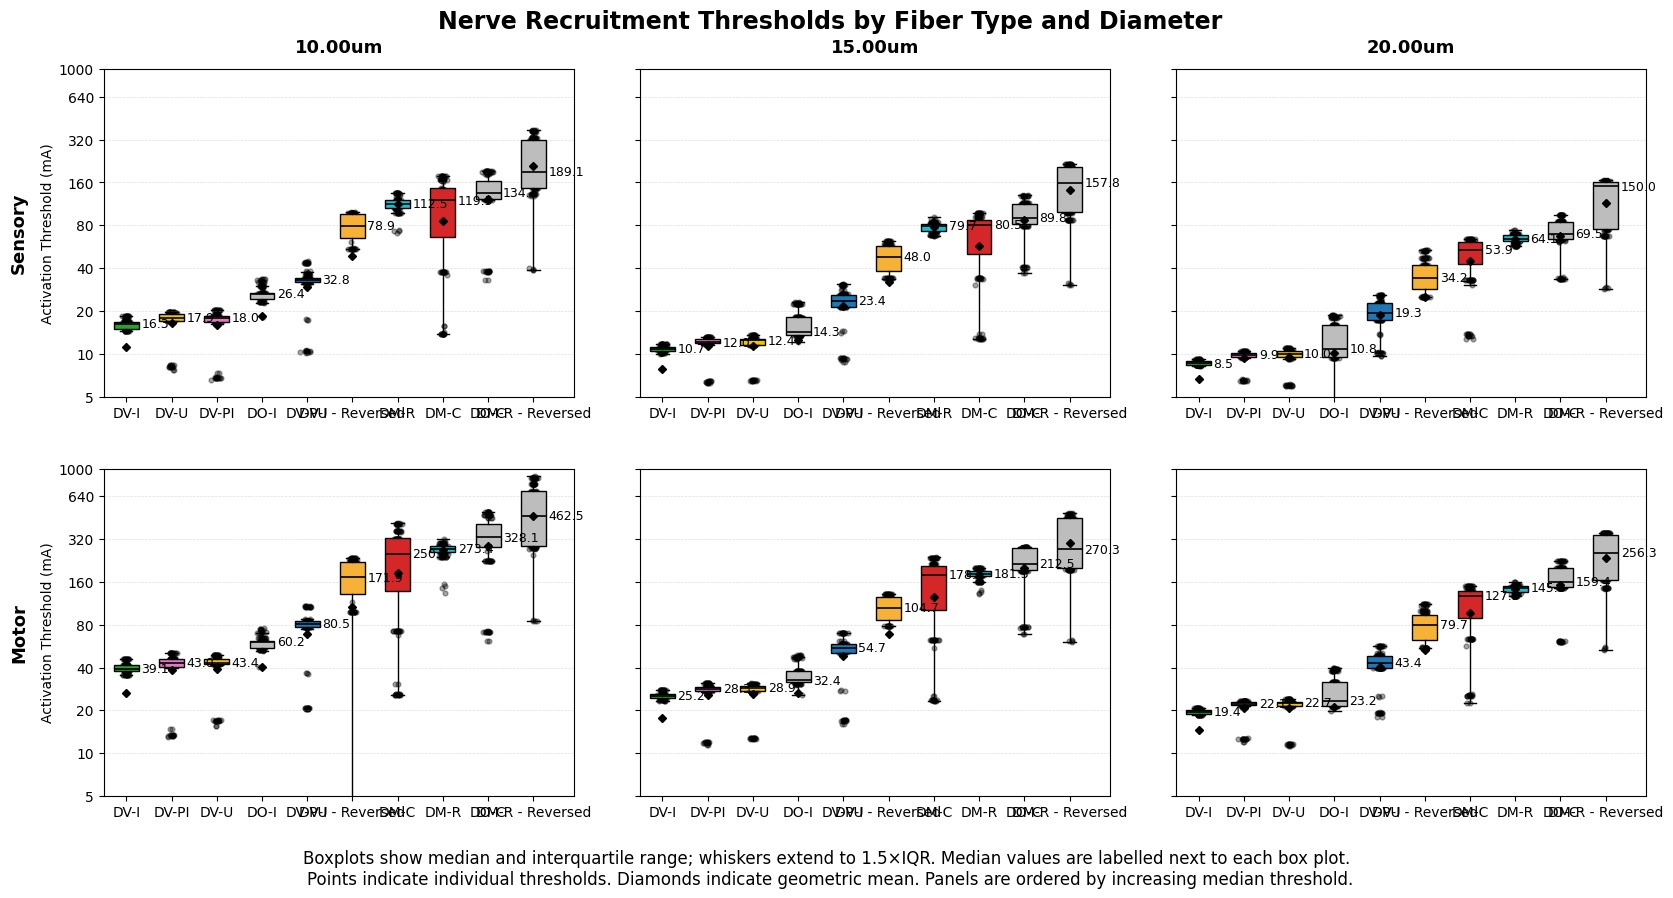

In [173]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# -----------------------------
# Configuration
# -----------------------------
fibre_types = ["Sensory MRG Neuron", "Motor MRG Neuron"]
fibre_diameters = ["10.00um", "15.00um", "20.00um"]
ymin, ymax = 5, 1000
yticks = [5, 10, 20, 40, 80, 160, 320, 640, 1000]

ordered_keys = list(electrode_combinations.keys())

plot_dfs = []
plot_labels = []

for key in ordered_keys:
    if key not in dfs:
        print(f"Skipping missing dataframe for: {key}")
        continue

    plot_dfs.append(dfs[key])
    plot_labels.append(key)   # label matches dict key


color_map = {
    "DV-U": "#F2C300",  # yellow
    "DV-I": "#2CA02C",  # green
    "DV-I - Reversed": "#f6b237", #Orange
    "DV-PU": "#1F77B4", # blue
    "DV-PI": "#E377C2", # pink
    "DM-C": "#D62728",  # red
    "DM-R": "#17BECF",  # teal
}
default_color = "#BDBDBD"

# IMPORTANT: keep original montage labels unchanged
base_labels = list(plot_labels)

# Reproducible jitter (keep constant seed so panels are comparable)
rng = np.random.default_rng(0)


# -----------------------------
# Helpers
# -----------------------------
def plain_number_formatter(y, _pos):
    if y <= 0:
        return ""
    if np.isclose(y, round(y), rtol=0, atol=1e-9):
        return f"{int(round(y))}"
    return f"{y:g}"


def safe_median(series):
    return np.median(series) if len(series) > 0 else np.inf  # empties pushed to end


def get_ordered_pairs(plot_dfs, labels, fibre_diameter, fibre_type):
    """Return (ordered_labels, ordered_data) sorted by increasing median for the given diameter/type."""
    pairs = []
    for lbl, df in zip(labels, plot_dfs):
        d = df[
            (df["Fibre_Diameter"] == fibre_diameter) &
            (df["NeuronType"] == fibre_type)
        ]["Activation_Threshold (mA)"].dropna()
        pairs.append((lbl, d))

    pairs_sorted = sorted(pairs, key=lambda t: safe_median(t[1]))
    ordered_labels = [lbl for lbl, _ in pairs_sorted]
    ordered_data   = [s   for _,   s in pairs_sorted]
    return ordered_labels, ordered_data


def plot_panel(ax, plot_dfs, labels, fibre_diameter, fibre_type, rng):
    """Plot one axis: boxplot + jitter + geometric mean + median labels, ordered by median."""
    ordered_labels, ordered_data = get_ordered_pairs(plot_dfs, labels, fibre_diameter, fibre_type)

    # Axis setup
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)

    # Boxplot
    bp = ax.boxplot(
        ordered_data,
        widths=0.55,
        patch_artist=True,
        showfliers=0,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
    )

    # Color boxes (must use ordered labels)
    for box, lbl in zip(bp["boxes"], ordered_labels):
        box.set_facecolor(color_map.get(lbl, default_color))

    # Extra horizontal padding for median labels
    n = len(ordered_labels)
    ax.set_xlim(0.5, n + 0.9)

    # Raw points + GM + median text
    for j, d in enumerate(ordered_data, start=1):
        if len(d) == 0:
            continue

        x = rng.normal(loc=j, scale=0.04, size=len(d))
        ax.scatter(x, d, s=12, alpha=0.35, color="black", zorder=0)

        dpos = d[d > 0]
        if len(dpos) > 0:
            gm = np.exp(np.mean(np.log(dpos)))
            ax.plot(j, gm, marker="D", color="black", markersize=4)

        med = float(np.median(d))
        ax.text(
            j + 0.33, med, f"{med:.1f}",
            va="center", ha="left",
            fontsize=9, color="black",
            clip_on=False
        )

    # X axis (labels must match ordered boxes)
    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels(ordered_labels, rotation=0)
    # ax.set_xlabel("Electrode Montage")

    # Y axis ticks/format
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FuncFormatter(plain_number_formatter))
    ax.yaxis.set_minor_locator(FixedLocator([]))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(which="major", axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

    return ordered_labels  # returned in case you ever need it downstream


# -----------------------------
# Figure (2 rows x 3 cols)
# -----------------------------
fig, axes = plt.subplots(
    nrows=len(fibre_types),
    ncols=len(fibre_diameters),
    figsize=(16.5, 9.2),
    sharey=True,
    constrained_layout=False
)

# Clear any existing suptitle
fig.suptitle("")

# Styled figure-level title (largest, highest priority)
fig.text(
    0.5, 0.985, "Nerve Recruitment Thresholds by Fiber Type and Diameter",
    ha="center",
    va="top",
    fontsize=17,        # larger than fibre_type and fibre_diameter
    fontweight="bold"
)


for r, fibre_type in enumerate(fibre_types):
    for c, fibre_diameter in enumerate(fibre_diameters):
        ax = axes[r, c]
        plot_panel(ax, plot_dfs, base_labels, fibre_diameter, fibre_type, rng)

        # Column headers: diameter on top row only
        if r == 0:
            # Clear default title
            ax.set_title("")

            # Styled fibre_diameter title (matches fibre_type styling)
            ax.text(
                0.5, 1.04, fibre_diameter,
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=13,        # match fibre_type size
                fontweight="bold"
            )

        # Row labels: fibre_type on leftmost plot of each row
        if c == 0:
            # Clear the default ylabel
            ax.set_ylabel("")

            # Large fibre_type label (acts like a row title)
            
            fibre_label = fibre_type.split(' ')[0]
            ax.text(
                -0.18, 0.5, fibre_label,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=13,        # larger
                fontweight="bold"
            )

            # Smaller measurement label
            ax.text(
                -0.12, 0.5, "Activation Threshold (mA)",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=10         # smaller
            )


# Spacing tuned to keep annotations visible and consistent
fig.subplots_adjust(
    left=0.06,
    right=0.995,
    bottom=0.13,
    top=0.92,
    wspace=0.14,
    hspace=0.22
)

fig.text(
    0.5, 0.03,
    "Boxplots show median and interquartile range; whiskers extend to 1.5×IQR. "
    "Median values are labelled next to each box plot. \n"
    "Points indicate individual thresholds. Diamonds indicate geometric mean. "
    "Panels are ordered by increasing median threshold.",
    ha="center",
    va="bottom",
    fontsize=12
)

plt.show()


In [134]:
fig.savefig(
    "Thatcher_motor_v_sensory_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

In [133]:
os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher")

In [44]:
document.AllAlgorithms[-1].Name = 'Voltage Multiplier - DM-C - Reversed'

##### Debugging Plotter

In [47]:

plot_dfs = []
plot_labels = []

for key in ordered_keys:
    if key not in dfs:
        print(f"Skipping missing dataframe for: {key}")
        continue

    plot_dfs.append(dfs[key])
    plot_labels.append(key)   # label matches dict key

In [48]:
plot_dfs

[     Unnamed: 0                                         NeuronName  \
 0            83  Nerve_root_L4_L5_sciatic_muscular_branches_of_...   
 1            71  Nerve_root_L4_L5_sciatic_muscular_branches_of_...   
 2             5  Nerve_root_L4_L5_muscular_branches_of_nerve_sc...   
 3            77  Nerve_root_L4_L5_sciatic_muscular_branches_of_...   
 4            59  Nerve_root_L4_L5_sciatic_muscular_branches_of_...   
 ..          ...                                                ...   
 709         102  Nerve_root_L4_L5_sciatic_muscular_branches_of_...   
 710          96  Nerve_root_L4_L5_sciatic_muscular_branches_of_...   
 711         162  Nerve_root_L4_L5_sciatic_nerve_tibial_right_05...   
 712         156  Nerve_root_L4_L5_sciatic_nerve_tibial_right_04...   
 713         138  Nerve_root_L4_L5_sciatic_nerve_tibial_right_01...   
 
              NeuronType Fibre_Diameter Location Electrode_Config  Frequency  \
 0    Sensory MRG Neuron        20.00um    L4_L5             DV-U 

### Vector Field Image Extraction

#### Create Voltage Multipliers of J for Each EMLF Config

In [13]:
# Takes a while to run!

for i in document.AllAlgorithms:
    
    if i.Name.startswith('Current Multiplier'):
        
        
    print(i.Name)
        # current_extractor = i
        # current_extractor.UpdateAttributes()
        # current_extractor.UpdateAll()
        # current_extractor.UpdateAttributes()

In [33]:
# Only run this once to avoid duplicates!

current_to_normalize_to = 0.1 # In Amps
# data_list = []

for i in document.AllAlgorithms:
    
    if i.Name == 'Current Extractor - DM-R2':
        continue
    
    if i.Name.startswith('Current Extractor'):  
        
        print(i.Name)
        current_extractor = i
        c = current_extractor.Outputs["Total Flux(J(x,y,z,f0))"]
        total_unnormalized_current = np.real(c.Data.GetComponent(0)[0])
        i_rms = total_unnormalized_current/np.sqrt(2)
        factor = current_to_normalize_to/i_rms
        
        prefix = "Current Extractor - "
        sim_name = current_extractor.Name.split(prefix, 1)[1]
        em_sensor_extractor = document.AllAlgorithms[f'Overall Field - {sim_name}']
        inputs = [em_sensor_extractor.Outputs["J(x,y,z,f0)"]]
        
        multiplier_name = f'Current Multiplier - {sim_name}'
        if multiplier_name in document.AllAlgorithms:
            continue

        multiplier = analysis.core.Multiplier(inputs=inputs)
        multiplier.Name = multiplier_name
        multiplier.UpdateAttributes()
        multiplier.Factor = factor
        multiplier.UpdateAttributes()
        document.AllAlgorithms.Add(multiplier)
         

#### Setup Vector Field Viewers for each scaled J Field

##### Test Vector Viewer Settings

In [15]:
i = document.AllAlgorithms['Current Multiplier - DV-PU']
        
inputs = [i.Outputs["J(x,y,z,f0)"]]
vector_field_viewer = analysis.viewers.VectorFieldViewer(inputs=inputs)
vector_field_viewer.Data.Phase = u"0°"
vector_field_viewer.Vector.Line.LineP0 = np.array([0.00013694167137145996, -0.0003299117088317871, 0.00018358230590820312])
vector_field_viewer.Vector.Line.LineP1 = np.array([0.2592717111110687, 0.48486998677253723, 1.7033298015594482])
vector_field_viewer.Vector.Plane.PlaneCenter = np.array([0.08, 0.24227003753185272, 0.8517566919326782])
vector_field_viewer.Vector.Plane.PlaneNormal = np.array([1.0, 0.0, 0.0])
vector_field_viewer.Vector.Plane.Resolution = 60
vector_field_viewer.Vector.ArrowSize = 14.703027226708153
vector_field_viewer.UpdateAttributes()
sim_name = "Current Multiplier - test output 2"
# viewer_name = f'Vector Field Viewer - {sim_name} - YZ Plane'

if sim_name not in document.AllAlgorithms:

    vector_field_viewer.Name = sim_name
    document.AllAlgorithms.Add(vector_field_viewer)



In [19]:
vector_field_viewer = document.AllAlgorithms["Current Multiplier - test output 2"]

box = [Vec3(0.136948, -0.32991, 0.183594), Vec3(259.272, 484.87, 1703.33)]

vector_field_viewer.Vector.Box.BoxP0 = np.array([0.0, -0.0, -1])
vector_field_viewer.Vector.Box.BoxP1 = np.array([0.2592717111110687, 0.48486998677253723, 4.0])
vector_field_viewer.Vector.Plane.Resolution = 40

vector_field_viewer.Vector.Plane.PlaneNormal = np.array([1.0, 0.0, 0.0])
vector_field_viewer.Vector.Box.BoxP1 = n.array([0.2592717111110687, 0.48486998677253723, 3.0])
vector_field_viewer.UpdateAttributes()

vector_field_viewer.Slice.Index = 200
vector_field_viewer.Update(1)

True

##### YZ Plane Settings

In [64]:
sim_name = 'DO-I'

In [65]:
vector_field_viewer = document.AllAlgorithms["Vector Field Viewer"]
vector_field_viewer.Name = f'Vector Field - {sim_name} - YZ Plane'
vector_field_viewer.Vector.Plane.PlaneNormal = np.array([1.0, 0.0, 0.0])
vector_field_viewer.Update(1)

True

In [66]:
vector_field_viewer.Vector.Plane.PlaneCenter = np.array([0.08, 0.24227003753185272, 0.8517566919326782])
vector_field_viewer.Vector.Plane.Resolution = 20
vector_field_viewer.Vector.ArrowSize = 25
vector_field_viewer.Update(1)

True

In [67]:
vector_field_viewer.DecibelScale = False
vector_field_viewer.ScalarRange = (0,3)
vector_field_viewer.Update(1)

True

##### XZ Plane Settings

In [145]:
vector_field_viewer = document.AllAlgorithms[-1]
# vector_field_viewer.Name = f'Vector Field - {sim_name} - XZ Plane'

In [142]:
vector_field_viewer = document.AllAlgorithms["Vector Field Viewer"]
vector_field_viewer.Name = f'Vector Field - {sim_name} - XZ Plane'
vector_field_viewer.Vector.Plane.PlaneNormal = np.array([0.0, 1.0, 0.0])
vector_field_viewer.Update(1)

AttributeError: 'NoneType' object has no attribute 'Name'

In [147]:
vector_field_viewer.Vector.Plane.PlaneCenter = np.array([0.08, 0.16, 0.8517566919326782])
vector_field_viewer.Vector.Plane.Resolution = 20
vector_field_viewer.Vector.ArrowSize = 25
vector_field_viewer.Update(1)

True

In [148]:
vector_field_viewer.DecibelScale = False
vector_field_viewer.ScalarRange = (0,3)
vector_field_viewer.Update(1)

True

##### XZ Plane Settings Spinal

In [39]:
vector_field_viewer = document.AllAlgorithms["Vector Field Viewer"]
vector_field_viewer.Name = f'Vector Field - {sim_name} - XZ Plane Spinal Level'
vector_field_viewer.Vector.Plane.PlaneNormal = np.array([0.0, 1.0, 0.0])
vector_field_viewer.Update(1)

True

In [13]:
# vector_field_viewer = document.AllAlgorithms['Vector Field - DV-I - XZ Plane - Spinal']

In [40]:
vector_field_viewer.Vector.Plane.PlaneCenter = np.array([0.08, 0.24, 0.8517566919326782])
vector_field_viewer.Vector.Plane.Resolution = 25
vector_field_viewer.Vector.ArrowSize = 20
# vector_field_viewer.ScaleArrows = 1
vector_field_viewer.Update(1)

True

In [9]:
# Decibel Scaling

vector_field_viewer.DecibelScale = True
vector_field_viewer.ScalarRange = (-50,0)
vector_field_viewer.DecibelReference = 30
vector_field_viewer.Update(1)

True

In [41]:
# Linear Scaling

vector_field_viewer.DecibelScale = False
vector_field_viewer.ScalarRange = (0,3)
vector_field_viewer.Update(1)

True

##### XY Plane Settings

In [75]:
vector_field_viewer = document.AllAlgorithms["Vector Field Viewer"]
# vector_field_viewer = document.AllAlgorithms['Vector Field - DV-PU - XY Plane']
vector_field_viewer.Name = f'Vector Field - {sim_name} - XY Plane'
vector_field_viewer.Vector.Plane.PlaneNormal = np.array([0.0, 0.0, 1.0])
vector_field_viewer.Update(1)

True

In [78]:
vector_field_viewer.Vector.Plane.PlaneCenter = np.array([0.08, 0.26, 1.128])
vector_field_viewer.Vector.ArrowSize = 11
vector_field_viewer.Vector.Plane.Resolution = 30
vector_field_viewer.Update(1)

True

In [79]:
vector_field_viewer.DecibelScale = False
vector_field_viewer.ScalarRange = (0,3)
vector_field_viewer.Update(1)

True

#### Adjust Views and Capture Images

In [44]:
from s4l_v1 import renderer
import os

def refresh_gui():
    if sys.platform == "win32":
        import win32gui
        win32gui.PumpWaitingMessages()

os.chdir(r'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2')
os.getcwd()

'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2'

In [139]:
sim_name = 'DV-I - Reversed'

##### YZ Angle Capture

In [82]:
eps = 1e-5
renderer.SetViewDirection(Vec3(-1, eps, 0))

view_name = f"Vector Field - {sim_name} - YZ Plane"

vector_field_viewer = document.AllAlgorithms[view_name]

renderer.ZoomToViewer(vector_field_viewer)
refresh_gui()

In [83]:
os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2")

In [84]:
size = 1024*2
renderer.SaveScreenCapture(width = size, height=size, output_folder = 'vector_viewer_images', output_prefix = view_name, transparent_background = False)

'Vector Field - DO-I - YZ Plane-001.png'

##### XZ Angle Capture

In [140]:
renderer.SetViewDirection(Vec3(0, 1, 0))

view_name = f'Vector Field - {sim_name} - XZ Plane'

vector_field_viewer = document.AllAlgorithms[view_name]

renderer.ZoomToViewer(vector_field_viewer)
refresh_gui()

AttributeError: 'NoneType' object has no attribute 'BoundingBox'

In [86]:
size = 1024*2
renderer.SaveScreenCapture(width = size, height=size, output_folder = 'vector_viewer_images', output_prefix = view_name, transparent_background = False)

'Vector Field - DO-I - XZ Plane-002.png'

##### XY Angle Capture 

In [89]:
renderer.SetViewDirection(Vec3(-0.001, 0.0001, -1))

view_name = f'Vector Field - {sim_name} - XY Plane'
renderer.ZoomToViewer(vector_field_viewer)

refresh_gui()

 Flip angle manually before continuing

In [90]:
clipper = document.AllAlgorithms['XY Clipper']

renderer.ZoomToViewer(clipper)

In [91]:
w = 1024*2
h = 1341
renderer.SaveScreenCapture(width = w, height=h, output_folder = 'vector_viewer_images', output_prefix = view_name, transparent_background = False)

'Vector Field - DO-I - XY Plane-001.png'

##### XZ Spinal Angle Capture

In [61]:
renderer.SetViewDirection(Vec3(0, 1, 0))

view_name = f'Vector Field - {sim_name} - XZ Plane Spinal Level'

vector_field_viewer = document.AllAlgorithms[view_name]

# renderer.ZoomToViewer(vector_field_viewer)
refresh_gui()

In [63]:
h = 1024*2
# h = 1341
renderer.SaveScreenCapture(width = h, height=h, output_folder = 'vector_viewer_images', output_prefix = view_name, transparent_background = False)

'Vector Field - DO-I - XZ Plane Spinal Level-001.png'

In [62]:
clipper = document.AllAlgorithms['XZ Clipper - Spinal']

renderer.ZoomToViewer(clipper)

##### Electrode Config Capture

In [81]:
view_name = 'DM-R - Reversed'
view_name = f'Vector Field - {view_name} - XZ Plane Spinal Level'
# viewer = document.AllAlgorithms[view_name]

In [93]:
view_name = "DO-"

h = 1024*2
# h = 1341
renderer.SaveScreenCapture(width = h, height=h, output_folder = 'electrode_configs', output_prefix = view_name, transparent_background = False)

'DO--002.png'

In [175]:
clipper = document.AllAlgorithms['XZ Clipper - Spinal']

renderer.ZoomToViewer(clipper)

In [52]:
dir(renderer)

['ImportRawApiError',
 'SaveScreenCapture',
 'SetViewDirection',
 'ShowScreenCapture',
 'ZoomTo',
 'ZoomToEntity',
 'ZoomToViewer',
 '_LOGGER',
 '_LOG_LEVEL',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_createDoc',
 '_renderer_impl',
 'logging']

In [140]:
# # csf = model.AllEntities()['Dura_mater']
# # renderer.ZoomToEntity(csf)


# p1 = np.array([0.08, 0.24, 0.8517566919326782])
# p2 = np.array([0.08, 1.2, 1.8517566919326782])

# p1 = Vec3(p1)
# p2 = Vec3(p2)


# renderer.ZoomTo(p1,p2,0.01)

# # p1

In [59]:
# for i in model.AllEntities():
#     print(i.Name)
    
# for i in document.AllAlgorithms:
#     print(i.Name)
    
clipper = document.AllAlgorithms['XY Clipper']

renderer.ZoomToViewer(clipper)

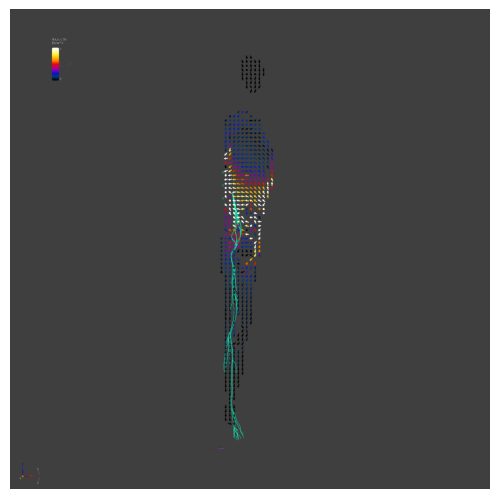

In [69]:
dir(renderer)
size = 1024*2
renderer.ShowScreenCapture(width = size, height=size)

In [52]:
dir(renderer)

['ImportRawApiError',
 'SaveScreenCapture',
 'SetViewDirection',
 'ShowScreenCapture',
 'ZoomTo',
 'ZoomToEntity',
 'ZoomToViewer',
 '_LOGGER',
 '_LOG_LEVEL',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_createDoc',
 '_renderer_impl',
 'logging']

## Export Electrode Config Images

In [95]:
os.getcwd()

'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2'

In [96]:
from pathlib import Path
from PIL import Image

def make_panels(electrode_configs_dir: str) -> None:
    """
    Build side-by-side composite diagrams for electrode config images.

    Rules:
      - DV-I: combine DV-002.png + I-001.png (side-by-side)
      - DV-P: combine DV-P-001.png only (already complete)
      - DM-C: combine DM-C-001.png only (already complete)
      - DM-R: combine DM-R-001.png only (already complete)
      - U:    combine U-002.png only (already complete)

    Output:
      - Writes composites into <electrode_configs_dir>/diagrams/
    """
    src = Path(electrode_configs_dir)
    if not src.exists():
        raise FileNotFoundError(f"Directory not found: {src}")

    out_dir = src / "diagrams"
    out_dir.mkdir(exist_ok=True)

    def open_img(p: Path) -> Image.Image:
        return Image.open(p).convert("RGBA")

    def hstack(images: list[Image.Image], pad: int = 0) -> Image.Image:
        # Align to max height, center vertically
        heights = [im.height for im in images]
        widths = [im.width for im in images]
        max_h = max(heights)
        total_w = sum(widths) + pad * (len(images) - 1)

        canvas = Image.new("RGBA", (total_w, max_h), (255, 255, 255, 0))
        x = 0
        for im in images:
            y = (max_h - im.height) // 2
            canvas.paste(im, (x, y), im)
            x += im.width + pad
        return canvas

    # Define what to build
    # key -> list of filenames to place side-by-side (in order)
    # panels = {
    #     "DV-I": ["DV-002.png", "I-001.png"],
    #     "DV-U": ["DV-002.png", "U-002.png"],
    #     "DV-PI": ["DV-P-001.png", "I-001.png"],
    #     "DV-PU": ["DV-P-001.png", "U-002.png"],
    #     "DM-C": ["DM-C-001.png"],   # already complete
    #     "DM-R": ["DM-R-001.png"],   # already complete
    # }
    
    panels = {
        "DO-I": ["DO--002.png", "I-001.png"],

    }

    for config, fnames in panels.items():
        paths = [src / f for f in fnames]
        missing = [p.name for p in paths if not p.exists()]
        if missing:
            print(f"[SKIP] {config}: missing {missing}")
            continue

        imgs = [open_img(p) for p in paths]

        # If only one image, just copy it out as the diagram
        if len(imgs) == 1:
            composite = imgs[0]
        else:
            composite = hstack(imgs, pad=0)

        out_path = out_dir / f"{config}.png"
        # Save as PNG; convert to RGB with white background if you prefer non-transparent
        composite.save(out_path, "PNG")
        print(f"[OK] Wrote {out_path}")

make_panels(r"electrode_configs")


In [83]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

# --- inputs ---
# Point this at the folder that contains the six images you just created (e.g., electrode_configs/diagrams)
in_dir = Path(r"electrode_configs\diagrams")
out_path = in_dir / "panel_3x2.png"

# Use the exact titles you showed in your screenshot (base name before .png)
# order = ["DM-C", "DM-R", "DV-I", "DV-PI", "DV-PU", "DV-U"]  # 3 wide x 2 high, row-major
order = ["DV-I",  "DV-U", "DV-PI", "DV-PU", "DM-C", "DM-R"]  # 3 wide x 2 high, row-major

# --- layout tuning ---
cols, rows = 3, 2
pad = 24                # spacing between tiles
outer_margin = 30       # margin around the whole panel
label_h = 42            # label band height (top of each tile)
bg = (255, 255, 255)    # white background
label_color = (0, 0, 0) # neutral text

# --- load images ---
paths = {name: (in_dir / f"{name}.png") for name in order}
missing = [name for name, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing images in {in_dir}: {missing}")

imgs = {name: Image.open(paths[name]).convert("RGBA") for name in order}

# --- choose a consistent tile image area size (fit all images) ---
# We’ll fit every image into the same (tile_w x tile_img_h) while preserving aspect ratio.
# Use the max width/height among inputs as the baseline, but you can clamp if you want smaller tiles.
max_w = max(im.width for im in imgs.values())
max_h = max(im.height for im in imgs.values())

tile_w = max_w
tile_img_h = max_h
tile_h = label_h + tile_img_h

panel_w = outer_margin * 2 + cols * tile_w + (cols - 1) * pad
panel_h = outer_margin * 2 + rows * tile_h + (rows - 1) * pad

panel = Image.new("RGB", (panel_w, panel_h), bg)
draw = ImageDraw.Draw(panel)

# --- font (neutral) ---
try:
    # If available, this is a clean, neutral sans font on many systems
    font = ImageFont.truetype("arial.ttf", 22)
except Exception:
    font = ImageFont.load_default()

def fit_contain(im: Image.Image, target_w: int, target_h: int) -> Image.Image:
    """Resize im to fit within (target_w, target_h) preserving aspect ratio."""
    w, h = im.size
    scale = min(target_w / w, target_h / h)
    new_size = (max(1, int(round(w * scale))), max(1, int(round(h * scale))))
    return im.resize(new_size, Image.Resampling.LANCZOS)

# --- render tiles ---
for idx, name in enumerate(order):
    r = idx // cols
    c = idx % cols

    x0 = outer_margin + c * (tile_w + pad)
    y0 = outer_margin + r * (tile_h + pad)

    # Label (centered at top of tile)
    label_text = name
    bbox = draw.textbbox((0, 0), label_text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]
    tx = x0 + (tile_w - text_w) // 2
    ty = y0 + (label_h - text_h) // 2
    draw.text((tx, ty), label_text, fill=label_color, font=font)

    # Image area
    im = imgs[name]
    fitted = fit_contain(im, tile_w, tile_img_h)

    # Paste centered under label
    ix = x0 + (tile_w - fitted.width) // 2
    iy = y0 + label_h + (tile_img_h - fitted.height) // 2

    # If image has alpha, composite onto white
    if fitted.mode == "RGBA":
        tmp = Image.new("RGBA", (tile_w, tile_img_h), (255, 255, 255, 255))
        tmp.paste(fitted, ((tile_w - fitted.width)//2, (tile_img_h - fitted.height)//2), fitted)
        fitted_rgb = tmp.convert("RGB")
        panel.paste(fitted_rgb, (x0, y0 + label_h))
    else:
        panel.paste(fitted, (ix, iy))

# --- save ---
panel.save(out_path, "PNG")
out_path


WindowsPath('electrode_configs/diagrams/panel_3x2.png')

## Additional Simulations

In [16]:
# Add code for creating DO-C and DO-I

### Defining Electrode Combinations

In [101]:
electrode_combinations = {

    "DO-I": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    
    "DO-C": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_caudal_midline"],
    },
    
}


In [19]:
electrode_combinations = {

    "DO-I (imported)": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    
    "DO-C (imported)": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_caudal_midline"],
    }
}


### Field Scaling and Normalization

In [40]:
inputs = []
simulation_extractor = analysis.extractors.SimulationExtractor(inputs=inputs)
sim_name = "DO-C"
simulation_extractor.Name = sim_name
simulation_extractor.FileName = u"C:\\Users\\kramerlab\\Documents\\sim4life9.0_projects\\Electrode_Montage_Variations_Thatcher_v6_S4Lupdate.smash_Results\\a9f729c5-8460-488d-a6ee-cfe4598e33ca_Output.h5"
simulation_extractor.UpdateAttributes()
document.AllAlgorithms.Add(simulation_extractor)

# Adding a new EmSensorExtractor
em_sensor_extractor = simulation_extractor["Overall Field"]
em_sensor_extractor.Name = f'Overall Field - {sim_name}'
em_sensor_extractor.FrequencySettings.ExtractedFrequency = u"All"
document.AllAlgorithms.Add(em_sensor_extractor)

In [41]:
inputs = [em_sensor_extractor.Outputs["EM Potential(x,y,z,f0)"], em_sensor_extractor.Outputs["J(x,y,z,f0)"]]
current_extractor = analysis.extractors.CurrentExtractor(inputs=inputs)

sim_name = 'DO-C'

current_extractor.Name = f"Current Extractor - {sim_name}"
current_extractor.UpdateAttributes()
document.AllAlgorithms.Add(current_extractor)
current_extractor.Update()


True

In [55]:
sim_name = 'DO-I'

current_extractor = document.AllAlgorithms[f"Current Extractor - {sim_name}"]
c = current_extractor.Outputs["Total Flux(J(x,y,z,f0))"]
total_unnormalized_current = np.real(c.Data.GetComponent(0)[0])
i_rms = total_unnormalized_current/np.sqrt(2)

i_rms

factor = current_to_normalize_to/i_rms

i_rms * factor

0.1

In [48]:
current_to_normalize_to = 0.1 # In Amps
i = 'Current Extractor - DO-C'
a = document.AllAlgorithms[i]
print(a.Name)
current_extractor = a
c = current_extractor.Outputs["Total Flux(J(x,y,z,f0))"]
total_unnormalized_current = np.real(c.Data.GetComponent(0)[0])
i_rms = total_unnormalized_current/np.sqrt(2)
factor = current_to_normalize_to/i_rms

prefix = "Current Extractor - "
sim_name = current_extractor.Name.split(prefix, 1)[1]
em_sensor_extractor = document.AllAlgorithms[f'Overall Field - {sim_name}']
inputs = [em_sensor_extractor.Outputs["EM Potential(x,y,z,f0)"]]
# inputs = [em_sensor_extractor.Outputs["EM E(x,y,z,f0)"]]
multiplier = analysis.core.Multiplier(inputs=inputs)
multiplier.Name = f'Voltage Multiplier - {sim_name}'
multiplier.UpdateAttributes()
multiplier.Factor = factor
multiplier.UpdateAttributes()
document.AllAlgorithms.Add(multiplier)


In [59]:
sim_name = 'DO-I'
i = f'Curent Multiplier - {sim_name}'
a = document.AllAlgorithms[i]
a.Name = f'Current Multiplier - {sim_name}'

### Data Extraction

In [113]:
# Redefine

electrode_combinations = {

    "DO-I": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    
    "DO-C": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_caudal_midline"],
    },
    
    "DV-I - Reversed": {
    "cathodes": ["Cathode_midline"],
    "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },    
}


In [109]:
# First, run the function that defines Neuron_Data_Extraction under the Titration Sensor Extraction heading

for i in electrode_combinations.keys():
    sim_name = f'NEURON - {i}'
    test_path = Neuron_Data_Extraction(sim_name)

    

####  Reading CSVs into DF's

In [2]:
# Redefine with all combinations

electrode_combinations = {
    
    "DV-U": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_umbilicus_right", "Anode_umbilicus_left"],
    },
    "DV-I": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    "DV-PU": {
        "cathodes": ["Cathode_paraspinal_left", "Cathode_paraspinal_right"],
        "anodes": ["Anode_umbilicus_right", "Anode_umbilicus_left"],
    },
    "DV-PI": {
        "cathodes": ["Cathode_paraspinal_left", "Cathode_paraspinal_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    "DM-C": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_caudal_midline"],
    },
    "DM-R": {
        "cathodes": ["Cathode_midline"],
        "anodes": ["Anode_rostral_midline"],
    },
    
    "DM-R - Reversed": {
        "cathodes": ["Anode_rostral_midline"],
        "anodes": ["Cathode_midline"],
    },    

    "DO-I": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },
    
    "DO-C": {
        "cathodes": ["Cathode_10cm_left", "Cathode_10cm_right"],
        "anodes": ["Anode_caudal_midline"],
    },
    
    "DV-I - Reversed": {
    "cathodes": ["Cathode_midline"],
    "anodes": ["Anode_iliac_right", "Anode_iliac_left"],
    },    
      
}


In [3]:
base_dir = Path(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher")

dfs = {}

for combo in electrode_combinations:  # iterates over keys
    folder = base_dir / combo
    if not folder.exists():
        print(f"Missing folder: {folder}")
        continue

    # Find CSVs in that folder (non-recursive). Change to rglob("*.csv") if needed.
    csvs = sorted(folder.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not csvs:
        print(f"No CSV found in: {folder}")
        continue

    # Pick the most recently modified CSV (usually what you want if filenames/dates vary)
    csv_path = csvs[0]

    dfs[combo] = pd.read_csv(csv_path)
    print(f"Loaded {combo}: {csv_path.name}  ->  shape={dfs[combo].shape}")

# Example: access a specific dataframe
df_dm_r = dfs.get("DM-R")


In [4]:
dfs.get("DV-I - Reversed")

,Unnamed: 0,NeuronName,NeuronType,Fibre_Diameter,Location,Electrode_Config,Frequency,Titration_Factor,Activation_Threshold (mA),First_Spike_Loc
0,28,Nerve_root_L4_L5_muscular_branches_of_nerve_sc...,Sensory MRG Neuron,15.00um,L4_L5,DV-I - Reversed,30,0.014648,1.464844,node[119]
1,10,Nerve_root_L4_L5_muscular_branches_of_nerve_sc...,Sensory MRG Neuron,15.00um,L4_L5,DV-I - Reversed,30,0.014893,1.489258,node[119]
2,4,Nerve_root_L4_L5_muscular_branches_of_nerve_sc...,Sensory MRG Neuron,15.00um,L4_L5,DV-I - Reversed,30,0.014893,1.489258,node[119]
3,64,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Sensory MRG Neuron,15.00um,L4_L5,DV-I - Reversed,30,0.015015,1.501465,node[119]
4,124,Nerve_root_L4_L5_sciatic_nerve_tibial_left_03 ...,Sensory MRG Neuron,15.00um,L4_L5,DV-I - Reversed,30,0.015015,1.501465,node[119]
...,...,...,...,...,...,...,...,...,...,...
709,312,Nerve_root_L5_sciatic_nerve_tibial_left_05 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,DV-I - Reversed,30,2.343750,234.375000,node[198]
710,180,Nerve_root_L5_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,L5_muscular,DV-I - Reversed,30,2.343750,234.375000,node[198]
711,252,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,DV-I - Reversed,30,2.343750,234.375000,node[198]
712,396,Nerve_root_S1_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,S1_muscular,DV-I - Reversed,30,2.343750,234.375000,node[247]


#### Testing AND Examining Proper Data Retrieval

In [12]:
plot_labels

['DV-U',
 'DV-I',
 'DV-PU',
 'DV-PI',
 'DM-C',
 'DM-R',
 'DM-R - φ',
 'DO-I',
 'DO-C',
 'DV-I - φ']

#### Plotting Recruitment Curves

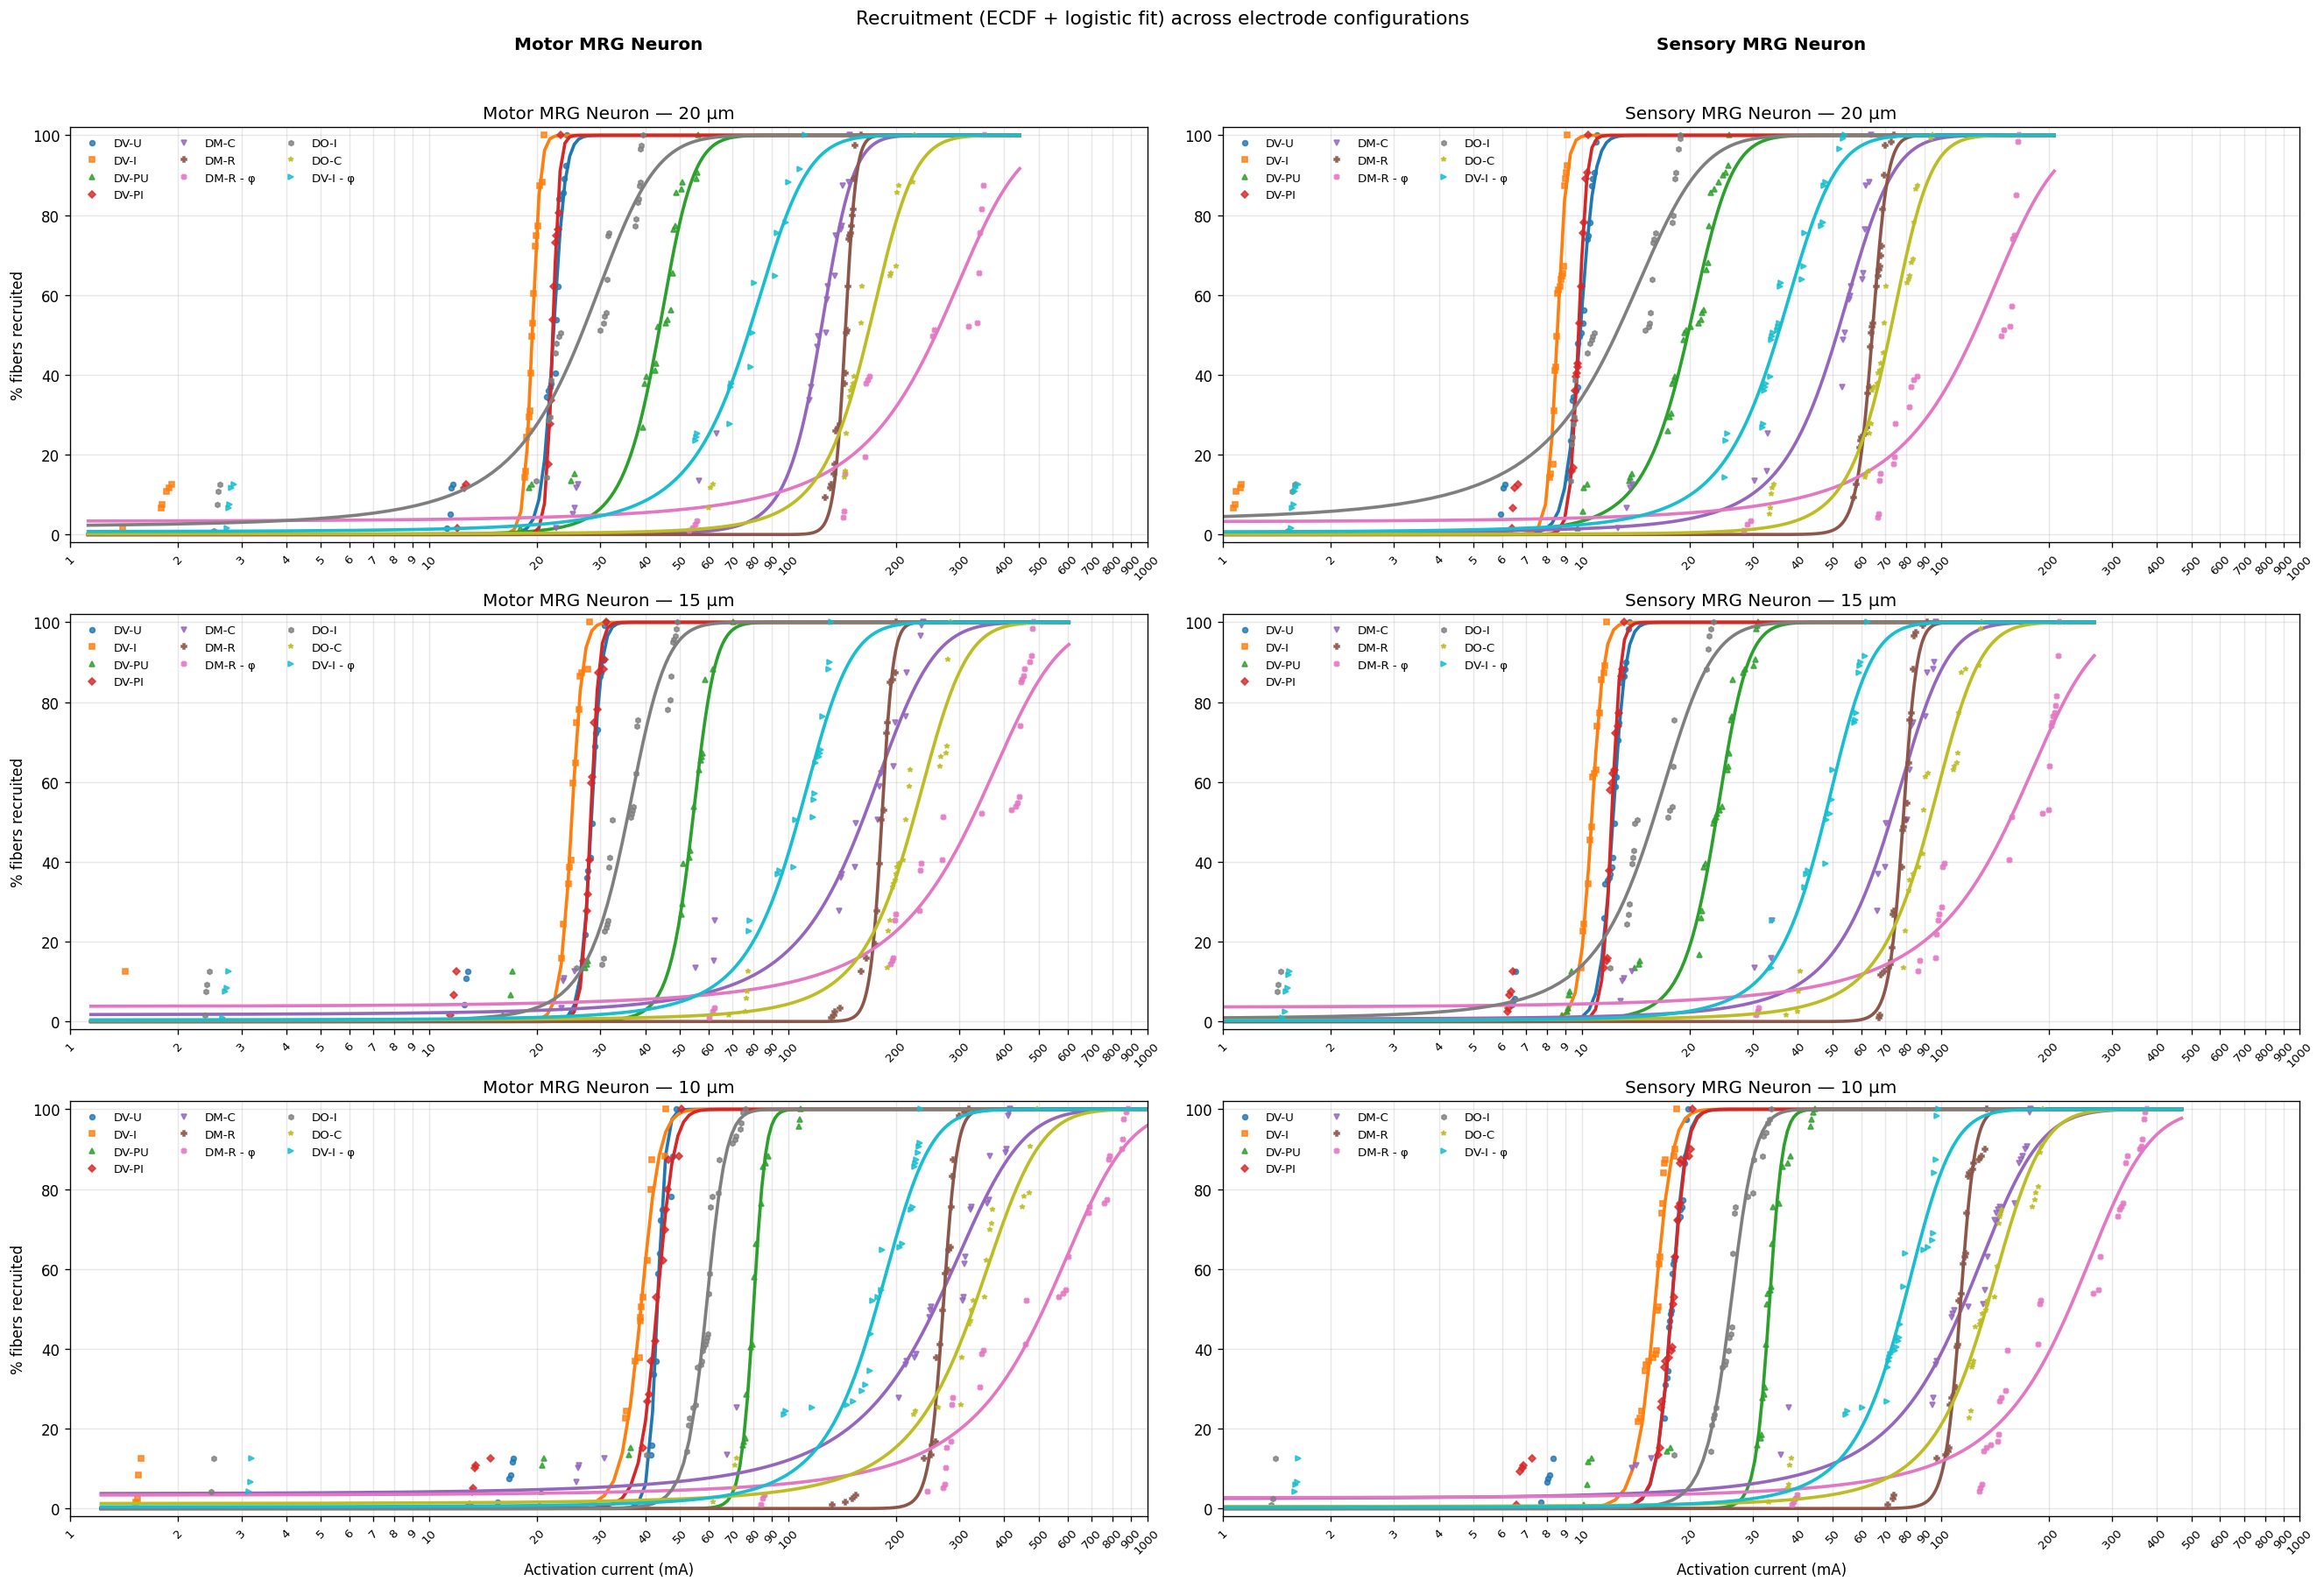

In [14]:
# dfs is assumed to be: { "DV-U": df, "DV-I": df, ... }

# Ensure a stable, explicit order (same as electrode_combinations)

def replace_reversed_with_phi(labels):
    """
    Replace all occurrences of the substring 'Reversed' with the Greek letter phi: 'φ'
    across a list/tuple of labels (or a single string).
    """
    if labels is None:
        return None
    if isinstance(labels, str):
        return labels.replace("Reversed", "φ")
    return [str(x).replace("Reversed", "φ") for x in labels]


ordered_keys = list(electrode_combinations.keys())

plot_dfs = []
plot_labels = []

for key in ordered_keys:
    if key not in dfs:
        print(f"Skipping missing dataframe for: {key}")
        continue

    plot_dfs.append(dfs[key])
    plot_labels.append(key)   # label matches dict key
    
# Replace "Reversed" -> "φ" in the labels BEFORE plotting
plot_labels = replace_reversed_with_phi(plot_labels)

fit_table, fig, axes_dict = plot_recruitment_by_group_multi(
    dfs=plot_dfs,
    labels=plot_labels,

    threshold_col="Activation_Threshold (mA)",
    group_cols=("NeuronType", "Fibre_Diameter"),

    title="Recruitment (ECDF + logistic fit) across electrode configurations",
    use_4pl=False,

    # show/hide
    show_points=True,
    show_fit=True,

    # layout: vertical (wide)
    ncols=1,
    figsize_per_subplot=(11, 5),

    # focus only the view; curves fitted on full range
    focus_pct=0.95,

    # legend inside each panel
    legend_loc="upper left",
    legend_ncol=3,
    legend_fontsize=8,
    legend_compact=False,
)

# plt.show()

In [19]:
import os
os.getcwd()
os.chdir(r"Z:\60_Cole_Slatt\Kramer-Lab---Modelling-Sham-tcSCS\Figures")

In [20]:
fig.savefig(r"Thatcher_recruitment_plot_w_added_configs.png",    
    dpi=300,
    bbox_inches="tight")

#### Plotting i50 Data Points

#### Plotting Boxplots/Violin Plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# -----------------------------
# Configuration
# -----------------------------
fibre_types = ["Sensory MRG Neuron", "Motor MRG Neuron"]
fibre_diameters = ["10.00um", "15.00um", "20.00um"]

ymin, ymax = 5, 1000
yticks = [5, 10, 20, 40, 80, 160, 320, 640, 1000]

ordered_keys = list(electrode_combinations.keys())

plot_dfs = []
plot_labels = []
for key in ordered_keys:
    if key not in dfs:
        print(f"Skipping missing dataframe for: {key}")
        continue
    plot_dfs.append(dfs[key])
    plot_labels.append(key)

# -----------------------------
# Colors (keys match DISPLAY labels, i.e., with φ)
# -----------------------------
color_map = {
    # DV family
    "DV-U": "#E6B800",
    "DV-I": "#2CA02C",
    "DV-I - φ": "#1B6E1B",
    "DV-PU": "#1F77B4",
    "DV-PI": "#7B6FD0",

    # DM family
    "DM-C": "#D62728",
    "DM-R": "#17BECF",
    "DM-R - φ": "#0E7C87",

    # DO family
    "DO-I": "#8C6D31",
    "DO-C": "#4D4D4D",
}
default_color = "#BDBDBD"

# IMPORTANT: keep original montage labels unchanged for data lookup/sorting
base_labels = list(plot_labels)

# Reproducible jitter
rng = np.random.default_rng(0)

# -----------------------------
# Helpers
# -----------------------------
def plain_number_formatter(y, _pos):
    if y <= 0:
        return ""
    if np.isclose(y, round(y), rtol=0, atol=1e-9):
        return f"{int(round(y))}"
    return f"{y:g}"

def safe_median(series):
    return np.median(series) if len(series) > 0 else np.inf

def get_ordered_pairs(plot_dfs, labels, fibre_diameter, fibre_type):
    pairs = []
    for lbl, df in zip(labels, plot_dfs):
        d = df[
            (df["Fibre_Diameter"] == fibre_diameter) &
            (df["NeuronType"] == fibre_type)
        ]["Activation_Threshold (mA)"].dropna()
        pairs.append((lbl, d))

    pairs_sorted = sorted(pairs, key=lambda t: safe_median(t[1]))
    ordered_labels = [lbl for lbl, _ in pairs_sorted]
    ordered_data   = [s   for _,   s in pairs_sorted]
    return ordered_labels, ordered_data

def plot_panel(ax, plot_dfs, labels, fibre_diameter, fibre_type, rng):
    """
    One axis: boxplot + jitter + geometric mean + median labels.
    Fixes:
      - Median labels are placed ABOVE the distribution (not on top of boxes).
      - Labels are kept INSIDE the axes region (no edge spillover).
      - Figure/axes spacing is handled at the figure level.
    """
    ordered_labels_raw, ordered_data = get_ordered_pairs(plot_dfs, labels, fibre_diameter, fibre_type)

    # Convert display labels: "Reversed" -> "φ"
    ordered_labels = [lbl.replace("Reversed", "φ") for lbl in ordered_labels_raw]

    # Axis setup
    ax.set_yscale("log")
    pad_decades = 0.08
    ax.set_ylim(ymin * (10**(-pad_decades)), ymax * (10**(pad_decades)))
    y_top = ax.get_ylim()[1]

    # Boxplot
    bp = ax.boxplot(
        ordered_data,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
        whis=1.5,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="black", linewidth=1),
        whiskerprops=dict(color="black", linewidth=1),
        capprops=dict(color="black", linewidth=1),
    )

    # Color boxes (use display labels)
    for box, lbl in zip(bp["boxes"], ordered_labels):
        box.set_facecolor(color_map.get(lbl, default_color))

    # X range: keep modest margins so labels/ticks fit, but don’t shove text outside
    n = len(ordered_labels)
    ax.set_xlim(0.5, n + 0.5)
    ax.margins(x=0.04)

    # Raw points + GM + MEDIAN LABELS (placed above, kept inside axes)
    for j, d in enumerate(ordered_data, start=1):
        if len(d) == 0:
            continue

        # jittered points
        x = rng.normal(loc=j, scale=0.04, size=len(d))
        ax.scatter(x, d, s=12, alpha=0.35, color="black", zorder=0)

        # geometric mean
        dpos = d[d > 0]
        if len(dpos) > 0:
            gm = np.exp(np.mean(np.log(dpos)))
            ax.plot(j, gm, marker="D", color="black", markersize=4, zorder=3)

        # median label (above distribution, not on the box)
        med = float(np.median(d))

        # Use a high percentile as a robust "top of data" anchor; push slightly upward in log-space
        y_anchor = float(np.percentile(d, 90))
        y_label = y_anchor * 1.10  # 10% upward in multiplicative (log-consistent) space

        # Keep label inside the axes top (avoid clipping / going outside)
        y_label = min(y_label, y_top / 1.08)

        # Centered above each group; no x-offset so edge labels stay inside
        ax.text(
            j, y_label, f"{med:.1f}",
            ha="center", va="bottom",
            fontsize=9, color="black",
            clip_on=True,
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85)
        )

    # X axis labels
    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels(ordered_labels, rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="x", pad=8)

    # Y axis ticks/format
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FuncFormatter(plain_number_formatter))
    ax.yaxis.set_minor_locator(FixedLocator([]))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(which="major", axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

    return ordered_labels

# -----------------------------
# Figure (2 rows x 3 cols)
# -----------------------------
# Make the whole figure bigger so each panel has more room (your request)
fig, axes = plt.subplots(
    nrows=len(fibre_types),
    ncols=len(fibre_diameters),
    figsize=(19.5, 11.0),   # bigger panels
    sharey=True,
    constrained_layout=False
)

# Title
fig.suptitle("")
fig.text(
    0.5, 0.985, "Nerve Recruitment Thresholds by Fiber Type and Diameter",
    ha="center", va="top",
    fontsize=17, fontweight="bold"
)

for r, fibre_type in enumerate(fibre_types):
    for c, fibre_diameter in enumerate(fibre_diameters):
        ax = axes[r, c]
        plot_panel(ax, plot_dfs, base_labels, fibre_diameter, fibre_type, rng)

        # Column headers: diameter on top row only
        if r == 0:
            ax.set_title("")
            ax.text(
                0.5, 1.04, fibre_diameter,
                transform=ax.transAxes,
                ha="center", va="bottom",
                fontsize=13, fontweight="bold"
            )

        # Row labels on leftmost plot
        if c == 0:
            ax.set_ylabel("")
            fibre_label = fibre_type.split(' ')[0]
            ax.text(
                -0.18, 0.5, fibre_label,
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center",
                fontsize=13, fontweight="bold"
            )
            ax.text(
                -0.12, 0.5, "Activation Threshold (mA)",
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center",
                fontsize=10
            )

# Spacing: more breathing room for rotated ticks + caption
fig.subplots_adjust(
    left=0.06,
    right=0.995,
    bottom=0.22,
    top=0.92,
    wspace=0.16,
    hspace=0.30
)

# Caption
fig.text(
    0.5, 0.04,
    "Boxplots show median and interquartile range; whiskers extend to 1.5×IQR. "
    "Median values are labelled above each box plot.\n"
    "Points indicate individual thresholds. Diamonds indicate geometric mean. "
    "Panels are ordered by increasing median threshold.",
    ha="center", va="bottom",
    fontsize=12
)

plt.show()


NameError: name 'electrode_combinations' is not defined

In [184]:
fig.savefig(
    "Thatcher_motor_v_sensory_boxplot_extra_configs.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:

DV-I - Reversed
 	Fibre_Diameter	NeuronType	n	min_mA	max_mA	median_mA	mean_mA
1	10.00um	Sensory MRG Neuron	119	1.587000	98.438000	78.906000	71.277000
0	10.00um	Motor MRG Neuron	119	3.149000	234.375000	171.875000	160.780000
3	15.00um	Sensory MRG Neuron	119	1.465000	62.500000	48.047000	44.037000
2	15.00um	Motor MRG Neuron	119	2.661000	132.031000	104.688000	97.527000
5	20.00um	Sensory MRG Neuron	119	1.550000	53.906000	34.180000	33.585000
4	20.00um	Motor MRG Neuron	119	2.734000	111.719000	79.688000	73.450000


## Validation

In [187]:
test_df = dfs.get("DV-I - Reversed")

d = (
    test_df
    .loc[
        (test_df["NeuronType"] == "Motor MRG Neuron") &
        (test_df["Fibre_Diameter"] == "10.00um"),
        "Activation_Threshold (mA)"
    ]
    .dropna()
)

q1, q3 = np.percentile(d, [25, 75]); print(q1 - 1.5*(q3-q1), d.min())
print(f'q1:{q1} q3:{q3}')

In [168]:
import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# Helpers to robustly find columns
# -----------------------------
def pick_col(frame: pd.DataFrame, *candidates: str) -> str:
    for c in candidates:
        if c in frame.columns:
            return c
    raise KeyError(
        f"None of these columns found: {candidates}\n"
        f"Available columns: {list(frame.columns)}"
    )

def make_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    # Column detection (handles common variants)
    col_diam = pick_col(df,
        "Fibre_Diameter", "Fibre_Dia", "Fibre_Diam", "FibreDiameter", "fiber_diameter"
    )
    col_type = pick_col(df,
        "NeuronType", "Neuron_Type", "neuron_type", "Type"
    )
    col_thr = pick_col(df,
        "Activation_Threshold (mA)", "Activation_Threshold_mA", "ActivationThreshold", "threshold_mA"
    )

    # Compute summary stats per (diameter, type)
    g = (
        df[[col_diam, col_type, col_thr]]
        .dropna(subset=[col_diam, col_type, col_thr])
        .groupby([col_diam, col_type], as_index=False)[col_thr]
        .agg(
            n="count",
            min_mA="min",
            max_mA="max",
            median_mA="median",
            mean_mA="mean",
        )
    )

    # Optional: sort to match your expected 6-row structure
    # (10, 15, 20) × (Sensory, Motor)
    # If your diameter values are strings like "10.00um", this still sorts correctly.
    def diam_sort_key(x):
        # try to pull numeric part for ordering
        try:
            return float(str(x).replace("um", ""))
        except Exception:
            return str(x)

    g["_diam_sort"] = g[col_diam].map(diam_sort_key)
    g["_type_sort"] = g[col_type].map(lambda s: 0 if "Sensory" in str(s) else 1)
    g = g.sort_values(by=["_diam_sort", "_type_sort"]).drop(columns=["_diam_sort", "_type_sort"])

    # Rename the group columns to stable names
    g = g.rename(columns={col_diam: "Fibre_Diameter", col_type: "NeuronType", col_thr: "Activation_Threshold (mA)"})

    # Round for readability (optional)
    for c in ["min_mA", "max_mA", "median_mA", "mean_mA"]:
        g[c] = g[c].astype(float).round(3)

    return g

# -----------------------------
# Build summaries for all dfs
# -----------------------------
summaries = {}  # label -> summary table

for label, df in dfs.items():
    try:
        summaries[label] = make_summary_table(df)
    except Exception as e:
        print(f"[SKIP] {label}: {e}")

# Example: view one summary table (pick the montage you care about)
# summaries["DV-I - Reversed"]
# or just print them all:
for label, tab in summaries.items():
    display(
        tab.style
           .set_caption(label)
           .set_table_styles([
               {"selector": "caption",
                "props": [("caption-side", "top"),
                          ("font-size", "14px"),
                          ("font-weight", "bold"),
                          ("text-align", "left")]}
           ])
    )

# -----------------------------
# Optional: export each summary to CSV
# -----------------------------
out_dir = Path("summaries_by_montage")
out_dir.mkdir(exist_ok=True)

for label, tab in summaries.items():
    safe = "".join(ch if ch.isalnum() or ch in " ._-()" else "_" for ch in label).strip()
    tab.to_csv(out_dir / f"{safe}__summary.csv", index=False)

print(f"\nWrote {len(summaries)} summary CSVs to: {out_dir.resolve()}")


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,7.715000,19.727000,17.871000,16.890000
0,10.00um,Motor MRG Neuron,119,15.527000,48.828000,43.359000,41.045000
3,15.00um,Sensory MRG Neuron,119,6.396000,13.574000,12.402000,11.664000
2,15.00um,Motor MRG Neuron,119,12.500000,31.055000,28.906000,26.814000
5,20.00um,Sensory MRG Neuron,119,5.957000,11.035000,9.961000,9.585000
4,20.00um,Motor MRG Neuron,119,11.230000,24.219000,22.656000,21.226000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,0.830000,18.359000,16.309000,14.354000
0,10.00um,Motor MRG Neuron,119,1.526000,45.703000,39.062000,35.247000
3,15.00um,Sensory MRG Neuron,119,0.848000,11.719000,10.742000,9.597000
2,15.00um,Motor MRG Neuron,119,1.428000,27.930000,25.195000,22.464000
5,20.00um,Sensory MRG Neuron,119,0.861000,9.131000,8.545000,7.702000
4,20.00um,Motor MRG Neuron,119,1.404000,20.898000,19.434000,17.400000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,10.156000,44.531000,32.812000,31.448000
0,10.00um,Motor MRG Neuron,119,20.312000,108.594000,80.469000,75.328000
3,15.00um,Sensory MRG Neuron,119,8.789000,31.055000,23.438000,22.742000
2,15.00um,Motor MRG Neuron,119,16.016000,70.312000,54.688000,51.256000
5,20.00um,Sensory MRG Neuron,119,9.717000,25.781000,19.336000,19.499000
4,20.00um,Motor MRG Neuron,119,17.969000,56.250000,43.359000,42.145000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,6.592000,20.312000,17.969000,16.739000
0,10.00um,Motor MRG Neuron,119,12.988000,50.391000,42.969000,40.554000
3,15.00um,Sensory MRG Neuron,119,6.201000,13.086000,12.012000,11.567000
2,15.00um,Motor MRG Neuron,119,11.426000,31.055000,28.320000,26.602000
5,20.00um,Sensory MRG Neuron,119,6.396000,10.449000,9.863000,9.488000
4,20.00um,Motor MRG Neuron,119,12.012000,23.242000,22.070000,21.127000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,13.770000,178.125000,119.531000,108.785000
0,10.00um,Motor MRG Neuron,119,25.781000,415.625000,250.000000,243.776000
3,15.00um,Sensory MRG Neuron,119,12.793000,96.875000,80.469000,67.053000
2,15.00um,Motor MRG Neuron,119,23.438000,237.500000,178.125000,151.050000
5,20.00um,Sensory MRG Neuron,119,12.598000,64.063000,53.906000,49.377000
4,20.00um,Motor MRG Neuron,119,22.656000,148.438000,127.344000,109.695000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,71.094000,134.375000,112.500000,113.314000
0,10.00um,Motor MRG Neuron,119,132.812000,318.750000,273.438000,268.080000
3,15.00um,Sensory MRG Neuron,119,67.188000,91.406000,79.688000,78.483000
2,15.00um,Motor MRG Neuron,119,132.031000,200.000000,181.250000,181.729000
5,20.00um,Sensory MRG Neuron,119,57.031000,74.219000,64.063000,64.568000
4,20.00um,Motor MRG Neuron,119,126.562000,159.375000,145.312000,143.888000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,38.477000,375.000000,189.063000,231.288000
0,10.00um,Motor MRG Neuron,119,84.375000,887.500000,462.500000,522.006000
3,15.00um,Sensory MRG Neuron,119,30.664000,214.063000,157.813000,155.122000
2,15.00um,Motor MRG Neuron,119,60.547000,484.375000,270.312000,329.566000
5,20.00um,Sensory MRG Neuron,119,28.320000,165.625000,150.000000,124.158000
4,20.00um,Motor MRG Neuron,119,53.125000,353.125000,256.250000,257.599000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,1.367000,33.789000,26.367000,23.759000
0,10.00um,Motor MRG Neuron,119,2.466000,76.172000,60.156000,53.427000
3,15.00um,Sensory MRG Neuron,119,1.416000,23.242000,14.258000,15.350000
2,15.00um,Motor MRG Neuron,119,2.380000,49.219000,32.422000,33.296000
5,20.00um,Sensory MRG Neuron,119,1.514000,18.848000,10.840000,12.320000
4,20.00um,Motor MRG Neuron,119,2.515000,39.453000,23.242000,25.874000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,33.203000,192.188000,134.375000,134.167000
0,10.00um,Motor MRG Neuron,119,61.719000,493.750000,328.125000,324.219000
3,15.00um,Sensory MRG Neuron,119,37.109000,129.688000,89.844000,91.964000
2,15.00um,Motor MRG Neuron,119,68.359000,282.812000,212.500000,215.215000
5,20.00um,Sensory MRG Neuron,119,33.398000,94.531000,69.531000,70.240000
4,20.00um,Motor MRG Neuron,119,60.156000,225.000000,159.375000,162.395000


,Fibre_Diameter,NeuronType,n,min_mA,max_mA,median_mA,mean_mA
1,10.00um,Sensory MRG Neuron,119,1.587000,98.438000,78.906000,71.277000
0,10.00um,Motor MRG Neuron,119,3.149000,234.375000,171.875000,160.780000
3,15.00um,Sensory MRG Neuron,119,1.465000,62.500000,48.047000,44.037000
2,15.00um,Motor MRG Neuron,119,2.661000,132.031000,104.688000,97.527000
5,20.00um,Sensory MRG Neuron,119,1.550000,53.906000,34.180000,33.585000
4,20.00um,Motor MRG Neuron,119,2.734000,111.719000,79.688000,73.450000


In [196]:
import pandas as pd
import numpy as np

# path_rev  = r"/mnt/data/Titration - DV-I - Reversed 2026_01_26 .csv"
# path_base = r"/mnt/data/Titration - DV-I 2025_12_17 .csv"

# df_rev  = pd.read_csv(path_rev)
# df_base = pd.read_csv(path_base)

df_norm = dfs.get("DV-I")
df_rev = dfs.get("DV-I - Reversed")

thr_col = "Activation_Threshold (mA)"
key_cols = ["NeuronName", "NeuronType", "Fibre_Diameter", "Location", "Frequency"]

# 1) Merge per-fiber
merged = df_norm.merge(
    df_rev,
    on=key_cols,
    suffixes=("_base", "_rev"),
    how="inner",
    validate="one_to_one"
)

# 2) Differences
merged["diff_mA"] = merged[f"{thr_col}_rev"] - merged[f"{thr_col}_base"]
merged["absdiff_mA"] = merged["diff_mA"].abs()
eps = 1e-12
merged["ratio_rev_over_base"] = merged[f"{thr_col}_rev"] / (merged[f"{thr_col}_base"] + eps)

# 3) Define "low" and "similar low"
low_cut_mA = 10.0
merged["low_base"] = merged[f"{thr_col}_base"] < low_cut_mA
merged["low_rev"]  = merged[f"{thr_col}_rev"]  < low_cut_mA

merged["similar_low"] = (merged["low_base"] & merged["low_rev"]) & (
    (merged["absdiff_mA"] <= 1.0) | (merged["ratio_rev_over_base"].between(1/1.2, 1.2))
)

# 4) Group summary: how polarity affects low-threshold tails
group_summary = (
    merged.groupby(["Fibre_Diameter", "NeuronType"], as_index=False)
    .agg(
        n=("NeuronName", "count"),
        n_low_base=("low_base", "sum"),
        n_low_rev=("low_rev", "sum"),
        n_similar_low=("similar_low", "sum"),
        median_base=(f"{thr_col}_base", "median"),
        median_rev=(f"{thr_col}_rev", "median"),
        median_absdiff=("absdiff_mA", "median"),
        max_absdiff=("absdiff_mA", "max"),
        min_ratio=("ratio_rev_over_base", "min"),
        max_ratio=("ratio_rev_over_base", "max"),
    )
)

# 5) Tables you asked for
top_absdiff = merged.sort_values("absdiff_mA", ascending=False).head(25)[
    ["NeuronName","NeuronType","Fibre_Diameter","Location","Frequency",
     f"{thr_col}_base", f"{thr_col}_rev", "diff_mA","absdiff_mA","ratio_rev_over_base",
     "First_Spike_Loc_base","First_Spike_Loc_rev"]
]

top_decrease = merged.sort_values("diff_mA", ascending=True).head(25)[
    ["NeuronName","NeuronType","Fibre_Diameter","Location","Frequency",
     f"{thr_col}_base", f"{thr_col}_rev", "diff_mA","ratio_rev_over_base",
     "First_Spike_Loc_base","First_Spike_Loc_rev"]
]

top_increase = merged.sort_values("diff_mA", ascending=False).head(25)[
    ["NeuronName","NeuronType","Fibre_Diameter","Location","Frequency",
     f"{thr_col}_base", f"{thr_col}_rev", "diff_mA","ratio_rev_over_base",
     "First_Spike_Loc_base","First_Spike_Loc_rev"]
]

similar_low_tbl = merged.loc[merged["similar_low"]].sort_values(
    ["NeuronType","Fibre_Diameter", f"{thr_col}_base"]
)[
    ["NeuronName","NeuronType","Fibre_Diameter","Location","Frequency",
     f"{thr_col}_base", f"{thr_col}_rev", "diff_mA","ratio_rev_over_base",
     "First_Spike_Loc_base","First_Spike_Loc_rev"]
]

print("Total fibers:", len(merged))
print("Low in base (<10 mA):", int(merged["low_base"].sum()))
print("Low in reversed (<10 mA):", int(merged["low_rev"].sum()))
print("Similar low in both:", int(merged["similar_low"].sum()))

display(group_summary)
display(similar_low_tbl)
display(top_absdiff)
display(top_decrease)
display(top_increase)


,Fibre_Diameter,NeuronType,n,n_low_base,n_low_rev,n_similar_low,median_base,median_rev,median_absdiff,max_absdiff,min_ratio,max_ratio
0,10.00um,Motor MRG Neuron,119,15,15,0,39.062500,171.875000,136.718750,194.921875,2.000000,6.125000
1,10.00um,Sensory MRG Neuron,119,15,15,15,16.308594,78.906250,62.695313,82.617188,1.805556,6.493506
2,15.00um,Motor MRG Neuron,119,15,15,0,25.195312,104.687500,80.078125,106.835938,1.863248,5.312000
3,15.00um,Sensory MRG Neuron,119,16,15,15,10.742188,48.046875,37.500000,52.441406,1.714286,6.213592
4,20.00um,Motor MRG Neuron,119,15,15,13,19.433594,79.687500,60.253906,93.066406,1.464968,5.989529
5,20.00um,Sensory MRG Neuron,119,119,15,15,8.544922,34.179688,25.634766,45.703125,1.394595,6.571429


,NeuronName,NeuronType,Fibre_Diameter,Location,Frequency,Activation_Threshold (mA)_base,Activation_Threshold (mA)_rev,diff_mA,ratio_rev_over_base,First_Spike_Loc_base,First_Spike_Loc_rev
77,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Motor MRG Neuron,20.00um,L4_L5,30,1.794434,2.758789,0.964355,1.537415,node[103],node[101]
78,Nerve_root_L4_L5_sciatic_nerve_tibial_left_01 ...,Motor MRG Neuron,20.00um,L4_L5,30,1.794434,2.758789,0.964355,1.537415,node[103],node[101]
79,Nerve_root_L4_L5_sciatic_nerve_tibial_left_02 ...,Motor MRG Neuron,20.00um,L4_L5,30,1.794434,2.758789,0.964355,1.537415,node[103],node[101]
80,Nerve_root_L4_L5_sciatic_nerve_tibial_left_03 ...,Motor MRG Neuron,20.00um,L4_L5,30,1.794434,2.758789,0.964355,1.537415,node[103],node[101]
81,Nerve_root_L4_L5_sciatic_nerve_tibial_left_04 ...,Motor MRG Neuron,20.00um,L4_L5,30,1.794434,2.758789,0.964355,1.537415,node[103],node[101]
82,Nerve_root_L4_L5_sciatic_nerve_tibial_left_05 ...,Motor MRG Neuron,20.00um,L4_L5,30,1.794434,2.758789,0.964355,1.537415,node[103],node[101]
83,Nerve_root_L4_L5_muscular_branches_of_nerve_sc...,Motor MRG Neuron,20.00um,L4_L5,30,1.806641,2.783203,0.976562,1.540541,node[103],node[100]
84,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Motor MRG Neuron,20.00um,L4_L5,30,1.855469,2.807617,0.952148,1.513158,node[103],node[100]
85,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Motor MRG Neuron,20.00um,L4_L5,30,1.855469,2.807617,0.952148,1.513158,node[103],node[100]
86,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Motor MRG Neuron,20.00um,L4_L5,30,1.855469,2.807617,0.952148,1.513158,node[103],node[100]


,NeuronName,NeuronType,Fibre_Diameter,Location,Frequency,Activation_Threshold (mA)_base,Activation_Threshold (mA)_rev,diff_mA,absdiff_mA,ratio_rev_over_base,First_Spike_Loc_base,First_Spike_Loc_rev
656,Nerve_root_S1_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,S1_muscular,30,39.453125,234.3750,194.921875,194.921875,5.940594,node[0],node[247]
657,Nerve_root_S1_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,S1_muscular,30,39.453125,232.8125,193.359375,193.359375,5.900990,node[0],node[247]
670,Nerve_root_L5_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,L5_muscular,30,41.406250,234.3750,192.968750,192.968750,5.660377,node[0],node[198]
698,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]
690,Nerve_root_L5_sciatic_nerve_tibial_left_05 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]
691,Nerve_root_L5_sciatic_nerve_tibial_left_04 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]
692,Nerve_root_L5_sciatic_nerve_tibial_left_03 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]
694,Nerve_root_L5_sciatic_nerve_tibial_left_01 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]
695,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]
696,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,192.578125,5.607477,node[0],node[198]


,NeuronName,NeuronType,Fibre_Diameter,Location,Frequency,Activation_Threshold (mA)_base,Activation_Threshold (mA)_rev,diff_mA,ratio_rev_over_base,First_Spike_Loc_base,First_Spike_Loc_rev
44,Nerve_root_L4_L5_muscular_branches_of_nerve_sc...,Sensory MRG Neuron,20.00um,L4_L5,30,1.129150,1.574707,0.445557,1.394595,node[102],node[100]
37,Nerve_root_L4_L5_sciatic_nerve_tibial_left_05 ...,Sensory MRG Neuron,20.00um,L4_L5,30,1.068115,1.562500,0.494385,1.462857,node[102],node[100]
36,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Sensory MRG Neuron,20.00um,L4_L5,30,1.068115,1.562500,0.494385,1.462857,node[102],node[100]
35,Nerve_root_L4_L5_sciatic_nerve_tibial_left_04 ...,Sensory MRG Neuron,20.00um,L4_L5,30,1.068115,1.562500,0.494385,1.462857,node[102],node[100]
34,Nerve_root_L4_L5_sciatic_nerve_tibial_left_03 ...,Sensory MRG Neuron,20.00um,L4_L5,30,1.068115,1.562500,0.494385,1.462857,node[102],node[100]
33,Nerve_root_L4_L5_sciatic_nerve_tibial_left_02 ...,Sensory MRG Neuron,20.00um,L4_L5,30,1.068115,1.562500,0.494385,1.462857,node[102],node[100]
32,Nerve_root_L4_L5_sciatic_nerve_tibial_left_01 ...,Sensory MRG Neuron,20.00um,L4_L5,30,1.068115,1.562500,0.494385,1.462857,node[102],node[100]
43,Nerve_root_L4_L5_muscular_branches_of_nerve_sc...,Sensory MRG Neuron,20.00um,L4_L5,30,1.123047,1.623535,0.500488,1.445652,node[103],node[100]
41,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Sensory MRG Neuron,20.00um,L4_L5,30,1.086426,1.586914,0.500488,1.460674,node[102],node[99]
40,Nerve_root_L4_L5_sciatic_muscular_branches_of_...,Sensory MRG Neuron,20.00um,L4_L5,30,1.086426,1.586914,0.500488,1.460674,node[102],node[99]


,NeuronName,NeuronType,Fibre_Diameter,Location,Frequency,Activation_Threshold (mA)_base,Activation_Threshold (mA)_rev,diff_mA,ratio_rev_over_base,First_Spike_Loc_base,First_Spike_Loc_rev
656,Nerve_root_S1_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,S1_muscular,30,39.453125,234.3750,194.921875,5.940594,node[0],node[247]
657,Nerve_root_S1_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,S1_muscular,30,39.453125,232.8125,193.359375,5.900990,node[0],node[247]
670,Nerve_root_L5_muscular_branches_of_nerve_sciat...,Motor MRG Neuron,10.00um,L5_muscular,30,41.406250,234.3750,192.968750,5.660377,node[0],node[198]
698,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]
690,Nerve_root_L5_sciatic_nerve_tibial_left_05 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]
691,Nerve_root_L5_sciatic_nerve_tibial_left_04 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]
692,Nerve_root_L5_sciatic_nerve_tibial_left_03 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]
694,Nerve_root_L5_sciatic_nerve_tibial_left_01 [Mo...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]
695,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]
696,Nerve_root_L5_sciatic_muscular_branches_of_ner...,Motor MRG Neuron,10.00um,L5_sciatic,30,41.796875,234.3750,192.578125,5.607477,node[0],node[198]


### Quantifying Charge inside the Cord

#### Creating Mask Filters for Each Simulation

In [10]:

x = []

x.append(model.AllEntities()['Dura_mater'])
x.append(model.AllEntities()['Spinal_cord_white_matter'])
x.append(model.AllEntities()['Spinal_cord_grey_matter'])
x.append(model.AllEntities()['Cerebrospinal_fluid'])

for sim_name in electrode_combinations.keys():
    
    print(f'Creating Filter for {sim_name}')
    
    filter_name = f'{sim_name} Mask Filter Spinal'
    
    exists = any(getattr(alg, "Name", None) == filter_name
        for alg in document.AllAlgorithms)
    
    if exists:
        continue
   
    multiplier = document.AllAlgorithms[f'Current Multiplier - {sim_name}']
    inputs = [multiplier.Outputs["J(x,y,z,f0)"]]
    field_masking_filter = analysis.core.FieldMaskingFilter(inputs=inputs)
    field_masking_filter.UpdateAttributes()
    field_masking_filter.Name = filter_name
    field_masking_filter.SetAllMaterials(False)
    field_masking_filter.SetEntities(x)
    field_masking_filter.UpdateAttributes()
    document.AllAlgorithms.Add(field_masking_filter)

In [86]:
x = []

x.append(model.AllEntities()['Dura_mater'])
x.append(model.AllEntities()['Spinal_cord_white_matter'])
x.append(model.AllEntities()['Spinal_cord_grey_matter'])
x.append(model.AllEntities()['Cerebrospinal_fluid'])

for sim_name in electrode_combinations.keys():
    filter_name = f'{sim_name} Mask Filter Spinal'
    mask_filter = document.AllAlgorithms[filter_name]
    mask_filter.SetAllMaterials(False)
    mask_filter.SetEntities(x)
    mask_filter.UpdateAttributes()
    
    



In [8]:
count = 0
for i in document.AllAlgorithms:
    if i.Name == 'Current Multiplier - DV-I':
        print(f'{count}:{i.Name}')
    count += 1
    

#### Adding a new StatisticsEvaluator

In [11]:
# Adding a new StatisticsEvaluator

for sim_name in electrode_combinations.keys():
    
    filter_name = f'{sim_name} Mask Filter Spinal'
    print(filter_name)
    field_masking_filter = document.AllAlgorithms[filter_name]
    inputs = [field_masking_filter.Outputs["J(x,y,z,f0)"]]
    statistics_evaluator = analysis.core.StatisticsEvaluator(inputs=inputs)
    statistics_evaluator.Mode = u"RMS Magnitude"
    statistics_evaluator.Component = u"Vector"
    statistics_evaluator.UpdateAttributes()
    statistics_evaluator.Name = f'Statistics - {sim_name}'
    document.AllAlgorithms.Add(statistics_evaluator)


In [19]:
dir(statistics_evaluator)
outputs = statistics_evaluator.Outputs['J Statistics']
for i in outputs.Data:
    print(i)

RuntimeError: DEPRECATED: use now <obj>.DataSimpleDataCollection.* functionality

#### Adding a new Table Viewer

In [14]:
for sim_name in electrode_combinations.keys():

    stats_name = f'Statistics - {sim_name}'
    table_name = f'J Stats Table Viewer - {sim_name}'
    
    exists = any(getattr(alg, "Name", None) == table_name
        for alg in document.AllAlgorithms)
    
    if exists:
        continue
    
    statistics_evaluator = document.AllAlgorithms[stats_name]
    inputs = [statistics_evaluator.Outputs["J Statistics"]]
    data_table_html_viewer = analysis.viewers.DataTableHTMLViewer(inputs=inputs)
    data_table_html_viewer.UpdateAttributes()
    data_table_html_viewer.Name = table_name
    document.AllAlgorithms.Add(data_table_html_viewer)
     

In [9]:
sim_name = 'DV-PU'

stats_name = f'Statistics - {sim_name}'
statistics_evaluator = document.AllAlgorithms[stats_name]
inputs = [statistics_evaluator.Outputs["J Statistics"]]
data_table_html_viewer = analysis.viewers.DataTableHTMLViewer(inputs=inputs)
data_table_html_viewer.UpdateAttributes()
data_table_html_viewer.Name = f'J Stats Table Viewer - {sim_name}'
document.AllAlgorithms.Add(data_table_html_viewer)

In [13]:
dir(data_table_html_viewer)
data_table_html_viewer.Update(1)

True

#### Pulling Current Data

In [25]:
data=[]

for sim_name in electrode_combinations.keys():

    stats_name = f'Statistics - {sim_name}'
    print(stats_name)
    statistics_evaluator = document.AllAlgorithms[stats_name]
    statistics_evaluator.UseDb = False
    statistics_evaluator.UpdateAttributes()
    outputs = statistics_evaluator.Outputs['J Statistics']
    D = outputs.Data.DataSimpleDataCollection
    try:
        int_val = D.FieldValue('Integral',0)
    except:
        continue
    
    cord_data = {"Name" : sim_name,
                "Min" : D.FieldValue('Min',0),
                "Max" : D.FieldValue('Max',0),
                "Average" : D.FieldValue('Average',0),
                "Integral" : D.FieldValue('Integral',0)}
    data.append(cord_data)

    # print(f'Total RMS current for {sim_name} = {int_val}')
    

In [26]:
import os
os.chdir(r'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2')
os.getcwd()
df = pd.DataFrame(data)
df.to_csv("current_in_the_cord.csv")

In [11]:
import os
os.chdir(r'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2')
os.getcwd()

df.to_csv("current_in_the_cord.csv")

In [27]:
df

,Name,Min,Max,Average,Integral
0,DV-U,4.711751e-08,72.106461,1.270558,0.000465
1,DV-I,1.563122e-04,50.274746,1.706980,0.000624
2,DV-PU,1.225494e-06,54.455048,0.833825,0.000305
3,DV-PI,7.790966e-05,32.498669,1.598241,0.000584
4,DM-C,1.406994e-04,34.190052,1.253212,0.000458
5,DM-R,7.619695e-04,59.869392,1.132460,0.000413
6,DM-R - Reversed,7.619715e-04,59.869545,1.132463,0.000413
7,DO-I,4.931537e-06,44.012127,0.893100,0.000326
8,DO-C,8.995213e-05,7.512451,0.156558,0.000057
9,DV-I - Reversed,1.563127e-04,50.274910,1.706985,0.000624


In [20]:
sim_name = 'DV-PU'

stats_name = f'Statistics - {sim_name}'
statistics_evaluator = document.AllAlgorithms[stats_name]
outputs = statistics_evaluator.Outputs['J Statistics']
D = outputs.Data.DataSimpleDataCollection
D.Keys()

['Min',
 'MinLocation',
 'MinCenter',
 'Max',
 'MaxLocation',
 'MaxCenter',
 'Average',
 'Integral']

In [80]:
sim_name = 'DO-I'
stats_name = f'Statistics - {sim_name}'
statistics_evaluator = document.AllAlgorithms[stats_name]
statistics_evaluator.Update(1)
outputs = statistics_evaluator.Outputs['J Statistics']
# D = outputs.Data.DataSimpleDataCollection
# min_val = D.FieldValue('Integral',0)

# print(f'Total RMS current for {sim_name} = {min_val}')

In [81]:
D = outputs.Data.DataSimpleDataCollection
min_val = D.FieldValue('Integral',0)

print(f'Total RMS current for {sim_name} = {min_val}')

In [85]:
statistics_evaluator.UseDb = False

False

In [82]:
dir(statistics_evaluator)

['Clone',
 'Component',
 'ComponentProp',
 'DbFactor',
 'DbFactorProp',
 'DbRef',
 'DbRefProp',
 'Description',
 'DisplayDescription',
 'Errors',
 'InfoMessages',
 'Inputs',
 'Mode',
 'ModeProp',
 'Name',
 'Outputs',
 'Phase',
 'PhaseProp',
 'ReadOnly',
 'ToolTip',
 'Update',
 'UpdateAll',
 'UpdateAttributes',
 'UseDb',
 'UseDbProp',
 'Visible',
 'Warnings',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_childbinders',
 '_deprecated',
 '_getprop',
 '_instances',
 '_obj',
 '_raw_classes',
 '_update_after_init',
 '_use_defaults_from',
 'raw']

In [12]:
document.AllAlgorithms[152].Name = 'Current Multiplier - DV-I - Reversed'

In [50]:
for i in electrode_combinations.keys():
    print(i)

In [10]:
count =0
for i in document.AllAlgorithms:
    print(count)
    print(i)
    count +=1

In [25]:
multiplier.SetAllMaterials(False)

In [ ]:
count = 0

while count<10:
    
    if count == 5:
        continue
    
    print(count)
    count +=1

In [48]:
x = []

x.append(model.AllEntities()['Dura_mater'])
x.append(model.AllEntities()['Spinal_cord_white_matter'])
x.append(model.AllEntities()['Spinal_cord_grey_matter'])
x.append(model.AllEntities()['Cerebrospinal_fluid'])

multiplier.SetEntities(x)

In [4]:
multiplier.SetMaterial

['Clone',
 'Description',
 'DisplayDescription',
 'Errors',
 'InfoMessages',
 'Inputs',
 'IsMaterialOn',
 'MaterialIds',
 'MaterialNames',
 'Name',
 'Outputs',
 'ReadOnly',
 'ReplacementValue',
 'ReplacementValueProp',
 'Reset',
 'SetAllMatchingMaterials',
 'SetAllMaterials',
 'SetEntities',
 'SetMaterial',
 'ToolTip',
 'Update',
 'UpdateAll',
 'UpdateAttributes',
 'UseNaN',
 'UseNaNProp',
 'Visible',
 'VoxeledMaterials',
 'Warnings',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_childbinders',
 '_deprecated',
 '_getprop',
 '_instances',
 '_obj',
 '_raw_classes',
 '_use_defaults_from',
 'raw']

In [ ]:
import os, psutil

p = psutil.Process(os.getpid())
print("CPU % (instant):", p.cpu_percent(interval=0.5))
print("RSS RAM (GB):", p.memory_info().rss / 1e9)
print("Threads:", p.num_threads())


In [ ]:
import os, psutil
p = psutil.Process(os.getpid())
print("RSS RAM (GB):", p.memory_info().rss / 1e9)


In [ ]:
import os, psutil, time
p = psutil.Process(os.getpid())

print("PID:", p.pid)
print("Process name:", p.name())
print("Executable:", p.exe())
print("Cmdline (first 5):", p.cmdline()[:5])
print("Create time:", time.ctime(p.create_time()))
print("Threads:", p.num_threads())
print("RSS (GB):", p.memory_info().rss / 1e9)


In [195]:


# Adding a new FieldMaskingFilter
inputs = [multiplier.Outputs["J(x,y,z,f0)"]]
field_masking_filter = analysis.core.FieldMaskingFilter(inputs=inputs)
field_masking_filter.UpdateAttributes()
materials = field_masking_filter.MaterialIds()
field_masking_filter.SetMaterial(materials[0], False)
field_masking_filter.SetMaterial(materials[1], False)
field_masking_filter.SetMaterial(materials[2], False)
field_masking_filter.SetMaterial(materials[3], False)
field_masking_filter.SetMaterial(materials[4], False)
field_masking_filter.SetMaterial(materials[5], False)
field_masking_filter.SetMaterial(materials[6], False)
field_masking_filter.SetMaterial(materials[7], False)
field_masking_filter.SetMaterial(materials[8], False)
field_masking_filter.SetMaterial(materials[9], False)
field_masking_filter.SetMaterial(materials[10], False)
field_masking_filter.SetMaterial(materials[11], False)
field_masking_filter.SetMaterial(materials[12], False)
field_masking_filter.SetMaterial(materials[13], False)
field_masking_filter.SetMaterial(materials[14], False)
field_masking_filter.SetMaterial(materials[15], False)
field_masking_filter.SetMaterial(materials[16], False)
field_masking_filter.SetMaterial(materials[17], False)
field_masking_filter.SetMaterial(materials[18], False)
field_masking_filter.SetMaterial(materials[19], False)
field_masking_filter.SetMaterial(materials[20], False)
field_masking_filter.SetMaterial(materials[21], False)
field_masking_filter.SetMaterial(materials[22], False)
field_masking_filter.SetMaterial(materials[23], False)
field_masking_filter.SetMaterial(materials[24], False)
field_masking_filter.SetMaterial(materials[25], False)
field_masking_filter.SetMaterial(materials[26], False)
field_masking_filter.SetMaterial(materials[27], False)
field_masking_filter.SetMaterial(materials[28], False)
field_masking_filter.SetMaterial(materials[29], False)
field_masking_filter.SetMaterial(materials[30], False)
field_masking_filter.SetMaterial(materials[31], False)
field_masking_filter.SetMaterial(materials[32], False)
field_masking_filter.SetMaterial(materials[33], False)
field_masking_filter.SetMaterial(materials[34], False)
field_masking_filter.SetMaterial(materials[35], False)
field_masking_filter.SetMaterial(materials[36], False)
field_masking_filter.SetMaterial(materials[37], False)
field_masking_filter.SetMaterial(materials[38], False)
field_masking_filter.SetMaterial(materials[39], False)
field_masking_filter.SetMaterial(materials[40], False)
field_masking_filter.SetMaterial(materials[41], False)
field_masking_filter.SetMaterial(materials[42], False)
field_masking_filter.SetMaterial(materials[43], False)
field_masking_filter.SetMaterial(materials[44], False)
field_masking_filter.SetMaterial(materials[45], False)
field_masking_filter.SetMaterial(materials[46], False)
field_masking_filter.SetMaterial(materials[47], False)
field_masking_filter.SetMaterial(materials[48], False)
field_masking_filter.SetMaterial(materials[49], False)
field_masking_filter.SetMaterial(materials[50], False)
field_masking_filter.SetMaterial(materials[51], False)
field_masking_filter.SetMaterial(materials[52], False)
field_masking_filter.SetMaterial(materials[53], False)
field_masking_filter.SetMaterial(materials[54], False)
field_masking_filter.SetMaterial(materials[55], False)
field_masking_filter.SetMaterial(materials[56], False)
field_masking_filter.SetMaterial(materials[57], False)
field_masking_filter.SetMaterial(materials[58], False)
field_masking_filter.SetMaterial(materials[59], False)
field_masking_filter.SetMaterial(materials[60], False)
field_masking_filter.SetMaterial(materials[61], False)
field_masking_filter.SetMaterial(materials[62], False)
field_masking_filter.SetMaterial(materials[63], False)
field_masking_filter.SetMaterial(materials[64], False)
field_masking_filter.SetMaterial(materials[65], False)
field_masking_filter.SetMaterial(materials[66], False)
field_masking_filter.SetMaterial(materials[67], False)
field_masking_filter.SetMaterial(materials[68], False)
field_masking_filter.SetMaterial(materials[69], False)
field_masking_filter.SetMaterial(materials[70], False)
field_masking_filter.SetMaterial(materials[71], False)
field_masking_filter.SetMaterial(materials[72], False)
field_masking_filter.SetMaterial(materials[73], False)
field_masking_filter.SetMaterial(materials[74], False)
field_masking_filter.SetMaterial(materials[75], False)
field_masking_filter.SetMaterial(materials[76], False)
field_masking_filter.SetMaterial(materials[77], False)
field_masking_filter.SetMaterial(materials[78], False)
field_masking_filter.SetMaterial(materials[79], False)
field_masking_filter.SetMaterial(materials[80], False)
field_masking_filter.SetMaterial(materials[81], False)
field_masking_filter.SetMaterial(materials[82], False)
field_masking_filter.SetMaterial(materials[83], False)
field_masking_filter.SetMaterial(materials[84], False)
field_masking_filter.SetMaterial(materials[85], False)
field_masking_filter.SetMaterial(materials[86], False)
field_masking_filter.SetMaterial(materials[87], False)
field_masking_filter.SetMaterial(materials[88], False)
field_masking_filter.SetMaterial(materials[89], False)
field_masking_filter.SetMaterial(materials[90], False)
field_masking_filter.SetMaterial(materials[91], False)
field_masking_filter.SetMaterial(materials[92], False)
field_masking_filter.SetMaterial(materials[93], False)
field_masking_filter.SetMaterial(materials[94], False)
field_masking_filter.SetMaterial(materials[95], False)
field_masking_filter.SetMaterial(materials[96], False)
field_masking_filter.SetMaterial(materials[97], False)
field_masking_filter.SetMaterial(materials[98], False)
field_masking_filter.SetMaterial(materials[99], False)
field_masking_filter.SetMaterial(materials[100], False)
field_masking_filter.SetMaterial(materials[101], False)
field_masking_filter.SetMaterial(materials[102], False)
field_masking_filter.SetMaterial(materials[103], False)
field_masking_filter.SetMaterial(materials[104], False)
field_masking_filter.SetMaterial(materials[105], False)
field_masking_filter.SetMaterial(materials[106], False)
field_masking_filter.SetMaterial(materials[107], False)
field_masking_filter.SetMaterial(materials[108], False)
field_masking_filter.SetMaterial(materials[109], False)
field_masking_filter.SetMaterial(materials[110], False)
field_masking_filter.SetMaterial(materials[111], False)
field_masking_filter.SetMaterial(materials[112], False)
field_masking_filter.SetMaterial(materials[113], False)
field_masking_filter.SetMaterial(materials[114], False)
field_masking_filter.SetMaterial(materials[115], False)
field_masking_filter.SetMaterial(materials[116], False)
field_masking_filter.SetMaterial(materials[117], False)
field_masking_filter.SetMaterial(materials[118], False)
field_masking_filter.SetMaterial(materials[119], False)
field_masking_filter.SetMaterial(materials[120], False)
field_masking_filter.SetMaterial(materials[121], False)
field_masking_filter.SetMaterial(materials[122], False)
field_masking_filter.SetMaterial(materials[123], False)
field_masking_filter.SetMaterial(materials[124], False)
field_masking_filter.SetMaterial(materials[125], False)
field_masking_filter.SetMaterial(materials[126], False)
field_masking_filter.SetMaterial(materials[127], False)
field_masking_filter.SetMaterial(materials[128], False)
field_masking_filter.SetMaterial(materials[129], False)
field_masking_filter.SetMaterial(materials[130], False)
field_masking_filter.SetMaterial(materials[131], False)
field_masking_filter.SetMaterial(materials[132], False)
field_masking_filter.SetMaterial(materials[133], False)
field_masking_filter.SetMaterial(materials[134], False)
field_masking_filter.SetMaterial(materials[135], False)
field_masking_filter.SetMaterial(materials[136], False)
field_masking_filter.SetMaterial(materials[137], False)
field_masking_filter.SetMaterial(materials[138], False)
field_masking_filter.SetMaterial(materials[139], False)
field_masking_filter.SetMaterial(materials[140], False)
field_masking_filter.SetMaterial(materials[141], False)
field_masking_filter.SetMaterial(materials[142], False)
field_masking_filter.SetMaterial(materials[143], False)
field_masking_filter.SetMaterial(materials[144], False)
field_masking_filter.SetMaterial(materials[145], False)
field_masking_filter.SetMaterial(materials[146], False)
field_masking_filter.SetMaterial(materials[147], False)
field_masking_filter.SetMaterial(materials[148], False)
field_masking_filter.SetMaterial(materials[149], False)
field_masking_filter.SetMaterial(materials[150], False)
field_masking_filter.SetMaterial(materials[151], False)
field_masking_filter.SetMaterial(materials[152], False)
field_masking_filter.SetMaterial(materials[153], False)
field_masking_filter.SetMaterial(materials[154], False)
field_masking_filter.SetMaterial(materials[155], False)
field_masking_filter.SetMaterial(materials[156], False)
field_masking_filter.SetMaterial(materials[157], False)
field_masking_filter.SetMaterial(materials[158], False)
field_masking_filter.SetMaterial(materials[159], False)
field_masking_filter.SetMaterial(materials[160], False)
field_masking_filter.SetMaterial(materials[161], False)
field_masking_filter.SetMaterial(materials[162], False)
field_masking_filter.SetMaterial(materials[163], False)
field_masking_filter.SetMaterial(materials[164], False)
field_masking_filter.SetMaterial(materials[165], False)
field_masking_filter.SetMaterial(materials[166], False)
field_masking_filter.SetMaterial(materials[167], False)
field_masking_filter.SetMaterial(materials[168], False)
field_masking_filter.SetMaterial(materials[169], False)
field_masking_filter.SetMaterial(materials[170], False)
field_masking_filter.SetMaterial(materials[171], False)
field_masking_filter.SetMaterial(materials[172], False)
field_masking_filter.SetMaterial(materials[173], False)
field_masking_filter.SetMaterial(materials[174], False)
field_masking_filter.SetMaterial(materials[175], False)
field_masking_filter.SetMaterial(materials[176], False)
field_masking_filter.SetMaterial(materials[177], False)
field_masking_filter.SetMaterial(materials[178], False)
field_masking_filter.SetMaterial(materials[179], False)
field_masking_filter.SetMaterial(materials[180], False)
field_masking_filter.SetMaterial(materials[181], False)
field_masking_filter.SetMaterial(materials[182], False)
field_masking_filter.SetMaterial(materials[183], False)
field_masking_filter.SetMaterial(materials[184], False)
field_masking_filter.SetMaterial(materials[185], False)
field_masking_filter.SetMaterial(materials[186], False)
field_masking_filter.SetMaterial(materials[187], False)
field_masking_filter.SetMaterial(materials[188], False)
field_masking_filter.SetMaterial(materials[189], False)
field_masking_filter.SetMaterial(materials[190], False)
field_masking_filter.SetMaterial(materials[191], False)
field_masking_filter.SetMaterial(materials[192], False)
field_masking_filter.SetMaterial(materials[193], False)
field_masking_filter.SetMaterial(materials[194], False)
field_masking_filter.SetMaterial(materials[195], False)
field_masking_filter.SetMaterial(materials[196], False)
field_masking_filter.SetMaterial(materials[197], False)
field_masking_filter.SetMaterial(materials[198], False)
field_masking_filter.SetMaterial(materials[199], False)
field_masking_filter.SetMaterial(materials[200], False)
field_masking_filter.SetMaterial(materials[201], False)
field_masking_filter.SetMaterial(materials[202], False)
field_masking_filter.SetMaterial(materials[203], False)
field_masking_filter.SetMaterial(materials[204], False)
field_masking_filter.SetMaterial(materials[205], False)
field_masking_filter.SetMaterial(materials[206], False)
field_masking_filter.SetMaterial(materials[207], False)
field_masking_filter.SetMaterial(materials[208], False)
field_masking_filter.SetMaterial(materials[209], False)
field_masking_filter.SetMaterial(materials[210], False)
field_masking_filter.SetMaterial(materials[211], False)
field_masking_filter.SetMaterial(materials[212], False)
field_masking_filter.SetMaterial(materials[213], False)
field_masking_filter.SetMaterial(materials[214], False)
field_masking_filter.SetMaterial(materials[215], False)
field_masking_filter.SetMaterial(materials[216], False)
field_masking_filter.SetMaterial(materials[217], False)
field_masking_filter.SetMaterial(materials[218], False)
field_masking_filter.SetMaterial(materials[219], False)
field_masking_filter.SetMaterial(materials[220], False)
field_masking_filter.SetMaterial(materials[221], False)
field_masking_filter.SetMaterial(materials[222], False)
field_masking_filter.SetMaterial(materials[223], False)
field_masking_filter.SetMaterial(materials[224], False)
field_masking_filter.SetMaterial(materials[225], False)
field_masking_filter.SetMaterial(materials[226], False)
field_masking_filter.SetMaterial(materials[227], False)
field_masking_filter.SetMaterial(materials[228], False)
field_masking_filter.SetMaterial(materials[229], False)
field_masking_filter.SetMaterial(materials[230], False)
field_masking_filter.SetMaterial(materials[231], False)
field_masking_filter.SetMaterial(materials[232], False)
field_masking_filter.SetMaterial(materials[233], False)
field_masking_filter.SetMaterial(materials[234], False)
field_masking_filter.SetMaterial(materials[235], False)
field_masking_filter.SetMaterial(materials[236], False)
field_masking_filter.SetMaterial(materials[237], False)
field_masking_filter.SetMaterial(materials[238], False)
field_masking_filter.SetMaterial(materials[239], False)
field_masking_filter.SetMaterial(materials[240], False)
field_masking_filter.SetMaterial(materials[241], False)
field_masking_filter.SetMaterial(materials[242], False)
field_masking_filter.SetMaterial(materials[243], False)
field_masking_filter.SetMaterial(materials[244], False)
field_masking_filter.SetMaterial(materials[245], False)
field_masking_filter.SetMaterial(materials[246], False)
field_masking_filter.SetMaterial(materials[247], False)
field_masking_filter.SetMaterial(materials[248], False)
field_masking_filter.SetMaterial(materials[249], False)
field_masking_filter.SetMaterial(materials[250], False)
field_masking_filter.SetMaterial(materials[251], False)
field_masking_filter.SetMaterial(materials[252], False)
field_masking_filter.SetMaterial(materials[253], False)
field_masking_filter.SetMaterial(materials[254], False)
field_masking_filter.SetMaterial(materials[255], False)
field_masking_filter.SetMaterial(materials[256], False)
field_masking_filter.SetMaterial(materials[257], False)
field_masking_filter.SetMaterial(materials[258], False)
field_masking_filter.SetMaterial(materials[259], False)
field_masking_filter.SetMaterial(materials[260], False)
field_masking_filter.SetMaterial(materials[261], False)
field_masking_filter.SetMaterial(materials[262], False)
field_masking_filter.SetMaterial(materials[263], False)
field_masking_filter.SetMaterial(materials[264], False)
field_masking_filter.SetMaterial(materials[265], False)
field_masking_filter.SetMaterial(materials[266], False)
field_masking_filter.SetMaterial(materials[267], False)
field_masking_filter.SetMaterial(materials[268], False)
field_masking_filter.SetMaterial(materials[269], False)
field_masking_filter.SetMaterial(materials[270], False)
field_masking_filter.SetMaterial(materials[271], False)
field_masking_filter.SetMaterial(materials[272], False)
field_masking_filter.SetMaterial(materials[273], False)
field_masking_filter.SetMaterial(materials[274], False)
field_masking_filter.SetMaterial(materials[275], False)
field_masking_filter.SetMaterial(materials[276], False)
field_masking_filter.SetMaterial(materials[277], False)
field_masking_filter.SetMaterial(materials[278], False)
field_masking_filter.SetMaterial(materials[279], False)
field_masking_filter.SetMaterial(materials[280], False)
field_masking_filter.SetMaterial(materials[281], False)
field_masking_filter.SetMaterial(materials[282], False)
field_masking_filter.SetMaterial(materials[283], False)
field_masking_filter.SetMaterial(materials[284], False)
field_masking_filter.SetMaterial(materials[285], False)
field_masking_filter.SetMaterial(materials[286], False)
field_masking_filter.SetMaterial(materials[287], False)
field_masking_filter.SetMaterial(materials[288], False)
field_masking_filter.SetMaterial(materials[289], False)
field_masking_filter.SetMaterial(materials[290], False)
field_masking_filter.SetMaterial(materials[291], False)
field_masking_filter.SetMaterial(materials[292], False)
field_masking_filter.SetMaterial(materials[293], False)
field_masking_filter.SetMaterial(materials[294], False)
field_masking_filter.SetMaterial(materials[295], False)
field_masking_filter.SetMaterial(materials[296], False)
field_masking_filter.SetMaterial(materials[297], False)
field_masking_filter.SetMaterial(materials[298], False)
field_masking_filter.SetMaterial(materials[299], False)
field_masking_filter.SetMaterial(materials[300], False)
field_masking_filter.SetMaterial(materials[301], False)
field_masking_filter.SetMaterial(materials[302], False)
field_masking_filter.SetMaterial(materials[303], False)
field_masking_filter.SetMaterial(materials[304], False)
field_masking_filter.SetMaterial(materials[305], False)
field_masking_filter.SetMaterial(materials[306], False)
field_masking_filter.SetMaterial(materials[307], False)
field_masking_filter.SetMaterial(materials[308], False)
field_masking_filter.SetMaterial(materials[309], False)
field_masking_filter.SetMaterial(materials[310], False)
field_masking_filter.SetMaterial(materials[311], False)
field_masking_filter.SetMaterial(materials[312], False)
field_masking_filter.SetMaterial(materials[313], False)
field_masking_filter.SetMaterial(materials[314], False)
field_masking_filter.SetMaterial(materials[315], False)
field_masking_filter.SetMaterial(materials[316], False)
field_masking_filter.SetMaterial(materials[317], False)
field_masking_filter.SetMaterial(materials[318], False)
field_masking_filter.SetMaterial(materials[319], False)
field_masking_filter.SetMaterial(materials[320], False)
field_masking_filter.SetMaterial(materials[321], False)
field_masking_filter.SetMaterial(materials[322], False)
field_masking_filter.SetMaterial(materials[323], False)
field_masking_filter.SetMaterial(materials[324], False)
field_masking_filter.SetMaterial(materials[325], False)
field_masking_filter.SetMaterial(materials[326], False)
field_masking_filter.SetMaterial(materials[327], False)
field_masking_filter.SetMaterial(materials[328], False)
field_masking_filter.SetMaterial(materials[329], False)
field_masking_filter.SetMaterial(materials[330], False)
field_masking_filter.SetMaterial(materials[331], False)
field_masking_filter.SetMaterial(materials[332], False)
field_masking_filter.SetMaterial(materials[333], False)
field_masking_filter.SetMaterial(materials[334], False)
field_masking_filter.SetMaterial(materials[335], False)
field_masking_filter.SetMaterial(materials[336], False)
field_masking_filter.SetMaterial(materials[337], False)
field_masking_filter.SetMaterial(materials[338], False)
field_masking_filter.SetMaterial(materials[339], False)
field_masking_filter.SetMaterial(materials[340], False)
field_masking_filter.SetMaterial(materials[341], False)
field_masking_filter.SetMaterial(materials[342], False)
field_masking_filter.SetMaterial(materials[343], False)
field_masking_filter.SetMaterial(materials[344], False)
field_masking_filter.SetMaterial(materials[345], False)
field_masking_filter.SetMaterial(materials[346], False)
field_masking_filter.SetMaterial(materials[347], False)
field_masking_filter.SetMaterial(materials[348], False)
field_masking_filter.SetMaterial(materials[349], False)
field_masking_filter.SetMaterial(materials[350], False)
field_masking_filter.SetMaterial(materials[351], False)
field_masking_filter.SetMaterial(materials[352], False)
field_masking_filter.SetMaterial(materials[353], False)
field_masking_filter.SetMaterial(materials[354], False)
field_masking_filter.SetMaterial(materials[355], False)
field_masking_filter.SetMaterial(materials[356], False)
field_masking_filter.SetMaterial(materials[357], False)
field_masking_filter.SetMaterial(materials[358], False)
field_masking_filter.SetMaterial(materials[359], False)
field_masking_filter.SetMaterial(materials[360], False)
field_masking_filter.SetMaterial(materials[361], False)
field_masking_filter.SetMaterial(materials[362], False)
field_masking_filter.SetMaterial(materials[363], False)
field_masking_filter.SetMaterial(materials[364], False)
field_masking_filter.SetMaterial(materials[365], False)
field_masking_filter.SetMaterial(materials[366], False)
field_masking_filter.SetMaterial(materials[367], False)
field_masking_filter.SetMaterial(materials[368], False)
field_masking_filter.SetMaterial(materials[369], False)
field_masking_filter.SetMaterial(materials[370], False)
field_masking_filter.SetMaterial(materials[371], False)
field_masking_filter.SetMaterial(materials[372], False)
field_masking_filter.SetMaterial(materials[373], False)
field_masking_filter.SetMaterial(materials[374], False)
field_masking_filter.SetMaterial(materials[375], False)
field_masking_filter.SetMaterial(materials[376], False)
field_masking_filter.SetMaterial(materials[377], False)
field_masking_filter.SetMaterial(materials[378], False)
field_masking_filter.SetMaterial(materials[379], False)
field_masking_filter.SetMaterial(materials[380], False)
field_masking_filter.SetMaterial(materials[381], False)
field_masking_filter.SetMaterial(materials[382], False)
field_masking_filter.SetMaterial(materials[383], False)
field_masking_filter.SetMaterial(materials[384], False)
field_masking_filter.SetMaterial(materials[385], False)
field_masking_filter.SetMaterial(materials[386], False)
field_masking_filter.SetMaterial(materials[387], False)
field_masking_filter.SetMaterial(materials[388], False)
field_masking_filter.SetMaterial(materials[389], False)
field_masking_filter.SetMaterial(materials[390], False)
field_masking_filter.SetMaterial(materials[391], False)
field_masking_filter.SetMaterial(materials[392], False)
field_masking_filter.SetMaterial(materials[393], False)
field_masking_filter.SetMaterial(materials[394], False)
field_masking_filter.SetMaterial(materials[395], False)
field_masking_filter.SetMaterial(materials[396], False)
field_masking_filter.SetMaterial(materials[397], False)
field_masking_filter.SetMaterial(materials[398], False)
field_masking_filter.SetMaterial(materials[399], False)
field_masking_filter.SetMaterial(materials[400], False)
field_masking_filter.SetMaterial(materials[401], False)
field_masking_filter.SetMaterial(materials[402], False)
field_masking_filter.SetMaterial(materials[403], False)
field_masking_filter.SetMaterial(materials[404], False)
field_masking_filter.SetMaterial(materials[405], False)
field_masking_filter.SetMaterial(materials[406], False)
field_masking_filter.SetMaterial(materials[407], False)
field_masking_filter.SetMaterial(materials[408], False)
field_masking_filter.SetMaterial(materials[409], False)
field_masking_filter.SetMaterial(materials[410], False)
field_masking_filter.SetMaterial(materials[411], False)
field_masking_filter.SetMaterial(materials[412], False)
field_masking_filter.SetMaterial(materials[413], False)
field_masking_filter.SetMaterial(materials[414], False)
field_masking_filter.SetMaterial(materials[415], False)
field_masking_filter.SetMaterial(materials[416], False)
field_masking_filter.SetMaterial(materials[417], False)
field_masking_filter.SetMaterial(materials[418], False)
field_masking_filter.SetMaterial(materials[419], False)
field_masking_filter.SetMaterial(materials[420], False)
field_masking_filter.SetMaterial(materials[421], False)
field_masking_filter.SetMaterial(materials[422], False)
field_masking_filter.SetMaterial(materials[423], False)
field_masking_filter.SetMaterial(materials[424], False)
field_masking_filter.SetMaterial(materials[425], False)
field_masking_filter.SetMaterial(materials[426], False)
field_masking_filter.SetMaterial(materials[427], False)
field_masking_filter.SetMaterial(materials[428], False)
field_masking_filter.SetMaterial(materials[429], False)
field_masking_filter.SetMaterial(materials[430], False)
field_masking_filter.SetMaterial(materials[431], False)
field_masking_filter.SetMaterial(materials[432], False)
field_masking_filter.SetMaterial(materials[433], False)
field_masking_filter.SetMaterial(materials[434], False)
field_masking_filter.SetMaterial(materials[435], False)
field_masking_filter.SetMaterial(materials[436], False)
field_masking_filter.SetMaterial(materials[437], False)
field_masking_filter.SetMaterial(materials[438], False)
field_masking_filter.SetMaterial(materials[439], False)
field_masking_filter.SetMaterial(materials[440], False)
field_masking_filter.SetMaterial(materials[441], False)
field_masking_filter.SetMaterial(materials[442], False)
field_masking_filter.SetMaterial(materials[443], False)
field_masking_filter.SetMaterial(materials[444], False)
field_masking_filter.SetMaterial(materials[445], False)
field_masking_filter.SetMaterial(materials[446], False)
field_masking_filter.SetMaterial(materials[447], False)
field_masking_filter.SetMaterial(materials[448], False)
field_masking_filter.SetMaterial(materials[449], False)
field_masking_filter.SetMaterial(materials[450], False)
field_masking_filter.SetMaterial(materials[451], False)
field_masking_filter.SetMaterial(materials[452], False)
field_masking_filter.SetMaterial(materials[453], False)
field_masking_filter.SetMaterial(materials[454], False)
field_masking_filter.SetMaterial(materials[455], False)
field_masking_filter.SetMaterial(materials[456], False)
field_masking_filter.SetMaterial(materials[457], False)
field_masking_filter.SetMaterial(materials[458], False)
field_masking_filter.SetMaterial(materials[459], False)
field_masking_filter.SetMaterial(materials[460], False)
field_masking_filter.SetMaterial(materials[461], False)
field_masking_filter.SetMaterial(materials[462], False)
field_masking_filter.SetMaterial(materials[463], False)
field_masking_filter.SetMaterial(materials[464], False)
field_masking_filter.SetMaterial(materials[465], False)
field_masking_filter.SetMaterial(materials[466], False)
field_masking_filter.SetMaterial(materials[467], False)
field_masking_filter.SetMaterial(materials[468], False)
field_masking_filter.SetMaterial(materials[469], False)
field_masking_filter.SetMaterial(materials[470], False)
field_masking_filter.SetMaterial(materials[471], False)
field_masking_filter.SetMaterial(materials[472], False)
field_masking_filter.SetMaterial(materials[473], False)
field_masking_filter.SetMaterial(materials[474], False)
field_masking_filter.SetMaterial(materials[475], False)
field_masking_filter.SetMaterial(materials[476], False)
field_masking_filter.SetMaterial(materials[477], False)
field_masking_filter.SetMaterial(materials[478], False)
field_masking_filter.SetMaterial(materials[479], False)
field_masking_filter.SetMaterial(materials[480], False)
field_masking_filter.SetMaterial(materials[481], False)
field_masking_filter.SetMaterial(materials[482], False)
field_masking_filter.SetMaterial(materials[483], False)
field_masking_filter.SetMaterial(materials[484], False)
field_masking_filter.SetMaterial(materials[485], False)
field_masking_filter.SetMaterial(materials[486], False)
field_masking_filter.SetMaterial(materials[487], False)
field_masking_filter.SetMaterial(materials[488], False)
field_masking_filter.SetMaterial(materials[489], False)
field_masking_filter.SetMaterial(materials[490], False)
field_masking_filter.SetMaterial(materials[491], False)
field_masking_filter.SetMaterial(materials[492], False)
field_masking_filter.SetMaterial(materials[493], False)
field_masking_filter.SetMaterial(materials[494], False)
field_masking_filter.SetMaterial(materials[495], False)
field_masking_filter.SetMaterial(materials[496], False)
field_masking_filter.SetMaterial(materials[497], False)
field_masking_filter.SetMaterial(materials[498], False)
field_masking_filter.SetMaterial(materials[499], False)
field_masking_filter.SetMaterial(materials[500], False)
field_masking_filter.SetMaterial(materials[501], False)
field_masking_filter.SetMaterial(materials[502], False)
field_masking_filter.SetMaterial(materials[503], False)
field_masking_filter.SetMaterial(materials[504], False)
field_masking_filter.SetMaterial(materials[505], False)
field_masking_filter.SetMaterial(materials[506], False)
field_masking_filter.SetMaterial(materials[507], False)
field_masking_filter.SetMaterial(materials[508], False)
field_masking_filter.SetMaterial(materials[509], False)
field_masking_filter.SetMaterial(materials[510], False)
field_masking_filter.SetMaterial(materials[511], False)
field_masking_filter.SetMaterial(materials[512], False)
field_masking_filter.SetMaterial(materials[513], False)
field_masking_filter.SetMaterial(materials[514], False)
field_masking_filter.SetMaterial(materials[515], False)
field_masking_filter.SetMaterial(materials[516], True)
field_masking_filter.SetMaterial(materials[517], False)
field_masking_filter.SetMaterial(materials[518], False)
field_masking_filter.SetMaterial(materials[519], False)
field_masking_filter.SetMaterial(materials[520], False)
field_masking_filter.SetMaterial(materials[521], False)
field_masking_filter.SetMaterial(materials[522], False)
field_masking_filter.SetMaterial(materials[523], False)
field_masking_filter.SetMaterial(materials[524], False)
field_masking_filter.SetMaterial(materials[525], False)
field_masking_filter.SetMaterial(materials[526], False)
field_masking_filter.SetMaterial(materials[527], False)
field_masking_filter.SetMaterial(materials[528], False)
field_masking_filter.SetMaterial(materials[529], False)
field_masking_filter.SetMaterial(materials[530], False)
field_masking_filter.SetMaterial(materials[531], False)
field_masking_filter.SetMaterial(materials[532], False)
field_masking_filter.SetMaterial(materials[533], False)
field_masking_filter.SetMaterial(materials[534], False)
field_masking_filter.SetMaterial(materials[535], False)
field_masking_filter.SetMaterial(materials[536], False)
field_masking_filter.SetMaterial(materials[537], False)
field_masking_filter.SetMaterial(materials[538], False)
field_masking_filter.SetMaterial(materials[539], False)
field_masking_filter.SetMaterial(materials[540], False)
field_masking_filter.SetMaterial(materials[541], False)
field_masking_filter.SetMaterial(materials[542], False)
field_masking_filter.SetMaterial(materials[543], False)
field_masking_filter.SetMaterial(materials[544], False)
field_masking_filter.SetMaterial(materials[545], False)
field_masking_filter.SetMaterial(materials[546], False)
field_masking_filter.SetMaterial(materials[547], False)
field_masking_filter.SetMaterial(materials[548], False)
field_masking_filter.SetMaterial(materials[549], False)
field_masking_filter.SetMaterial(materials[550], False)
field_masking_filter.SetMaterial(materials[551], False)
field_masking_filter.SetMaterial(materials[552], False)
field_masking_filter.SetMaterial(materials[553], False)
field_masking_filter.SetMaterial(materials[554], False)
field_masking_filter.SetMaterial(materials[555], False)
field_masking_filter.SetMaterial(materials[556], False)
field_masking_filter.SetMaterial(materials[557], False)
field_masking_filter.SetMaterial(materials[558], False)
field_masking_filter.SetMaterial(materials[559], False)
field_masking_filter.SetMaterial(materials[560], False)
field_masking_filter.SetMaterial(materials[561], False)
field_masking_filter.SetMaterial(materials[562], False)
field_masking_filter.SetMaterial(materials[563], False)
field_masking_filter.SetMaterial(materials[564], False)
field_masking_filter.SetMaterial(materials[565], False)
field_masking_filter.SetMaterial(materials[566], False)
field_masking_filter.SetMaterial(materials[567], False)
field_masking_filter.SetMaterial(materials[568], False)
field_masking_filter.SetMaterial(materials[569], False)
field_masking_filter.SetMaterial(materials[570], False)
field_masking_filter.SetMaterial(materials[571], False)
field_masking_filter.SetMaterial(materials[572], False)
field_masking_filter.SetMaterial(materials[573], False)
field_masking_filter.SetMaterial(materials[574], False)
field_masking_filter.SetMaterial(materials[575], False)
field_masking_filter.SetMaterial(materials[576], False)
field_masking_filter.SetMaterial(materials[577], False)
field_masking_filter.SetMaterial(materials[578], False)
field_masking_filter.SetMaterial(materials[579], False)
field_masking_filter.SetMaterial(materials[580], False)
field_masking_filter.SetMaterial(materials[581], False)
field_masking_filter.SetMaterial(materials[582], False)
field_masking_filter.SetMaterial(materials[583], False)
field_masking_filter.SetMaterial(materials[584], False)
field_masking_filter.SetMaterial(materials[585], False)
field_masking_filter.SetMaterial(materials[586], False)
field_masking_filter.SetMaterial(materials[587], False)
field_masking_filter.SetMaterial(materials[588], False)
field_masking_filter.SetMaterial(materials[589], False)
field_masking_filter.SetMaterial(materials[590], False)
field_masking_filter.SetMaterial(materials[591], False)
field_masking_filter.SetMaterial(materials[592], False)
field_masking_filter.SetMaterial(materials[593], False)
field_masking_filter.SetMaterial(materials[594], False)
field_masking_filter.SetMaterial(materials[595], False)
field_masking_filter.SetMaterial(materials[596], False)
field_masking_filter.SetMaterial(materials[597], False)
field_masking_filter.SetMaterial(materials[598], False)
field_masking_filter.SetMaterial(materials[599], False)
field_masking_filter.SetMaterial(materials[600], False)
field_masking_filter.SetMaterial(materials[601], False)
field_masking_filter.SetMaterial(materials[602], False)
field_masking_filter.SetMaterial(materials[603], False)
field_masking_filter.SetMaterial(materials[604], False)
field_masking_filter.SetMaterial(materials[605], False)
field_masking_filter.SetMaterial(materials[606], False)
field_masking_filter.SetMaterial(materials[607], False)
field_masking_filter.SetMaterial(materials[608], False)
field_masking_filter.SetMaterial(materials[609], False)
field_masking_filter.SetMaterial(materials[610], False)
field_masking_filter.SetMaterial(materials[611], False)
field_masking_filter.SetMaterial(materials[612], False)
field_masking_filter.SetMaterial(materials[613], False)
field_masking_filter.SetMaterial(materials[614], False)
field_masking_filter.SetMaterial(materials[615], False)
field_masking_filter.SetMaterial(materials[616], False)
field_masking_filter.SetMaterial(materials[617], False)
field_masking_filter.SetMaterial(materials[618], False)
field_masking_filter.SetMaterial(materials[619], False)
field_masking_filter.SetMaterial(materials[620], False)
field_masking_filter.SetMaterial(materials[621], False)
field_masking_filter.SetMaterial(materials[622], False)
field_masking_filter.SetMaterial(materials[623], False)
field_masking_filter.SetMaterial(materials[624], False)
field_masking_filter.SetMaterial(materials[625], False)
field_masking_filter.SetMaterial(materials[626], False)
field_masking_filter.SetMaterial(materials[627], False)
field_masking_filter.SetMaterial(materials[628], False)
field_masking_filter.SetMaterial(materials[629], False)
field_masking_filter.SetMaterial(materials[630], False)
field_masking_filter.SetMaterial(materials[631], False)
field_masking_filter.SetMaterial(materials[632], False)
field_masking_filter.SetMaterial(materials[633], False)
field_masking_filter.SetMaterial(materials[634], False)
field_masking_filter.SetMaterial(materials[635], False)
field_masking_filter.SetMaterial(materials[636], False)
field_masking_filter.SetMaterial(materials[637], False)
field_masking_filter.SetMaterial(materials[638], False)
field_masking_filter.SetMaterial(materials[639], False)
field_masking_filter.SetMaterial(materials[640], False)
field_masking_filter.SetMaterial(materials[641], True)
field_masking_filter.SetMaterial(materials[642], False)
field_masking_filter.SetMaterial(materials[643], False)
field_masking_filter.SetMaterial(materials[644], False)
field_masking_filter.SetMaterial(materials[645], False)
field_masking_filter.SetMaterial(materials[646], False)
field_masking_filter.SetMaterial(materials[647], False)
field_masking_filter.SetMaterial(materials[648], False)
field_masking_filter.SetMaterial(materials[649], False)
field_masking_filter.SetMaterial(materials[650], False)
field_masking_filter.SetMaterial(materials[651], False)
field_masking_filter.SetMaterial(materials[652], False)
field_masking_filter.SetMaterial(materials[653], False)
field_masking_filter.SetMaterial(materials[654], False)
field_masking_filter.SetMaterial(materials[655], False)
field_masking_filter.SetMaterial(materials[656], False)
field_masking_filter.SetMaterial(materials[657], False)
field_masking_filter.SetMaterial(materials[658], False)
field_masking_filter.SetMaterial(materials[659], False)
field_masking_filter.SetMaterial(materials[660], False)
field_masking_filter.SetMaterial(materials[661], False)
field_masking_filter.SetMaterial(materials[662], False)
field_masking_filter.SetMaterial(materials[663], False)
field_masking_filter.SetMaterial(materials[664], False)
field_masking_filter.SetMaterial(materials[665], False)
field_masking_filter.SetMaterial(materials[666], False)
field_masking_filter.SetMaterial(materials[667], False)
field_masking_filter.SetMaterial(materials[668], False)
field_masking_filter.SetMaterial(materials[669], False)
field_masking_filter.SetMaterial(materials[670], False)
field_masking_filter.SetMaterial(materials[671], False)
field_masking_filter.SetMaterial(materials[672], False)
field_masking_filter.SetMaterial(materials[673], False)
field_masking_filter.SetMaterial(materials[674], False)
field_masking_filter.SetMaterial(materials[675], False)
field_masking_filter.SetMaterial(materials[676], False)
field_masking_filter.SetMaterial(materials[677], False)
field_masking_filter.SetMaterial(materials[678], False)
field_masking_filter.SetMaterial(materials[679], False)
field_masking_filter.SetMaterial(materials[680], False)
field_masking_filter.SetMaterial(materials[681], False)
field_masking_filter.SetMaterial(materials[682], False)
field_masking_filter.SetMaterial(materials[683], False)
field_masking_filter.SetMaterial(materials[684], False)
field_masking_filter.SetMaterial(materials[685], False)
field_masking_filter.SetMaterial(materials[686], False)
field_masking_filter.SetMaterial(materials[687], False)
field_masking_filter.SetMaterial(materials[688], False)
field_masking_filter.SetMaterial(materials[689], False)
field_masking_filter.SetMaterial(materials[690], False)
field_masking_filter.SetMaterial(materials[691], False)
field_masking_filter.SetMaterial(materials[692], False)
field_masking_filter.SetMaterial(materials[693], False)
field_masking_filter.SetMaterial(materials[694], False)
field_masking_filter.SetMaterial(materials[695], False)
field_masking_filter.SetMaterial(materials[696], False)
field_masking_filter.SetMaterial(materials[697], False)
field_masking_filter.SetMaterial(materials[698], False)
field_masking_filter.SetMaterial(materials[699], False)
field_masking_filter.SetMaterial(materials[700], False)
field_masking_filter.SetMaterial(materials[701], False)
field_masking_filter.SetMaterial(materials[702], False)
field_masking_filter.SetMaterial(materials[703], False)
field_masking_filter.SetMaterial(materials[704], False)
field_masking_filter.SetMaterial(materials[705], False)
field_masking_filter.SetMaterial(materials[706], False)
field_masking_filter.SetMaterial(materials[707], False)
field_masking_filter.SetMaterial(materials[708], False)
field_masking_filter.SetMaterial(materials[709], False)
field_masking_filter.SetMaterial(materials[710], False)
field_masking_filter.SetMaterial(materials[711], False)
field_masking_filter.SetMaterial(materials[712], False)
field_masking_filter.SetMaterial(materials[713], False)
field_masking_filter.SetMaterial(materials[714], False)
field_masking_filter.SetMaterial(materials[715], False)
field_masking_filter.SetMaterial(materials[716], False)
field_masking_filter.SetMaterial(materials[717], False)
field_masking_filter.SetMaterial(materials[718], False)
field_masking_filter.SetMaterial(materials[719], False)
field_masking_filter.SetMaterial(materials[720], False)
field_masking_filter.SetMaterial(materials[721], False)
field_masking_filter.SetMaterial(materials[722], False)
field_masking_filter.SetMaterial(materials[723], False)
field_masking_filter.SetMaterial(materials[724], False)
field_masking_filter.SetMaterial(materials[725], False)
field_masking_filter.SetMaterial(materials[726], False)
field_masking_filter.SetMaterial(materials[727], False)
field_masking_filter.SetMaterial(materials[728], False)
field_masking_filter.SetMaterial(materials[729], False)
field_masking_filter.SetMaterial(materials[730], False)
field_masking_filter.SetMaterial(materials[731], False)
field_masking_filter.SetMaterial(materials[732], False)
field_masking_filter.SetMaterial(materials[733], False)
field_masking_filter.SetMaterial(materials[734], False)
field_masking_filter.SetMaterial(materials[735], False)
field_masking_filter.SetMaterial(materials[736], False)
field_masking_filter.SetMaterial(materials[737], False)
field_masking_filter.SetMaterial(materials[738], False)
field_masking_filter.SetMaterial(materials[739], False)
field_masking_filter.SetMaterial(materials[740], False)
field_masking_filter.SetMaterial(materials[741], False)
field_masking_filter.SetMaterial(materials[742], False)
field_masking_filter.SetMaterial(materials[743], False)
field_masking_filter.SetMaterial(materials[744], False)
field_masking_filter.SetMaterial(materials[745], False)
field_masking_filter.SetMaterial(materials[746], False)
field_masking_filter.SetMaterial(materials[747], False)
field_masking_filter.SetMaterial(materials[748], False)
field_masking_filter.SetMaterial(materials[749], False)
field_masking_filter.SetMaterial(materials[750], False)
field_masking_filter.SetMaterial(materials[751], False)
field_masking_filter.SetMaterial(materials[752], False)
field_masking_filter.SetMaterial(materials[753], False)
field_masking_filter.SetMaterial(materials[754], False)
field_masking_filter.SetMaterial(materials[755], False)
field_masking_filter.SetMaterial(materials[756], False)
field_masking_filter.SetMaterial(materials[757], False)
field_masking_filter.SetMaterial(materials[758], False)
field_masking_filter.SetMaterial(materials[759], False)
field_masking_filter.SetMaterial(materials[760], False)
field_masking_filter.SetMaterial(materials[761], True)
field_masking_filter.SetMaterial(materials[762], False)
field_masking_filter.SetMaterial(materials[763], False)
field_masking_filter.SetMaterial(materials[764], False)
field_masking_filter.SetMaterial(materials[765], False)
field_masking_filter.SetMaterial(materials[766], False)
field_masking_filter.SetMaterial(materials[767], False)
field_masking_filter.SetMaterial(materials[768], False)
field_masking_filter.SetMaterial(materials[769], False)
field_masking_filter.SetMaterial(materials[770], False)
field_masking_filter.SetMaterial(materials[771], False)
field_masking_filter.SetMaterial(materials[772], False)
field_masking_filter.SetMaterial(materials[773], False)
field_masking_filter.SetMaterial(materials[774], False)
field_masking_filter.SetMaterial(materials[775], False)
field_masking_filter.SetMaterial(materials[776], False)
field_masking_filter.SetMaterial(materials[777], False)
field_masking_filter.SetMaterial(materials[778], False)
field_masking_filter.SetMaterial(materials[779], False)
field_masking_filter.SetMaterial(materials[780], False)
field_masking_filter.SetMaterial(materials[781], False)
field_masking_filter.SetMaterial(materials[782], False)
field_masking_filter.SetMaterial(materials[783], False)
field_masking_filter.SetMaterial(materials[784], False)
field_masking_filter.SetMaterial(materials[785], False)
field_masking_filter.SetMaterial(materials[786], False)
field_masking_filter.SetMaterial(materials[787], False)
field_masking_filter.SetMaterial(materials[788], False)
field_masking_filter.SetMaterial(materials[789], False)
field_masking_filter.SetMaterial(materials[790], False)
field_masking_filter.SetMaterial(materials[791], False)
field_masking_filter.SetMaterial(materials[792], False)
field_masking_filter.SetMaterial(materials[793], False)
field_masking_filter.SetMaterial(materials[794], False)
field_masking_filter.SetMaterial(materials[795], False)
field_masking_filter.SetMaterial(materials[796], False)
field_masking_filter.SetMaterial(materials[797], False)
field_masking_filter.SetMaterial(materials[798], False)
field_masking_filter.SetMaterial(materials[799], False)
field_masking_filter.SetMaterial(materials[800], False)
field_masking_filter.SetMaterial(materials[801], False)
field_masking_filter.SetMaterial(materials[802], False)
field_masking_filter.SetMaterial(materials[803], False)
field_masking_filter.SetMaterial(materials[804], False)
field_masking_filter.SetMaterial(materials[805], False)
field_masking_filter.SetMaterial(materials[806], False)
field_masking_filter.SetMaterial(materials[807], False)
field_masking_filter.SetMaterial(materials[808], False)
field_masking_filter.SetMaterial(materials[809], False)
field_masking_filter.SetMaterial(materials[810], False)
field_masking_filter.SetMaterial(materials[811], False)
field_masking_filter.SetMaterial(materials[812], False)
field_masking_filter.SetMaterial(materials[813], False)
field_masking_filter.SetMaterial(materials[814], False)
field_masking_filter.SetMaterial(materials[815], False)
field_masking_filter.SetMaterial(materials[816], False)
field_masking_filter.SetMaterial(materials[817], False)
field_masking_filter.SetMaterial(materials[818], False)
field_masking_filter.SetMaterial(materials[819], False)
field_masking_filter.SetMaterial(materials[820], False)
field_masking_filter.SetMaterial(materials[821], False)
field_masking_filter.SetMaterial(materials[822], False)
field_masking_filter.SetMaterial(materials[823], False)
field_masking_filter.SetMaterial(materials[824], False)
field_masking_filter.SetMaterial(materials[825], False)
field_masking_filter.SetMaterial(materials[826], False)
field_masking_filter.SetMaterial(materials[827], False)
field_masking_filter.SetMaterial(materials[828], False)
field_masking_filter.SetMaterial(materials[829], False)
field_masking_filter.SetMaterial(materials[830], False)
field_masking_filter.SetMaterial(materials[831], False)
field_masking_filter.SetMaterial(materials[832], False)
field_masking_filter.SetMaterial(materials[833], False)
field_masking_filter.SetMaterial(materials[834], False)
field_masking_filter.SetMaterial(materials[835], False)
field_masking_filter.SetMaterial(materials[836], False)
field_masking_filter.SetMaterial(materials[837], False)
field_masking_filter.SetMaterial(materials[838], False)
field_masking_filter.SetMaterial(materials[839], False)
field_masking_filter.SetMaterial(materials[840], False)
field_masking_filter.SetMaterial(materials[841], False)
field_masking_filter.SetMaterial(materials[842], False)
field_masking_filter.SetMaterial(materials[843], False)
field_masking_filter.SetMaterial(materials[844], False)
field_masking_filter.SetMaterial(materials[845], False)
field_masking_filter.SetMaterial(materials[846], False)
field_masking_filter.SetMaterial(materials[847], False)
field_masking_filter.SetMaterial(materials[848], False)
field_masking_filter.SetMaterial(materials[849], False)
field_masking_filter.SetMaterial(materials[850], False)
field_masking_filter.SetMaterial(materials[851], False)
field_masking_filter.SetMaterial(materials[852], False)
field_masking_filter.SetMaterial(materials[853], False)
field_masking_filter.SetMaterial(materials[854], False)
field_masking_filter.SetMaterial(materials[855], False)
field_masking_filter.SetMaterial(materials[856], False)
field_masking_filter.SetMaterial(materials[857], False)
field_masking_filter.SetMaterial(materials[858], False)
field_masking_filter.SetMaterial(materials[859], False)
field_masking_filter.SetMaterial(materials[860], False)
field_masking_filter.SetMaterial(materials[861], False)
field_masking_filter.SetMaterial(materials[862], False)
field_masking_filter.SetMaterial(materials[863], False)
field_masking_filter.SetMaterial(materials[864], False)
field_masking_filter.SetMaterial(materials[865], False)
field_masking_filter.SetMaterial(materials[866], False)
field_masking_filter.SetMaterial(materials[867], False)
field_masking_filter.SetMaterial(materials[868], False)
field_masking_filter.SetMaterial(materials[869], False)
field_masking_filter.SetMaterial(materials[870], False)
field_masking_filter.SetMaterial(materials[871], False)
field_masking_filter.SetMaterial(materials[872], False)
field_masking_filter.SetMaterial(materials[873], False)
field_masking_filter.SetMaterial(materials[874], False)
field_masking_filter.SetMaterial(materials[875], False)
field_masking_filter.SetMaterial(materials[876], False)
field_masking_filter.SetMaterial(materials[877], False)
field_masking_filter.SetMaterial(materials[878], False)
field_masking_filter.SetMaterial(materials[879], False)
field_masking_filter.SetMaterial(materials[880], False)
field_masking_filter.SetMaterial(materials[881], False)
field_masking_filter.SetMaterial(materials[882], False)
field_masking_filter.SetMaterial(materials[883], False)
field_masking_filter.SetMaterial(materials[884], False)
field_masking_filter.SetMaterial(materials[885], False)
field_masking_filter.SetMaterial(materials[886], False)
field_masking_filter.SetMaterial(materials[887], False)
field_masking_filter.SetMaterial(materials[888], False)
field_masking_filter.SetMaterial(materials[889], False)
field_masking_filter.SetMaterial(materials[890], False)
field_masking_filter.SetMaterial(materials[891], False)
field_masking_filter.SetMaterial(materials[892], False)
field_masking_filter.SetMaterial(materials[893], False)
field_masking_filter.SetMaterial(materials[894], False)
field_masking_filter.SetMaterial(materials[895], False)
field_masking_filter.SetMaterial(materials[896], False)
field_masking_filter.SetMaterial(materials[897], False)
field_masking_filter.SetMaterial(materials[898], False)
field_masking_filter.SetMaterial(materials[899], False)
field_masking_filter.SetMaterial(materials[900], False)
field_masking_filter.SetMaterial(materials[901], False)
field_masking_filter.SetMaterial(materials[902], False)
field_masking_filter.SetMaterial(materials[903], False)
field_masking_filter.SetMaterial(materials[904], False)
field_masking_filter.SetMaterial(materials[905], False)
field_masking_filter.SetMaterial(materials[906], False)
field_masking_filter.SetMaterial(materials[907], False)
field_masking_filter.SetMaterial(materials[908], False)
field_masking_filter.SetMaterial(materials[909], False)
field_masking_filter.SetMaterial(materials[910], False)
field_masking_filter.SetMaterial(materials[911], False)
field_masking_filter.SetMaterial(materials[912], False)
field_masking_filter.SetMaterial(materials[913], False)
field_masking_filter.SetMaterial(materials[914], False)
field_masking_filter.SetMaterial(materials[915], False)
field_masking_filter.SetMaterial(materials[916], False)
field_masking_filter.SetMaterial(materials[917], False)
field_masking_filter.SetMaterial(materials[918], False)
field_masking_filter.SetMaterial(materials[919], False)
field_masking_filter.SetMaterial(materials[920], False)
field_masking_filter.SetMaterial(materials[921], False)
field_masking_filter.SetMaterial(materials[922], False)
field_masking_filter.SetMaterial(materials[923], False)
field_masking_filter.SetMaterial(materials[924], False)
field_masking_filter.SetMaterial(materials[925], False)
field_masking_filter.SetMaterial(materials[926], False)
field_masking_filter.SetMaterial(materials[927], False)
field_masking_filter.SetMaterial(materials[928], False)
field_masking_filter.SetMaterial(materials[929], False)
field_masking_filter.SetMaterial(materials[930], False)
field_masking_filter.SetMaterial(materials[931], False)
field_masking_filter.SetMaterial(materials[932], False)
field_masking_filter.SetMaterial(materials[933], False)
field_masking_filter.SetMaterial(materials[934], False)
field_masking_filter.SetMaterial(materials[935], False)
field_masking_filter.SetMaterial(materials[936], False)
field_masking_filter.SetMaterial(materials[937], False)
field_masking_filter.SetMaterial(materials[938], False)
field_masking_filter.SetMaterial(materials[939], False)
field_masking_filter.SetMaterial(materials[940], False)
field_masking_filter.SetMaterial(materials[941], False)
field_masking_filter.SetMaterial(materials[942], False)
field_masking_filter.SetMaterial(materials[943], False)
field_masking_filter.SetMaterial(materials[944], False)
field_masking_filter.SetMaterial(materials[945], False)
field_masking_filter.SetMaterial(materials[946], False)
field_masking_filter.SetMaterial(materials[947], False)
field_masking_filter.SetMaterial(materials[948], False)
field_masking_filter.SetMaterial(materials[949], False)
field_masking_filter.SetMaterial(materials[950], False)
field_masking_filter.SetMaterial(materials[951], False)
field_masking_filter.SetMaterial(materials[952], False)
field_masking_filter.SetMaterial(materials[953], False)
field_masking_filter.SetMaterial(materials[954], False)
field_masking_filter.SetMaterial(materials[955], False)
field_masking_filter.SetMaterial(materials[956], False)
field_masking_filter.SetMaterial(materials[957], False)
field_masking_filter.SetMaterial(materials[958], False)
field_masking_filter.SetMaterial(materials[959], False)
field_masking_filter.SetMaterial(materials[960], False)
field_masking_filter.SetMaterial(materials[961], False)
field_masking_filter.SetMaterial(materials[962], False)
field_masking_filter.SetMaterial(materials[963], False)
field_masking_filter.SetMaterial(materials[964], False)
field_masking_filter.SetMaterial(materials[965], False)
field_masking_filter.SetMaterial(materials[966], False)
field_masking_filter.SetMaterial(materials[967], False)
field_masking_filter.SetMaterial(materials[968], False)
field_masking_filter.SetMaterial(materials[969], False)
field_masking_filter.SetMaterial(materials[970], False)
field_masking_filter.SetMaterial(materials[971], False)
field_masking_filter.SetMaterial(materials[972], False)
field_masking_filter.SetMaterial(materials[973], False)
field_masking_filter.SetMaterial(materials[974], False)
field_masking_filter.SetMaterial(materials[975], False)
field_masking_filter.SetMaterial(materials[976], False)
field_masking_filter.SetMaterial(materials[977], False)
field_masking_filter.SetMaterial(materials[978], False)
field_masking_filter.SetMaterial(materials[979], False)
field_masking_filter.SetMaterial(materials[980], False)
field_masking_filter.SetMaterial(materials[981], False)
field_masking_filter.SetMaterial(materials[982], False)
field_masking_filter.SetMaterial(materials[983], False)
field_masking_filter.SetMaterial(materials[984], False)
field_masking_filter.SetMaterial(materials[985], False)
field_masking_filter.SetMaterial(materials[986], False)
field_masking_filter.SetMaterial(materials[987], False)
field_masking_filter.SetMaterial(materials[988], False)
field_masking_filter.SetMaterial(materials[989], False)
field_masking_filter.SetMaterial(materials[990], False)
field_masking_filter.SetMaterial(materials[991], False)
field_masking_filter.SetMaterial(materials[992], False)
field_masking_filter.SetMaterial(materials[993], False)
field_masking_filter.SetMaterial(materials[994], False)
field_masking_filter.SetMaterial(materials[995], False)
field_masking_filter.SetMaterial(materials[996], False)
field_masking_filter.SetMaterial(materials[997], False)
field_masking_filter.SetMaterial(materials[998], False)
field_masking_filter.SetMaterial(materials[999], False)
field_masking_filter.SetMaterial(materials[1000], False)
field_masking_filter.SetMaterial(materials[1001], False)
field_masking_filter.SetMaterial(materials[1002], False)
field_masking_filter.SetMaterial(materials[1003], False)
field_masking_filter.SetMaterial(materials[1004], False)
field_masking_filter.SetMaterial(materials[1005], False)
field_masking_filter.SetMaterial(materials[1006], False)
field_masking_filter.SetMaterial(materials[1007], False)
field_masking_filter.SetMaterial(materials[1008], False)
field_masking_filter.SetMaterial(materials[1009], False)
field_masking_filter.SetMaterial(materials[1010], False)
field_masking_filter.SetMaterial(materials[1011], False)
field_masking_filter.SetMaterial(materials[1012], False)
field_masking_filter.SetMaterial(materials[1013], False)
field_masking_filter.SetMaterial(materials[1014], False)
field_masking_filter.SetMaterial(materials[1015], False)
field_masking_filter.SetMaterial(materials[1016], False)
field_masking_filter.SetMaterial(materials[1017], False)
field_masking_filter.SetMaterial(materials[1018], False)
field_masking_filter.SetMaterial(materials[1019], False)
field_masking_filter.SetMaterial(materials[1020], False)
field_masking_filter.SetMaterial(materials[1021], False)
field_masking_filter.SetMaterial(materials[1022], False)
field_masking_filter.SetMaterial(materials[1023], False)
field_masking_filter.SetMaterial(materials[1024], False)
field_masking_filter.SetMaterial(materials[1025], False)
field_masking_filter.SetMaterial(materials[1026], False)
field_masking_filter.SetMaterial(materials[1027], False)
field_masking_filter.SetMaterial(materials[1028], False)
field_masking_filter.SetMaterial(materials[1029], False)
field_masking_filter.SetMaterial(materials[1030], False)
field_masking_filter.SetMaterial(materials[1031], False)
field_masking_filter.SetMaterial(materials[1032], False)
field_masking_filter.SetMaterial(materials[1033], False)
field_masking_filter.SetMaterial(materials[1034], False)
field_masking_filter.SetMaterial(materials[1035], False)
field_masking_filter.SetMaterial(materials[1036], False)
field_masking_filter.SetMaterial(materials[1037], False)
field_masking_filter.SetMaterial(materials[1038], False)
field_masking_filter.SetMaterial(materials[1039], False)
field_masking_filter.SetMaterial(materials[1040], False)
field_masking_filter.SetMaterial(materials[1041], False)
field_masking_filter.SetMaterial(materials[1042], False)
field_masking_filter.SetMaterial(materials[1043], False)
field_masking_filter.SetMaterial(materials[1044], False)
field_masking_filter.SetMaterial(materials[1045], False)
field_masking_filter.SetMaterial(materials[1046], False)
field_masking_filter.SetMaterial(materials[1047], False)
field_masking_filter.SetMaterial(materials[1048], False)
field_masking_filter.SetMaterial(materials[1049], False)
field_masking_filter.SetMaterial(materials[1050], False)
field_masking_filter.SetMaterial(materials[1051], False)
field_masking_filter.SetMaterial(materials[1052], False)
field_masking_filter.SetMaterial(materials[1053], False)
field_masking_filter.SetMaterial(materials[1054], False)
field_masking_filter.SetMaterial(materials[1055], False)
field_masking_filter.SetMaterial(materials[1056], False)
field_masking_filter.SetMaterial(materials[1057], False)
field_masking_filter.SetMaterial(materials[1058], False)
field_masking_filter.SetMaterial(materials[1059], False)
field_masking_filter.SetMaterial(materials[1060], False)
field_masking_filter.SetMaterial(materials[1061], False)
field_masking_filter.SetMaterial(materials[1062], False)
field_masking_filter.SetMaterial(materials[1063], False)
field_masking_filter.SetMaterial(materials[1064], False)
field_masking_filter.SetMaterial(materials[1065], False)
field_masking_filter.SetMaterial(materials[1066], False)
field_masking_filter.SetMaterial(materials[1067], False)
field_masking_filter.SetMaterial(materials[1068], False)
field_masking_filter.SetMaterial(materials[1069], False)
field_masking_filter.SetMaterial(materials[1070], False)
field_masking_filter.SetMaterial(materials[1071], False)
field_masking_filter.SetMaterial(materials[1072], False)
field_masking_filter.SetMaterial(materials[1073], False)
field_masking_filter.SetMaterial(materials[1074], False)
field_masking_filter.SetMaterial(materials[1075], False)
field_masking_filter.SetMaterial(materials[1076], False)
field_masking_filter.SetMaterial(materials[1077], False)
field_masking_filter.SetMaterial(materials[1078], False)
field_masking_filter.SetMaterial(materials[1079], False)
field_masking_filter.SetMaterial(materials[1080], False)
field_masking_filter.SetMaterial(materials[1081], False)
field_masking_filter.SetMaterial(materials[1082], False)
field_masking_filter.SetMaterial(materials[1083], False)
field_masking_filter.SetMaterial(materials[1084], False)
field_masking_filter.SetMaterial(materials[1085], False)
field_masking_filter.SetMaterial(materials[1086], False)
field_masking_filter.SetMaterial(materials[1087], False)
field_masking_filter.SetMaterial(materials[1088], False)
field_masking_filter.SetMaterial(materials[1089], False)
field_masking_filter.SetMaterial(materials[1090], False)
field_masking_filter.SetMaterial(materials[1091], False)
field_masking_filter.SetMaterial(materials[1092], False)
field_masking_filter.SetMaterial(materials[1093], False)
field_masking_filter.SetMaterial(materials[1094], False)
field_masking_filter.SetMaterial(materials[1095], False)
field_masking_filter.SetMaterial(materials[1096], False)
field_masking_filter.SetMaterial(materials[1097], False)
field_masking_filter.SetMaterial(materials[1098], False)
field_masking_filter.SetMaterial(materials[1099], False)
field_masking_filter.SetMaterial(materials[1100], False)
field_masking_filter.SetMaterial(materials[1101], False)
field_masking_filter.SetMaterial(materials[1102], False)
field_masking_filter.SetMaterial(materials[1103], False)
field_masking_filter.SetMaterial(materials[1104], False)
field_masking_filter.SetMaterial(materials[1105], False)
field_masking_filter.SetMaterial(materials[1106], False)
field_masking_filter.SetMaterial(materials[1107], False)
field_masking_filter.SetMaterial(materials[1108], False)
field_masking_filter.SetMaterial(materials[1109], False)
field_masking_filter.SetMaterial(materials[1110], False)
field_masking_filter.SetMaterial(materials[1111], False)
field_masking_filter.SetMaterial(materials[1112], False)
field_masking_filter.SetMaterial(materials[1113], False)
field_masking_filter.SetMaterial(materials[1114], False)
field_masking_filter.SetMaterial(materials[1115], False)
field_masking_filter.SetMaterial(materials[1116], False)
field_masking_filter.SetMaterial(materials[1117], False)
field_masking_filter.SetMaterial(materials[1118], False)
field_masking_filter.SetMaterial(materials[1119], False)
field_masking_filter.SetMaterial(materials[1120], False)
field_masking_filter.SetMaterial(materials[1121], False)
field_masking_filter.SetMaterial(materials[1122], False)
field_masking_filter.SetMaterial(materials[1123], False)
field_masking_filter.SetMaterial(materials[1124], False)
field_masking_filter.SetMaterial(materials[1125], False)
field_masking_filter.SetMaterial(materials[1126], False)
field_masking_filter.SetMaterial(materials[1127], False)
field_masking_filter.SetMaterial(materials[1128], False)
field_masking_filter.SetMaterial(materials[1129], False)
field_masking_filter.SetMaterial(materials[1130], False)
field_masking_filter.SetMaterial(materials[1131], False)
field_masking_filter.SetMaterial(materials[1132], False)
field_masking_filter.SetMaterial(materials[1133], False)
field_masking_filter.SetMaterial(materials[1134], False)
field_masking_filter.SetMaterial(materials[1135], False)
field_masking_filter.SetMaterial(materials[1136], False)
field_masking_filter.SetMaterial(materials[1137], False)
field_masking_filter.SetMaterial(materials[1138], False)
field_masking_filter.SetMaterial(materials[1139], False)
field_masking_filter.SetMaterial(materials[1140], False)
field_masking_filter.SetMaterial(materials[1141], False)
field_masking_filter.SetMaterial(materials[1142], False)
field_masking_filter.SetMaterial(materials[1143], False)
field_masking_filter.SetMaterial(materials[1144], False)
field_masking_filter.SetMaterial(materials[1145], False)
field_masking_filter.SetMaterial(materials[1146], False)
field_masking_filter.SetMaterial(materials[1147], False)
field_masking_filter.SetMaterial(materials[1148], False)
field_masking_filter.SetMaterial(materials[1149], False)
field_masking_filter.SetMaterial(materials[1150], False)
field_masking_filter.SetMaterial(materials[1151], False)
field_masking_filter.SetMaterial(materials[1152], False)
field_masking_filter.SetMaterial(materials[1153], False)
field_masking_filter.SetMaterial(materials[1154], False)
field_masking_filter.SetMaterial(materials[1155], False)
field_masking_filter.SetMaterial(materials[1156], True)
field_masking_filter.SetMaterial(materials[1157], False)
field_masking_filter.SetMaterial(materials[1158], False)
field_masking_filter.SetMaterial(materials[1159], False)
field_masking_filter.SetMaterial(materials[1160], False)
field_masking_filter.SetMaterial(materials[1161], False)
field_masking_filter.SetMaterial(materials[1162], False)
field_masking_filter.SetMaterial(materials[1163], False)
field_masking_filter.SetMaterial(materials[1164], False)
field_masking_filter.SetMaterial(materials[1165], False)
field_masking_filter.SetMaterial(materials[1166], False)
field_masking_filter.SetMaterial(materials[1167], False)
field_masking_filter.SetMaterial(materials[1168], False)
field_masking_filter.SetMaterial(materials[1169], False)
field_masking_filter.SetMaterial(materials[1170], False)
field_masking_filter.SetMaterial(materials[1171], False)
field_masking_filter.SetMaterial(materials[1172], False)
field_masking_filter.SetMaterial(materials[1173], False)
field_masking_filter.SetMaterial(materials[1174], False)
field_masking_filter.SetMaterial(materials[1175], False)
field_masking_filter.SetMaterial(materials[1176], False)
field_masking_filter.SetMaterial(materials[1177], False)
field_masking_filter.SetMaterial(materials[1178], False)
field_masking_filter.SetMaterial(materials[1179], False)
field_masking_filter.SetMaterial(materials[1180], False)
field_masking_filter.SetMaterial(materials[1181], False)
field_masking_filter.SetMaterial(materials[1182], False)
field_masking_filter.SetMaterial(materials[1183], False)
field_masking_filter.SetMaterial(materials[1184], False)
field_masking_filter.SetMaterial(materials[1185], False)
field_masking_filter.SetMaterial(materials[1186], False)
field_masking_filter.SetMaterial(materials[1187], False)
field_masking_filter.SetMaterial(materials[1188], False)
field_masking_filter.SetMaterial(materials[1189], False)
field_masking_filter.SetMaterial(materials[1190], False)
field_masking_filter.SetMaterial(materials[1191], False)
field_masking_filter.SetMaterial(materials[1192], False)
field_masking_filter.SetMaterial(materials[1193], False)
field_masking_filter.SetMaterial(materials[1194], False)
field_masking_filter.UpdateAttributes()
document.AllAlgorithms.Add(field_masking_filter)

# Adding a new StatisticsEvaluator
inputs = [field_masking_filter.Outputs["J(x,y,z,f0)"]]
statistics_evaluator = analysis.core.StatisticsEvaluator(inputs=inputs)
statistics_evaluator.Mode = u"Abs. Magnitude"
statistics_evaluator.Component = u"Vector"
statistics_evaluator.UpdateAttributes()
document.AllAlgorithms.Add(statistics_evaluator)

except Exception as exc:
import traceback
traceback.print_exc()
# Reset active version to default
ReleaseVersion.reset()
raise(exc)


['__bool__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__']

### Seperate Mask Filters

#### Cloning Mask Filters

In [24]:
x=[]
x.append(model.AllEntities()['Cerebrospinal_fluid'])

y=[]
y.append(model.AllEntities()['Dura_mater'])

z=[]
z.append(model.AllEntities()['Spinal_cord_white_matter'])

p=[]
p.append(model.AllEntities()['Spinal_cord_grey_matter'])


for i in electrode_combinations.keys():

    if 'Reversed' in i:
        continue
    # print(i)
    
    mask_filter_name = f'{i} Mask Filter Spinal'
    mask_filter = document.AllAlgorithms[mask_filter_name]
    
    new_mf = mask_filter.Clone()
    new_mf.Name = f'{i} Mask Filter CSF'
    new_mf.SetAllMaterials(False)
    new_mf.SetEntities(x)
    new_mf.UpdateAttributes()
    document.AllAlgorithms.Add(new_mf)
    
    new_mf = mask_filter.Clone()
    new_mf.Name = f'{i} Mask Filter Dura Mater'
    new_mf.SetAllMaterials(False)
    new_mf.SetEntities(y)
    new_mf.UpdateAttributes()
    document.AllAlgorithms.Add(new_mf)
    
    new_mf = mask_filter.Clone()
    new_mf.Name = f'{i} Mask Filter White Matter'
    new_mf.SetAllMaterials(False)
    new_mf.SetEntities(z)
    new_mf.UpdateAttributes()
    document.AllAlgorithms.Add(new_mf)
    
    new_mf = mask_filter.Clone()
    new_mf.Name = f'{i} Mask Filter Grey Matter'
    new_mf.SetAllMaterials(False)
    new_mf.SetEntities(p)
    new_mf.UpdateAttributes()
    document.AllAlgorithms.Add(new_mf)
    


In [25]:
entities = ['CSF', 'Dura Mater', 'White Matter', 'Grey Matter']

for i in electrode_combinations.keys():
    if 'Reversed' in i:
        continue
    for j in entities:
        
        mask_filter_name = f'{i} Mask Filter {j}'
        mask_filter = document.AllAlgorithms[mask_filter_name]

        inputs = [mask_filter.Outputs["J(x,y,z,f0)"]]
        statistics_evaluator = analysis.core.StatisticsEvaluator(inputs=inputs)
        statistics_evaluator.Name = f"Statistics - {i} - {j}"
        statistics_evaluator.Mode = u"RMS Magnitude"
        statistics_evaluator.Component = u"Vector"
        statistics_evaluator.UpdateAttributes()
        document.AllAlgorithms.Add(statistics_evaluator)

        # Adding a new DataTableHTMLViewer
        inputs = [statistics_evaluator.Outputs["J Statistics"]]
        data_table_html_viewer = analysis.viewers.DataTableHTMLViewer(inputs=inputs)
        data_table_html_viewer.Name = f"J Stats Table Viewer - {i} - {j}"
        data_table_html_viewer.UpdateAttributes()
        document.AllAlgorithms.Add(data_table_html_viewer)


#### Pulling Data

In [45]:
import os
os.chdir(r'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2\\Mask_Filter_J_Field')
entities = ['','CSF', 'Dura Mater', 'White Matter', 'Grey Matter']

data=[]

sim_name = 'DV-U'

for i in entities:
    
    if i == '':
        stats_name = f'Statistics - {sim_name}'
    else:
        stats_name = f'Statistics - {sim_name} - {i}'
    
        
    statistics_evaluator = document.AllAlgorithms[stats_name]
    print(statistics_evaluator.Name)
    statistics_evaluator.UseDb = False
    statistics_evaluator.UpdateAttributes()
    outputs = statistics_evaluator.Outputs['J Statistics']
    D = outputs.Data.DataSimpleDataCollection
    
    try:
        int_val = D.FieldValue('Integral',0)
    except:
        print("No Value")
        continue
    
    if i == '':
        tissue = 'Total'
    else:
        tissue = i
    
    cord_data = {"Name" : sim_name,
                "Tissue" : tissue,
                "Min" : D.FieldValue('Min',0),
                "Max" : D.FieldValue('Max',0),
                "Average" : D.FieldValue('Average',0),
                "Integral" : D.FieldValue('Integral',0)}
    
    data.append(cord_data)
    
df = pd.DataFrame(data)
df.to_csv(f"{sim_name}_J_Field_Statistics.csv")


In [36]:
stats_name = f'J Stats Table Viewer - {sim_name} - {i}'
statistics_evaluator = document.AllAlgorithms[stats_name]

dir(statistics_evaluator)

['Clone',
 'Description',
 'DisplayDescription',
 'Errors',
 'InfoMessages',
 'Inputs',
 'Name',
 'Outputs',
 'ReadOnly',
 'ToolTip',
 'Update',
 'UpdateAll',
 'UpdateAttributes',
 'Visible',
 'Warnings',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_childbinders',
 '_deprecated',
 '_getprop',
 '_instances',
 '_obj',
 '_raw_classes',
 '_use_defaults_from',
 'raw']

In [3]:
count = 0
for i in document.AllAlgorithms:
    print(count)
    print(i)
    count +=1

In [4]:
mask_filter = document.AllAlgorithms[-1]
mask_filter.Name = 'DV-PU Mask Filter CSF'

In [7]:
x=[]
x.append(model.AllEntities()['Cerebrospinal_fluid'])

mask_filter.SetAllMaterials(False)
mask_filter.SetEntities(x)
mask_filter.UpdateAttributes()



True

In [ ]:
x = []

x.append(model.AllEntities()['Dura_mater'])
x.append(model.AllEntities()['Spinal_cord_white_matter'])
x.append(model.AllEntities()['Spinal_cord_grey_matter'])
x.append(model.AllEntities()['Cerebrospinal_fluid'])

for sim_name in electrode_combinations.keys():
    
    print(f'Creating Filter for {sim_name}')
    
    filter_name = f'{sim_name} Mask Filter Spinal'
    
    exists = any(getattr(alg, "Name", None) == filter_name
        for alg in document.AllAlgorithms)
    
    if exists:
        continue
   
    multiplier = document.AllAlgorithms[f'Current Multiplier - {sim_name}']
    inputs = [multiplier.Outputs["J(x,y,z,f0)"]]
    field_masking_filter = analysis.core.FieldMaskingFilter(inputs=inputs)
    field_masking_filter.UpdateAttributes()
    field_masking_filter.Name = filter_name
    field_masking_filter.SetAllMaterials(False)
    field_masking_filter.SetEntities(x)
    field_masking_filter.UpdateAttributes()
    document.AllAlgorithms.Add(field_masking_filter)

In [5]:
dir(mask_filter)

['Clone',
 'Description',
 'DisplayDescription',
 'Errors',
 'InfoMessages',
 'Inputs',
 'IsMaterialOn',
 'MaterialIds',
 'MaterialNames',
 'Name',
 'Outputs',
 'ReadOnly',
 'ReplacementValue',
 'ReplacementValueProp',
 'Reset',
 'SetAllMatchingMaterials',
 'SetAllMaterials',
 'SetEntities',
 'SetMaterial',
 'ToolTip',
 'Update',
 'UpdateAll',
 'UpdateAttributes',
 'UseNaN',
 'UseNaNProp',
 'Visible',
 'VoxeledMaterials',
 'Warnings',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_childbinders',
 '_deprecated',
 '_getprop',
 '_instances',
 '_obj',
 '_raw_classes',
 '_use_defaults_from',
 'raw']

### Finding Lower Limb Muscles

In [2]:
lower_limb_labels = [
    "Muscle_abductor_digiti_minimi_foot_left",
    "Muscle_abductor_digiti_minimi_foot_right",
    "Muscle_abductor_hallucis_left",
    "Muscle_abductor_hallucis_right",
    "Muscle_adductor_brevis_left",
    "Muscle_adductor_brevis_right",
    "Muscle_adductor_hallucis_oblique_head_left",
    "Muscle_adductor_hallucis_oblique_head_right",
    "Muscle_adductor_hallucis_transverse_head_left",
    "Muscle_adductor_hallucis_transverse_head_right",
    "Muscle_adductor_longus_left",
    "Muscle_adductor_longus_right",
    "Muscle_adductor_magnus_left",
    "Muscle_adductor_magnus_right",
    "Muscle_anterior_tibialis_left",
    "Muscle_anterior_tibialis_right",
    "Muscle_biceps_femoris_left",
    "Muscle_biceps_femoris_right",
    "Muscle_extensor_digitorum_brevis_left",
    "Muscle_extensor_digitorum_brevis_right",
    "Muscle_extensor_digitorum_longus_left",
    "Muscle_extensor_digitorum_longus_right",
    "Muscle_extensor_hallucis_longus_left",
    "Muscle_extensor_hallucis_longus_right",
    "Muscle_fibularis_brevis_left",
    "Muscle_fibularis_brevis_right",
    "Muscle_fibularis_longus_left",
    "Muscle_fibularis_longus_right",
    "Muscle_flexor_digiti_minimi_brevis_foot_left",
    "Muscle_flexor_digiti_minimi_brevis_foot_right",
    "Muscle_flexor_digiti_minimi_left",
    "Muscle_flexor_digiti_minimi_right",
    "Muscle_flexor_digitorum_brevi_left",
    "Muscle_flexor_digitorum_brevi_right",
    "Muscle_flexor_digitorum_longus_left",
    "Muscle_flexor_digitorum_longus_right",
    "Muscle_flexor_hallucis_brevis_left",
    "Muscle_flexor_hallucis_brevis_right",
    "Muscle_flexor_hallucis_longus_left",
    "Muscle_flexor_hallucis_longus_right",
    "Muscle_gastrocnemius_left",
    "Muscle_gastrocnemius_right",
    "Muscle_gluteus_maximus_left",
    "Muscle_gluteus_maximus_right",
    "Muscle_gluteus_medius_left",
    "Muscle_gluteus_medius_right",
    "Muscle_gluteus_minimus_left",
    "Muscle_gluteus_minimus_right",
    "Muscle_gracilis_left",
    "Muscle_gracilis_right",
    "Muscle_iliacus_left",
    "Muscle_iliacus_right",
    "Muscle_iliopsoas_left",
    "Muscle_iliopsoas_right",
    "Muscle_inferior_gemellus_left",
    "Muscle_inferior_gemellus_right",
    "Muscle_obturator_externus_left",
    "Muscle_obturator_externus_right",
    "Muscle_obturator_internus_left",
    "Muscle_obturator_internus_right",
    "Muscle_pectineus_left",
    "Muscle_pectineus_right",
    "Muscle_piriformis_left",
    "Muscle_piriformis_right",
    "Muscle_plantar_interosseous_left",
    "Muscle_plantar_interosseous_right",
    "Muscle_plantaris_left",
    "Muscle_plantaris_right",
    "Muscle_popliteus_left",
    "Muscle_popliteus_right",
    "Muscle_psoas_major_left",
    "Muscle_psoas_major_right",
    "Muscle_quadratus_femoris_left",
    "Muscle_quadratus_femoris_right",
    "Muscle_quadratus_plantae_left",
    "Muscle_quadratus_plantae_right",
    "Muscle_rectus_femoris_left",
    "Muscle_rectus_femoris_right",
    "Muscle_sartorius_left",
    "Muscle_sartorius_right",
    "Muscle_semimembranosus_left",
    "Muscle_semimembranosus_right",
    "Muscle_semitendinosus_left",
    "Muscle_semitendinosus_right",
    "Muscle_soleus_left",
    "Muscle_soleus_right",
    "Muscle_superior_gemellus_left",
    "Muscle_superior_gemellus_right",
    "Muscle_tensor_fasciae_latae_left",
    "Muscle_tensor_fasciae_latae_right",
    "Muscle_posterior_tibialis_left",
    "Muscle_posterior_tibialis_right",
    "Muscle_vastus_intermedius_left",
    "Muscle_vastus_intermedius_right",
    "Muscle_vastus_lateralis_left",
    "Muscle_vastus_lateralis_right",
    "Muscle_vastus_medialis_left",
    "Muscle_vastus_medialis_right",
]

In [45]:
for i in model.AllEntities():
   if i.Name in lower_limb_labels:
        i.Visible = True

In [3]:
lower_limb_bone_labels = [
    # Pelvis / hip region
    "Pelvis_cancellous",
    "Pelvis_cortical",

    # Femur
    "Femur_cancellous_left",
    "Femur_cancellous_right",
    "Femur_cortical_left",
    "Femur_cortical_right",
    "Femur_yellow_marrow_left",
    "Femur_yellow_marrow_right",

    # Patella
    "Patella_cancellous_left",
    "Patella_cancellous_right",
    "Patella_cortical_left",
    "Patella_cortical_right",

    # Tibia
    "Tibia_cancellous_left",
    "Tibia_cancellous_right",
    "Tibia_cortical_left",
    "Tibia_cortical_right",
    "Tibia_yellow_marrow_left",
    "Tibia_yellow_marrow_right",

    # Fibula
    "Fibula_cancellous_left",
    "Fibula_cancellous_right",
    "Fibula_cortical_left",
    "Fibula_cortical_right",
    "Fibula_yellow_marrow_left",
    "Fibula_yellow_marrow_right",

    # Foot (as a whole)
    "Foot_cancellous_left",
    "Foot_cancellous_right",
    "Foot_cortical_left",
    "Foot_cortical_right",

    # Metatarsals (Metatarsus)
    "Metatarsus_I_cancellous_left",
    "Metatarsus_I_cancellous_right",
    "Metatarsus_I_cortical_left",
    "Metatarsus_I_cortical_right",
    "Metatarsus_II_cancellous_left",
    "Metatarsus_II_cancellous_right",
    "Metatarsus_II_cortical_left",
    "Metatarsus_II_cortical_right",
    "Metatarsus_III_cancellous_left",
    "Metatarsus_III_cancellous_right",
    "Metatarsus_III_cortical_left",
    "Metatarsus_III_cortical_right",
    "Metatarsus_IV_cancellous_left",
    "Metatarsus_IV_cancellous_right",
    "Metatarsus_IV_cortical_left",
    "Metatarsus_IV_cortical_right",
    "Metatarsus_V_cancellous_left",
    "Metatarsus_V_cancellous_right",
    "Metatarsus_V_cortical_left",
    "Metatarsus_V_cortical_right",

    # Phalanges (foot) — distal
    "Phalanx_distalis_I_cancellous_foot_left",
    "Phalanx_distalis_I_cancellous_foot_right",
    "Phalanx_distalis_I_cortical_foot_left",
    "Phalanx_distalis_I_cortical_foot_right",
    "Phalanx_distalis_II_cancellous_foot_left",
    "Phalanx_distalis_II_cancellous_foot_right",
    "Phalanx_distalis_II_cortical_foot_left",
    "Phalanx_distalis_II_cortical_foot_right",
    "Phalanx_distalis_III_cancellous_foot_left",
    "Phalanx_distalis_III_cancellous_foot_right",
    "Phalanx_distalis_III_cortical_foot_left",
    "Phalanx_distalis_III_cortical_foot_right",
    "Phalanx_distalis_IV_cancellous_foot_left",
    "Phalanx_distalis_IV_cancellous_foot_right",
    "Phalanx_distalis_IV_cortical_foot_left",
    "Phalanx_distalis_IV_cortical_foot_right",
    "Phalanx_distalis_V_cancellous_foot_left",
    "Phalanx_distalis_V_cancellous_foot_right",
    "Phalanx_distalis_V_cortical_foot_left",
    "Phalanx_distalis_V_cortical_foot_right",

    # Phalanges (foot) — middle (media)
    "Phalanx_media_II_cancellous_foot_left",
    "Phalanx_media_II_cancellous_foot_right",
    "Phalanx_media_II_cortical_foot_left",
    "Phalanx_media_II_cortical_foot_right",
    "Phalanx_media_III_cancellous_foot_left",
    "Phalanx_media_III_cancellous_foot_right",
    "Phalanx_media_III_cortical_foot_left",
    "Phalanx_media_III_cortical_foot_right",
    "Phalanx_media_IV_cancellous_foot_left",
    "Phalanx_media_IV_cancellous_foot_right",
    "Phalanx_media_IV_cortical_foot_left",
    "Phalanx_media_IV_cortical_foot_right",
    "Phalanx_media_V_cancellous_foot_left",
    "Phalanx_media_V_cancellous_foot_right",
    "Phalanx_media_V_cortical_foot_left",
    "Phalanx_media_V_cortical_foot_right",

    # Phalanges (foot) — proximal (proximalis)
    "Phalanx_proximalis_I_cancellous_foot_left",
    "Phalanx_proximalis_I_cancellous_foot_right",
    "Phalanx_proximalis_I_cortical_foot_left",
    "Phalanx_proximalis_I_cortical_foot_right",
    "Phalanx_proximalis_II_cancellous_foot_left",
    "Phalanx_proximalis_II_cancellous_foot_right",
    "Phalanx_proximalis_II_cortical_foot_left",
    "Phalanx_proximalis_II_cortical_foot_right",
    "Phalanx_proximalis_III_cancellous_foot_left",
    "Phalanx_proximalis_III_cancellous_foot_right",
    "Phalanx_proximalis_III_cortical_foot_left",
    "Phalanx_proximalis_III_cortical_foot_right",
    "Phalanx_proximalis_IV_cancellous_foot_left",
    "Phalanx_proximalis_IV_cancellous_foot_right",
    "Phalanx_proximalis_IV_cortical_foot_left",
    "Phalanx_proximalis_IV_cortical_foot_right",
    "Phalanx_proximalis_V_cancellous_foot_left",
    "Phalanx_proximalis_V_cancellous_foot_right",
    "Phalanx_proximalis_V_cortical_foot_left",
    "Phalanx_proximalis_V_cortical_foot_right",
]

In [44]:
for i in model.AllEntities():
   if i.Name in lower_limb_bone_labels:
        i.Visible = True

### Cloning for Lower Limbs

In [4]:
lower_limb_ents = []

for i in lower_limb_labels:
    x = model.AllEntities()[i]
    lower_limb_ents.append(x)

for i in lower_limb_bone_labels:
    x = model.AllEntities()[i]
    lower_limb_ents.append(x)
    

In [5]:
for i in lower_limb_ents:
    print(i.Name)

In [8]:
for i in electrode_combinations.keys():

    if 'Reversed' in i:
        continue
    # print(i)
    
    mask_filter_name = f'{i} Mask Filter Spinal'
    mask_filter = document.AllAlgorithms[mask_filter_name]
    
    new_mf = mask_filter.Clone()
    new_mf.Name = f'{i} Mask Filter Lower Limbs'
    new_mf.SetAllMaterials(False)
    new_mf.SetEntities(lower_limb_ents)
    new_mf.UpdateAttributes()
    document.AllAlgorithms.Add(new_mf)
    

In [9]:
for i in electrode_combinations.keys():
    
    if 'Reversed' in i:
        continue

    mask_filter_name = f'{i} Mask Filter Lower Limbs'
    mask_filter = document.AllAlgorithms[mask_filter_name]

    inputs = [mask_filter.Outputs["J(x,y,z,f0)"]]
    statistics_evaluator = analysis.core.StatisticsEvaluator(inputs=inputs)
    statistics_evaluator.Name = f"Statistics - {i} - Lower Limbs"
    statistics_evaluator.Mode = u"RMS Magnitude"
    statistics_evaluator.Component = u"Vector"
    statistics_evaluator.UpdateAttributes()
    document.AllAlgorithms.Add(statistics_evaluator)


In [13]:
for i in electrode_combinations.keys():
    
    if 'Reversed' in i:
        continue
        
    stats_name = f"Statistics - {i} - Lower Limbs"
    statistics_evaluator = document.AllAlgorithms[stats_name]
        
        # Adding a new DataTableHTMLViewer
    inputs = [statistics_evaluator.Outputs["J Statistics"]]
    data_table_html_viewer = analysis.viewers.DataTableHTMLViewer(inputs=inputs)
    data_table_html_viewer.Name = f"J Stats Table Viewer - {i} - Lower Limbs"
    data_table_html_viewer.UpdateAttributes()
    document.AllAlgorithms.Add(data_table_html_viewer)


In [23]:
import os
import sys
os.chdir(r'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2\\Mask_Filter_J_Field')

data=[]
sim_name = 'DO-I'
stats_name = f'Statistics - {sim_name} - Lower Limbs'

statistics_evaluator = document.AllAlgorithms[stats_name]
print(statistics_evaluator.Name)
statistics_evaluator.UseDb = False
statistics_evaluator.UpdateAttributes()
outputs = statistics_evaluator.Outputs['J Statistics']
D = outputs.Data.DataSimpleDataCollection

try:
    int_val = D.FieldValue('Integral',0)
except:
    print("No Value")
    raise
    
tissue = 'Lower Limbs'

cord_data = {"Name" : sim_name,
            "Tissue" : tissue,
            "Min" : D.FieldValue('Min',0),
            "Max" : D.FieldValue('Max',0),
            "Average" : D.FieldValue('Average',0),
            "Integral" : D.FieldValue('Integral',0)}

data.append(cord_data)
    
df = pd.DataFrame(data)
df.to_csv(f"{sim_name}_Lower_Limbs_J_Field_Statistics.csv")


## Dorsal Root Filters

In [99]:
targets = {"dorsal_root_T7",
           "dorsal_root_T8",
           "dorsal_root_T9",
            "dorsal_root_T10", 
           "dorsal_root_T11", 
           "dorsal_root_T12", 
           "dorsal_root_L1", 
           "dorsal_root_L2"}

dorsal_roots = []

for ent in model.AllEntities():
    name = getattr(ent, "Name", "")
    if not name:
        continue

    if any(t in name for t in targets) and "thoracic_" not in name:
        ent.Visible = True
        print(name)
        dorsal_roots.append(ent)

In [100]:
for i in electrode_combinations.keys():

    if 'Reversed' in i:
        continue
    mask_filter_name = f'{i} Mask Filter Dorsal Roots'
    mask_filter = document.AllAlgorithms[mask_filter_name]
    mask_filter.SetAllMaterials(False)
    mask_filter.SetEntities(dorsal_roots)
    mask_filter.UpdateAttributes()
    
    

In [98]:
i = 'DO-I'

name = f"Statistics - {i} - Dorsal Roots"
x = document.AllAlgorithms[name]

x.UpdateAll()

True

In [82]:
for i in electrode_combinations.keys():

    if 'Reversed' in i:
        continue
    # print(i)
    
    mask_filter_name = f'{i} Mask Filter Spinal'
    mask_filter = document.AllAlgorithms[mask_filter_name]
    
    new_mf = mask_filter.Clone()
    new_mf.Name = f'{i} Mask Filter Dorsal Roots'
    new_mf.SetAllMaterials(False)
    new_mf.SetEntities(dorsal_roots)
    new_mf.UpdateAttributes()
    document.AllAlgorithms.Add(new_mf)
    
    inputs = [new_mf.Outputs["J(x,y,z,f0)"]]
    statistics_evaluator = analysis.core.StatisticsEvaluator(inputs=inputs)
    statistics_evaluator.Name = f"Statistics - {i} - Dorsal Roots"
    statistics_evaluator.Mode = u"RMS Magnitude"
    statistics_evaluator.Component = u"Vector"
    statistics_evaluator.UseDb=False
    statistics_evaluator.UpdateAttributes()
    document.AllAlgorithms.Add(statistics_evaluator)

    # Adding a new DataTableHTMLViewer
    inputs = [statistics_evaluator.Outputs["J Statistics"]]
    data_table_html_viewer = analysis.viewers.DataTableHTMLViewer(inputs=inputs)
    data_table_html_viewer.Name = f"J Stats Table Viewer - {i} - Dorsal Roots"
    data_table_html_viewer.UpdateAttributes()
    document.AllAlgorithms.Add(data_table_html_viewer)


In [2]:
import os
import sys
os.chdir(r'C:\\Users\\kramerlab\\Documents\\ZMT\\Sim4Life\\9.2\\Mask_Filter_J_Field')

data=[]
sim_name = 'DO-C'
stats_name = f'Statistics - {sim_name} - Dorsal Roots'

statistics_evaluator = document.AllAlgorithms[stats_name]
print(statistics_evaluator.Name)
statistics_evaluator.UseDb = False
statistics_evaluator.UpdateAttributes()
outputs = statistics_evaluator.Outputs['J Statistics']
D = outputs.Data.DataSimpleDataCollection

try:
    int_val = D.FieldValue('Integral',0)
except:
    print("No Value")
    raise
    
tissue = 'Dorsal Roots (T10-L2)'

cord_data = {"Name" : sim_name,
            "Tissue" : tissue,
            "Min" : D.FieldValue('Min',0),
            "Max" : D.FieldValue('Max',0),
            "Average" : D.FieldValue('Average',0),
            "Integral" : D.FieldValue('Integral',0)}

data.append(cord_data)
    
df = pd.DataFrame(data)
df.to_csv(f"{sim_name}_Dorsal_Roots_J_Field_Statistics.csv")


## Graphing J Field

### Spinal Entities

In [58]:
# loading csv's into a dict of dataframes.

from pathlib import Path
import pandas as pd

def load_j_field_stats(folder="Mask_Filter_J_Field"):
    """
    Load CSVs in `folder` that:
      - end with 'J_Field_Statistics.csv'
      - do NOT contain 'Lower_Limbs' in the filename

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys are electrode configs parsed from filenames, e.g.
        'DM-C_J_Field_Statistics.csv' -> {'DM-C': DataFrame}
    """
    folder_path = Path(folder)
    data_dict: dict[str, pd.DataFrame] = {}

    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path.resolve()}")

    # Iterate through CSV files only
    for csv_path in folder_path.glob("*.csv"):
        stem = csv_path.stem  # filename without .csv

        # Exclude files containing "Lower_Limbs"
        if "Lower_Limbs" in stem:
            continue

        # Keep only files ending in "J_Field_Statistics"
        if not stem.endswith("J_Field_Statistics"):
            continue

        # Extract electrode config key (everything before suffix)
        # Example: "DM-C_J_Field_Statistics" -> "DM-C"
        key = stem[: -len("_J_Field_Statistics")]

        # Load CSV into DataFrame
        df = pd.read_csv(csv_path)

        # Store in dict (warn on duplicate keys)
        if key in data_dict:
            print(f"Warning: duplicate key '{key}' found. Overwriting with: {csv_path.name}")

        data_dict[key] = df

    return data_dict


# --- Usage ---
j_field_dfs = load_j_field_stats("Mask_Filter_J_Field")

# Inspect what was loaded
print("Loaded keys:", list(j_field_dfs.keys()))

# Example access
# print(j_field_dfs["DM-C"].head())

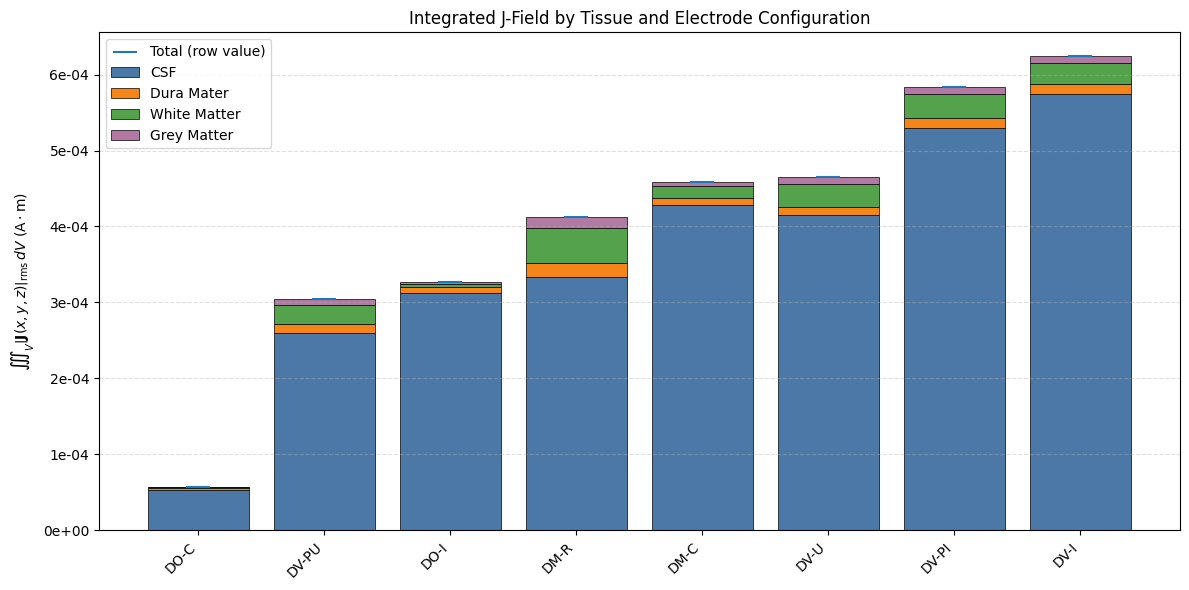

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

def plot_stacked_jfield_integrals(
    j_field_dfs: dict[str, pd.DataFrame],
    order: list[str] | None = None,
    integral_col: str = "Integral",
    tissue_col: str = "Tissue",
    config_col: str = "Name",
    title: str = "Integrated J-Field by Tissue and Electrode Configuration",
    figsize=(12, 6),
    annotate_total=False,
    rescale_segments_to_total=True,
):
    """
    Plot one stacked vertical bar chart from a dict of J-field statistics DataFrames.

    Each bar = one electrode config (dict key)
    Bar height = 'Total' row in Integral column
    Stacked segments = Integral values for:
        - CSF
        - Dura Mater
        - White Matter
        - Grey Matter

    Parameters
    ----------
    j_field_dfs : dict[str, pd.DataFrame]
        Dictionary of DataFrames keyed by electrode config (e.g., 'DM-C').
    order : list[str] | None
        Optional plotting order for keys. If None, uses sorted keys.
    integral_col : str
        Column containing integrated values.
    tissue_col : str
        Column containing tissue labels.
    config_col : str
        Column containing config name (not required if using dict keys, but kept for flexibility).
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    annotate_total : bool
        If True, annotate each bar with total Integral value.
    rescale_segments_to_total : bool
        If True, rescales the 4 tissue segment values so they sum exactly to the 'Total' value.
        Useful if there are tiny rounding mismatches.
    """

    tissue_order = ["CSF", "Dura Mater", "White Matter", "Grey Matter"]

    # Use a fixed color mapping for consistency
    colors = {
        "CSF": "#4C78A8",
        "Dura Mater": "#F58518",
        "White Matter": "#54A24B",
        "Grey Matter": "#B279A2",
    }

    # Decide plotting order
    keys = order if order is not None else sorted(j_field_dfs.keys())

    if order is None:
        keys = sorted(
            keys,
            key=lambda k: pd.to_numeric(
                j_field_dfs[k].loc[
                    j_field_dfs[k][tissue_col].astype(str).str.strip().str.lower() == "total",
                    integral_col
                ],
                errors="coerce"
            ).iloc[0]
            if (
                k in j_field_dfs
                and tissue_col in j_field_dfs[k].columns
                and integral_col in j_field_dfs[k].columns
                and not j_field_dfs[k].loc[
                    j_field_dfs[k][tissue_col].astype(str).str.strip().str.lower() == "total",
                    integral_col
                ].empty
            )
            else np.inf
        )

    # Storage for plotting values
    totals = []
    stacked_vals = {t: [] for t in tissue_order}

    # Track issues
    skipped = []
    mismatch_info = []

    for key in keys:
        if key not in j_field_dfs:
            skipped.append((key, "missing from j_field_dfs"))
            continue

        df = j_field_dfs[key].copy()

        # Basic column checks
        required_cols = [tissue_col, integral_col]
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            skipped.append((key, f"missing columns: {missing_cols}"))
            continue

        # Clean tissue labels + integral values
        df[tissue_col] = df[tissue_col].astype(str).str.strip()
        df[integral_col] = pd.to_numeric(df[integral_col], errors="coerce")

        # Get Total integral
        total_match = df.loc[df[tissue_col].str.lower() == "total", integral_col]
        if total_match.empty:
            skipped.append((key, "no 'Total' row found"))
            continue

        total_val = float(total_match.iloc[0])

        # Get tissue integrals
        seg_vals = []
        missing_tissues = []
        for tissue in tissue_order:
            match = df.loc[df[tissue_col].str.lower() == tissue.lower(), integral_col]
            if match.empty:
                missing_tissues.append(tissue)
                seg_vals.append(np.nan)
            else:
                seg_vals.append(float(match.iloc[0]))

        if missing_tissues:
            skipped.append((key, f"missing tissue rows: {missing_tissues}"))
            continue

        seg_sum = float(np.nansum(seg_vals))

        # Optionally rescale so stacked bar sums exactly to Total
        if rescale_segments_to_total and np.isfinite(seg_sum) and seg_sum != 0:
            if not np.isclose(seg_sum, total_val, rtol=1e-6, atol=1e-12):
                mismatch_info.append((key, total_val, seg_sum))
            scale = total_val / seg_sum
            seg_vals = [v * scale for v in seg_vals]
        else:
            if not np.isclose(seg_sum, total_val, rtol=1e-6, atol=1e-12):
                mismatch_info.append((key, total_val, seg_sum))

        totals.append(total_val)
        for tissue, v in zip(tissue_order, seg_vals):
            stacked_vals[tissue].append(v)

    # If nothing valid, stop
    if len(totals) == 0:
        raise ValueError("No valid DataFrames found to plot. Check schema/row labels.")

    # Keep only keys successfully processed
    valid_keys = [k for k in keys if k not in [s[0] for s in skipped]]

    # Plot
    x = np.arange(len(valid_keys))
    fig, ax = plt.subplots(figsize=figsize)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0e'))

    bottom = np.zeros(len(valid_keys), dtype=float)
    for tissue in tissue_order:
        vals = np.array(stacked_vals[tissue], dtype=float)
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=tissue,
            color=colors.get(tissue, None),
            edgecolor="black",
            linewidth=0.5,
        )
        bottom += vals

    # Optional total markers (shows exact total even if tiny mismatch exists)
    ax.scatter(x, totals, marker="_", s=300, linewidths=1.5, label="Total (row value)", zorder=5)

    if annotate_total:
        for xi, total in zip(x, totals):
            ax.text(xi, total, f"{total:.3e}", ha="center", va="bottom", fontsize=8, rotation=0)

    ax.set_xticks(x)
    ax.set_xticklabels(valid_keys, rotation=45, ha="right")
    plt.ylabel(r"$\iiint_V \left|\mathbf{J}(x,y,z)\right|_{\mathrm{rms}}\, dV\ \mathrm{(A\cdot m)}$")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Print useful diagnostics
    if skipped:
        print("\nSkipped entries:")
        for k, reason in skipped:
            print(f"  - {k}: {reason}")

    if mismatch_info:
        print("\nTotal vs tissue-sum mismatches detected (before rescaling):")
        for k, total_val, seg_sum in mismatch_info:
            print(f"  - {k}: Total={total_val:.6e}, TissueSum={seg_sum:.6e}, Diff={(total_val - seg_sum):.6e}")


# --- Usage ---
# Assumes you already created j_field_dfs using your loader function.
plot_stacked_jfield_integrals(
    j_field_dfs,
    # order=["DM-C", "DM-R", "DV-I"],   # optional manual order
    annotate_total=False,
    rescale_segments_to_total=True,      # keeps bar tops exactly at Total row values
)

### Lower Limb Entities

In [61]:
# loading csv's into a dict of dataframes.

from pathlib import Path
import pandas as pd

def load_j_field_stats(folder="Mask_Filter_J_Field"):
    """
    Load CSVs in `folder` that:
      - end with 'J_Field_Statistics.csv'
      - do NOT contain 'Lower_Limbs' in the filename

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys are electrode configs parsed from filenames, e.g.
        'DM-C_J_Field_Statistics.csv' -> {'DM-C': DataFrame}
    """
    folder_path = Path(folder)
    data_dict: dict[str, pd.DataFrame] = {}

    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path.resolve()}")

    # Iterate through CSV files only
    for csv_path in folder_path.glob("*.csv"):
        stem = csv_path.stem  # filename without .csv

        # Exclude files containing "Lower_Limbs"
        if "Lower_Limbs" not in stem:
            continue

        # Keep only files ending in "J_Field_Statistics"
        if not stem.endswith("J_Field_Statistics"):
            continue

        # Extract electrode config key (everything before suffix)
        # Example: "DM-C_J_Field_Statistics" -> "DM-C"
        key = stem[: -len("_Lower_Limbs_J_Field_Statistics")]

        # Load CSV into DataFrame
        df = pd.read_csv(csv_path)

        # Store in dict (warn on duplicate keys)
        if key in data_dict:
            print(f"Warning: duplicate key '{key}' found. Overwriting with: {csv_path.name}")

        data_dict[key] = df

    return data_dict


# --- Usage ---
lower_limb_j_field_dfs = load_j_field_stats("Mask_Filter_J_Field")

# Inspect what was loaded
print("Loaded keys:", list(lower_limb_j_field_dfs.keys()))

# Example access
# print(j_field_dfs["DM-C"].head())

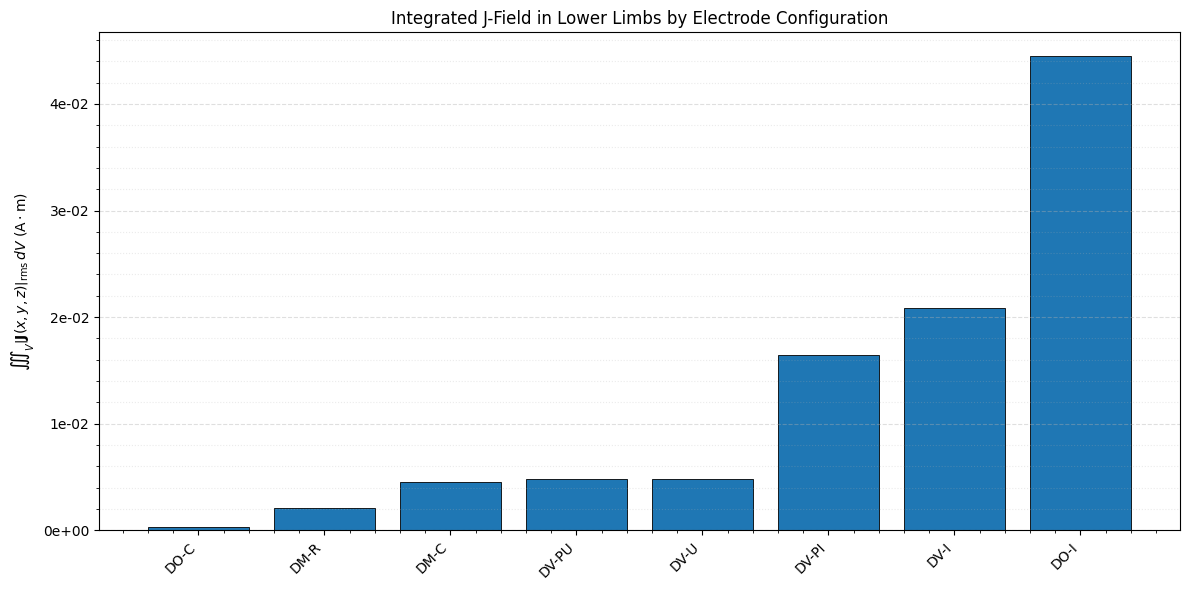

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

def plot_lower_limb_jfield_integrals(
    lower_limb_j_field_dfs: dict[str, pd.DataFrame],
    order: list[str] | None = None,
    integral_col: str = "Integral",
    tissue_col: str = "Tissue",
    expected_tissue_label: str = "Lower Limbs",
    title: str = "Integrated J-Field in Lower Limbs by Electrode Configuration",
    figsize=(12, 6),
    annotate=False,
    sort_ascending_if_no_order=True,
):
    """
    Plot a simple vertical bar chart for lower-limb J-field statistics.

    Assumes each DataFrame contains a single relevant row (typically Tissue == 'Lower Limbs')
    and uses its `Integral` value as the bar height.

    Parameters
    ----------
    lower_limb_j_field_dfs : dict[str, pd.DataFrame]
        Dict of DataFrames keyed by electrode config (e.g., 'DM-C').
    order : list[str] | None
        Optional plotting order. If None, keys are sorted by integral ascending (default).
    integral_col : str
        Column containing integrated values.
    tissue_col : str
        Column containing tissue label (e.g., 'Lower Limbs').
    expected_tissue_label : str
        Preferred tissue row label to use if present.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    annotate : bool
        If True, annotate each bar with its integral value in scientific notation.
    sort_ascending_if_no_order : bool
        If True and `order` is None, sort bars ascending by integral.
    """

    # Decide initial key order
    keys = order if order is not None else sorted(lower_limb_j_field_dfs.keys())

    # Helper to extract a single integral value from one df
    def _extract_lower_limb_integral(df: pd.DataFrame) -> float:
        if integral_col not in df.columns:
            return np.nan

        df_local = df.copy()
        df_local[integral_col] = pd.to_numeric(df_local[integral_col], errors="coerce")

        # If tissue column exists, prefer the "Lower Limbs" row
        if tissue_col in df_local.columns:
            tissue_clean = df_local[tissue_col].astype(str).str.strip().str.lower()
            match = df_local.loc[tissue_clean == expected_tissue_label.lower(), integral_col]
            if not match.empty:
                return float(match.iloc[0])

        # Fallback: if only one row, use it
        if len(df_local) == 1:
            return float(df_local[integral_col].iloc[0])

        # Fallback: first non-NaN integral
        non_nan = df_local[integral_col].dropna()
        if not non_nan.empty:
            return float(non_nan.iloc[0])

        return np.nan

    # Sort by integral ascending if user didn't provide order
    if order is None and sort_ascending_if_no_order:
        keys = sorted(
            keys,
            key=lambda k: _extract_lower_limb_integral(lower_limb_j_field_dfs[k])
            if k in lower_limb_j_field_dfs else np.inf
        )

    # Collect values
    valid_keys = []
    values = []
    skipped = []

    for key in keys:
        if key not in lower_limb_j_field_dfs:
            skipped.append((key, "missing from lower_limb_j_field_dfs"))
            continue

        df = lower_limb_j_field_dfs[key]

        if integral_col not in df.columns:
            skipped.append((key, f"missing column '{integral_col}'"))
            continue

        val = _extract_lower_limb_integral(df)

        if not np.isfinite(val):
            skipped.append((key, "could not extract a valid lower-limb integral"))
            continue

        valid_keys.append(key)
        values.append(val)

    if len(valid_keys) == 0:
        raise ValueError("No valid lower-limb DataFrames found to plot.")

    # Plot
    x = np.arange(len(valid_keys))
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        x,
        values,
        edgecolor="black",
        linewidth=0.6,
    )

    # Scientific notation on y-axis tick labels (e.g., 4e-04)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0e'))

    if annotate:
        for rect, val in zip(bars, values):
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_height(),
                f"{val:.2e}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=0,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(valid_keys, rotation=45, ha="right")
    plt.ylabel(r"$\iiint_V \left|\mathbf{J}(x,y,z)\right|_{\mathrm{rms}}\, dV\ \mathrm{(A\cdot m)}$")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.minorticks_on(); ax.grid(axis="y", which="minor", linestyle=":", alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Diagnostics
    if skipped:
        print("\nSkipped entries:")
        for k, reason in skipped:
            print(f"  - {k}: {reason}")


plot_lower_limb_jfield_integrals(
    lower_limb_j_field_dfs,
    annotate=False,   # set True to print values above bars
)


## Making a List of All Entities

In [57]:
# columns = ['Entity', 'Sub Group', 'Main Group']
# entities = pd.DataFrame(columns = columns)

e_list = []
sub_groups = []

for i in model.AllEntities():
    entity = i.Name
    
    if entity == 'Model':
        continue
        
    sub_group = i.ParentGroup().Name
    try:
        main_group = i.ParentGroup().ParentGroup().Name
    except:
        pass
    
    if main_group == 'Jeduk_33y_m_posable_v4.1b01':
        main_group = sub_group
        sub_group = 'None'
        
    if sub_group == 'Jeduk_33y_m_posable_v4.1b01':
        main_group = 'None'
        sub_group = 'None'
    
    target = "Jeduk_33y_m_posable_v4.1b01"

    try:
        if target in (
            i.ParentGroup().Name,
            i.ParentGroup().ParentGroup().Name,
            i.ParentGroup().ParentGroup().ParentGroup().Name,
        ):
            
            ent = {"Main Group" : main_group,
                    "Sub Group" : sub_group,
                    "Entity" : entity,
                    }

            e_list.append(ent)
            
            
            pass
    except AttributeError:
        # Missing .Name (or missing ParentGroup result with no .Name)
        pass

entities = pd.DataFrame(e_list)

entities = entities.sort_values(by = ['Main Group', 'Sub Group'] ,ignore_index = True )


from IPython.display import display, HTML

# display(HTML(entities.to_html(max_rows=None, max_cols=None)))


sub_vals = entities["Sub Group"].dropna().unique().tolist()
main_vals = entities["Main Group"].dropna().unique().tolist()

sub_vals.remove("None")

remove_vals = set(sub_vals) | set(main_vals)  # set is fast, also removes duplicates
entities = entities[~entities["Entity"].isin(remove_vals)].copy()

# Optional: reset index
entities = entities.reset_index(drop=True)
os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2")
entities.to_csv("List_of_Jeduk_Entities")

['Artery',
 'Heart',
 'Vein',
 'Brain',
 'Brainstem',
 'Spinal_cord',
 'Bone',
 'Cartilaginous_tissue',
 'Intervertebral_disc',
 'Muscle',
 'Nerve',
 'Sympathetic_nervous_system',
 'Eye']

In [ ]:
vals = df["your_column"].dropna().unique().tolist()

## Dorsal Root NEURON Simulation

### Nerve Discretization

List of criteria:

- T7-T12 Dorsal Roots
- L1 Dorsal Root (Pick 1)
- L2 Dorsal Root Genitofemoral


In [56]:
dorsal_ents = []

count = 0
for i in model.AllEntities():
    
    if ((('T7' in i.Name)
        or ('T8' in i.Name)
        or ('T9' in i.Name)
        or ('T10' in i.Name)
        or ('T11' in i.Name)
        or ('T12' in i.Name)
       )
        and ('_dorsal_root_' in i.Name)
        and (str(type(i)) != "<class 'XCoreModeling.TriangleMesh'>")
       ):
        dorsal_ents.append(i)
        count +=1
        
    if ((('Dorsal_root_L1' in i.Name)
        or ('Dorsal_root_L2' in i.Name)
        )
       and ('cutaneous' not in i.Name)
       and (str(type(i)) != "<class 'XCoreModeling.TriangleMesh'>")
       and (int(i.Name[-2:]) < 2)
       ):

        dorsal_ents.append(i)
        count+=1
              
for i in dorsal_ents:
    print(i.Name)

count

46

In [58]:
# Create 10um nerves

sensory_props = model.SensoryMrgNeuronProperties()
sensory_props.AxonDiameter = 10
discretized_motor_10 = model.CreateAxonNeurons(dorsal_ents, sensory_props)

model.CreateGroup('Dorsal_Root_Nerves_(T7-L2)_10um')

for i in discretized_motor_10:
    model.AllEntities()['Dorsal_Root_Nerves_(T7-L2)_10um'].Add(i)

In [59]:
# Create 15um nerves

sensory_props = model.SensoryMrgNeuronProperties()
sensory_props.AxonDiameter = 15
discretized_motor_10 = model.CreateAxonNeurons(dorsal_ents, sensory_props)

model.CreateGroup('Dorsal_Root_Nerves_(T7-L2)_15um')

for i in discretized_motor_10:
    model.AllEntities()['Dorsal_Root_Nerves_(T7-L2)_15um'].Add(i)

In [60]:
# Create 20um motor nerves

sensory_props = model.SensoryMrgNeuronProperties()
sensory_props.AxonDiameter = 20
discretized_motor_10 = model.CreateAxonNeurons(dorsal_ents, sensory_props)

model.CreateGroup('Dorsal_Root_Nerves_(T7-L2)_20um')

for i in discretized_motor_10:
    model.AllEntities()['Dorsal_Root_Nerves_(T7-L2)_20um'].Add(i)

### NEURON Setup

In [63]:
neurosimulation = neuron.Simulation()
neurosimulation.Name = "NEURON - Dorsal Roots - DV-PU"
document.AllSimulations.Add( neurosimulation )

#### Adding Fibers

In [64]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Dorsal_Root_Nerves_10um'

discretized_sensory_10 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Dorsal_Root_Nerves_(T7-L2)_10um':
            discretized_sensory_10.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_sensory_10);

In [65]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Dorsal_Root_Nerves_15um'

discretized_sensory_15 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Dorsal_Root_Nerves_(T7-L2)_15um':
            discretized_sensory_15.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_sensory_15);

In [66]:
automatic_axon_neuron_settings = neuron.AutomaticAxonNeuronSettings()
automatic_axon_neuron_settings.Name = 'Dorsal_Root_Nerves_20um'

discretized_sensory_20 = []

for i in model.AllEntities():
    if i.ParentGroup() != None:
        if i.ParentGroup().Name == 'Dorsal_Root_Nerves_(T7-L2)_20um':
            discretized_sensory_20.append(i)

neurosimulation.Add(automatic_axon_neuron_settings, discretized_sensory_20);

#### Additional Setup

In [67]:
source_settings = neurosimulation.AddGenericSource([])
source_settings.SourceType = source_settings.SourceType.enum.DataObject
source_settings.SourceDataObject.DataOriginType = source_settings.SourceDataObject.DataOriginType.enum.Pipeline
source_settings.SourceDataObject.DataOrigin = document.AllAlgorithms[f"Voltage Multiplier - DV-PU"].Outputs[0].raw
source_settings.InitialTime = 0.001, units.Seconds
source_settings.DurationP1 = 0.001, units.Seconds
source_settings.AmplitudeP1 = 1
source_settings.PulseType = 0

overall_line_sensor_settings = neuron.OverallLineSensorSettings()
components = []
overall_line_sensor_settings.RecordEExtracellular = False
overall_line_sensor_settings.RecordIMembrane = False
overall_line_sensor_settings.NumberOfSnapshots = 250
neurosimulation.Add(overall_line_sensor_settings, components)

solver_settings = neurosimulation.SolverSettings

solver_settings.Parallelization = solver_settings.Parallelization.enum.Automatic
solver_settings.Duration = 0.006, units.Seconds
solver_settings.TimeStep = 1e-05, units.Seconds


#### Cloning

In [72]:
neurosimulation = document.AllSimulations["NEURON - Dorsal Roots - DV-PU"] 

for i in electrode_combinations.keys():
    if i != 'DV-PU':
        
        new_sim = neurosimulation.Clone()
        new_sim.Name = (f'NEURON - Dorsal Roots - {i}')
                        
        ss = new_sim.AllSettings['Source Settings']
        if ss != None:
            new_sim.RemoveSettings(ss)

        # Adding a new SourceSettings
        source_settings = new_sim.AddGenericSource([])
        source_settings.SourceType = source_settings.SourceType.enum.DataObject
        source_settings.SourceDataObject.DataOriginType = source_settings.SourceDataObject.DataOriginType.enum.Pipeline
        source_settings.SourceDataObject.DataOrigin = document.AllAlgorithms[f"Voltage Multiplier - {i}"].Outputs[0].raw
        source_settings.InitialTime = 0.001, units.Seconds
        source_settings.DurationP1 = 0.001, units.Seconds
        source_settings.AmplitudeP1 = 1
        source_settings.PulseType = 0

        document.AllSimulations.Add(new_sim)


### Data Extraction

In [86]:
# For Cole: Fix this, make it automatically check if sensors are present. If they are, use the necessary internal functions to extract that data.

def Neuron_Data_Extraction(sim_name):
    
    def tit_extract(name):
        simulation = document.AllSimulations[name]
        simulation_extractor = simulation.Results()
        simulation_extractor.UpdateAttributes()
        simulation_extractor.UpdateAll()
        
        combo = sim_name.split(' - ')[2]

        exists = any(getattr(alg, "Name", None) == f'Titration Sensor - Dorsal Roots - {combo}'
                 for alg in document.AllAlgorithms)
        print (exists)

        if exists:

            print("found it")
            target = f'Titration Sensor - Dorsal Roots - {combo}'

            idx = next(
                (i for i, alg in enumerate(document.AllAlgorithms)
                 if getattr(alg, "Name", None) == target),
                -1  # return -1 if not found
            )
            # print(idx)  # e.g., 7, or -1 if absent
            tit_sensor = document.AllAlgorithms[idx]
            titration_evaluator = document.AllAlgorithms[idx+1]

            document.AllAlgorithms.Remove(tit_sensor)
            document.AllAlgorithms.Remove(titration_evaluator)


        sensor_extractor = simulation_extractor["Titration Sensor"]
        sensor_extractor.Name = f'Titration Sensor - Dorsal Roots - {combo}'
        document.AllAlgorithms.Add(sensor_extractor)
        titration_evaluator = document.AllAlgorithms[f'Titration Evaluator - Dorsal Roots - {combo}']
        inputs = [sensor_extractor.Outputs["Titration"]]
        titration_evaluator = analysis.neuron_evaluators.TitrationEvaluator(inputs=inputs)
        titration_evaluator.UpdateAttributes()
        titration_evaluator.UpdateAll()
        document.AllAlgorithms.Add(titration_evaluator)

        return titration_evaluator

    def titration_eval(combo, freq, total_unnormalized_current, document, titration_evaluator):
    
        titration_data = pd.DataFrame(columns = ['NeuronName', 
                                                 'NeuronType', 
                                                 'Fibre_Diameter', 
                                                 'Location', 
                                                 'Electrode_Config', 
                                                 'Frequency', 
                                                 'Titration_Factor', 
                                                 'Activation_Threshold (mA)',
                                                 'First_Spike_Loc'])

        tit_data = []

        for i in range(len(titration_evaluator.TitrationData())):

            neuron_name = titration_evaluator.TitrationData()[i].NeuronName
            spike_loc = titration_evaluator.LocationOfFirstSpike[i]
            titration_factor = titration_evaluator.TitrationData()[i].TitrationFactor
            a_t = titration_factor * total_unnormalized_current * 1000

            after = neuron_name.split("root_", 1)[1]
            location = "_".join(after.split("_", 2)[:2])  # "T11_left"

            match = re.search(r'\[(.*?)\]', neuron_name)
            if match:
                neuron_type = match.group(1)  # Text inside the brackets

            m = re.match(r'^(.*\S)\s+([+-]?\d+(?:\.\d+)?\s*(?:um|µm|mm|nm|m)?)\s*$', neuron_type, re.IGNORECASE)

            fibre_type = m.group(1)        # "Sensory MRG Neuron"
            fibre_diameter = m.group(2)

            tit_data.append({'NeuronName': neuron_name,
                            'NeuronType': fibre_type,
                            'Fibre_Diameter': fibre_diameter,
                            'Location': location,
                            'Electrode_Config': combo,
                            'Frequency' : freq,
                            'Titration_Factor' : titration_factor,
                             'Activation_Threshold (mA)' : a_t,
                             'First_Spike_Loc' : spike_loc
                            })

        titration_data = pd.concat([titration_data, pd.DataFrame(tit_data)], ignore_index=True)
        titration_data = titration_data.sort_values(by="Activation_Threshold (mA)", ascending=True)

        return titration_data
     
    os.chdir(r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher")

    simulation = document.AllSimulations[sim_name]
    combo = sim_name.split('Roots - ')[1]
    folder_name = combo

    try:
        os.mkdir(folder_name)
    except:
        pass

    base = r"C:\Users\kramerlab\Documents\ZMT\Sim4Life\9.2\Simulation_Results\Thatcher"
    subdir_path = os.path.join(base, folder_name)
    
    try:
        titration_evaluator = tit_extract(sim_name)
        freq = 30
        total_unnormalized_current = 0.1
        now = datetime.datetime.now()
        s2 = now.strftime("%Y_%m_%d")
        note = ''

        titration_df = titration_eval(combo,freq, total_unnormalized_current, document, titration_evaluator)

        table_name = (f'Titration - Dorsal Roots - {combo} {s2} {note}.csv')
        csv_path = os.path.join(subdir_path, table_name)

        print(csv_path)
        titration_df.to_csv(csv_path)
    except:
        csv_path = None
        pass
                  
    return csv_path


In [89]:
for i in electrode_combinations.keys():
    
    sim_name = f'NEURON - Dorsal Roots - {i}'
    test_path = Neuron_Data_Extraction(sim_name)


In [80]:
my_list = [1,3,4,6]

if 10 in my_list:
    print('tRUE')
else:
    print('False')

In [82]:
sim_name = f'NEURON - Dorsal Roots - {i}'
combo = sim_name.split(' - ')[2]
combo

'DV-I'

In [8]:
count = 0

soleus_nerves = []

for i in model.AllEntities():
    
    try:
        if i.ParentGroup().Name == 'Soleus_Sensory_Nerves_10um':
            print(i.Name)
            name = i.Name
            name = name[: -len(" [Sensory MRG Neuron 10.00um]")]
            soleus_nerves.append(name)
            count += 1
    except:
        continue


In [ ]:
# Select Nerve Trajectories

sciatic_name_patterns = [
    "L5_sciatic_nerve",
    "L5_sciatic_muscular_branches",
    "S1_sciatic_nerve",
    "S1_sciatic_muscular_branches",
    "S2_sciatic_nerve",
    "S2_sciatic_muscular_branches",
    "L5_muscular_branches_of_nerve_sciatic",
    "S1_muscular_branches_of_nerve_sciatic",
    "S2_muscular_branches_of_nerve_sciatic",
]

sciatic_ents = [
    ent for ent in model.AllEntities()
    if any(pat in ent.Name for pat in sciatic_name_patterns)
]

for i in model.AllEntities():
    try:
        group = i.ParentGroup().Name
    except:
        continue
        
    if group == 'Soleus_Sensory_Nerves_10um':
        if any(pat in i.Name for pat in sciatic_name_patterns):
            pass
        else:
            i.Selected=True
            i.ReadOnly = False

In [9]:
soleus_nerves

['Nerve_root_S1_muscular_branches_of_nerve_sciatic_left_04',
 'Nerve_root_L5_sciatic_muscular_branches_of_nerve_tibial_left_05',
 'Nerve_root_S1_sciatic_muscular_branches_of_nerve_tibial_left_01',
 'Nerve_root_S2_muscular_branches_of_nerve_sciatic_left_04',
 'Nerve_root_L4_L5_sciatic_muscular_branches_of_nerve_tibial_left_02',
 'Nerve_root_S2_muscular_branches_of_nerve_sciatic_left_02',
 'Nerve_root_L4_L5_sciatic_nerve_tibial_right_07',
 'Nerve_root_S2_sciatic_nerve_tibial_right_07',
 'Nerve_root_S1_muscular_branches_of_nerve_sciatic_right_03',
 'Nerve_root_L4_L5_sciatic_muscular_branches_of_nerve_tibial_right_03',
 'Nerve_root_L5_sciatic_muscular_branches_of_nerve_tibial_right_04',
 'Nerve_root_S1_sciatic_nerve_tibial_left_01',
 'Nerve_root_S2_sciatic_nerve_tibial_right_04',
 'Nerve_root_L5_sciatic_nerve_tibial_right_07',
 'Nerve_root_S2_muscular_branches_of_nerve_sciatic_left_01',
 'Nerve_root_S2_sciatic_nerve_tibial_left_05',
 'Nerve_root_L5_sciatic_nerve_tibial_right_02',
 'Nerve_r

## Checking Kernel Specs

In [21]:
import os, psutil

p = psutil.Process(os.getpid())
print("CPU % (instant):", p.cpu_percent(interval=0.5))
print("RSS RAM (GB):", p.memory_info().rss / 1e9)
print("Threads:", p.num_threads())


In [ ]:
import os, psutil
p = psutil.Process(os.getpid())
print("RSS RAM (GB):", p.memory_info().rss / 1e9)


In [22]:
import os, psutil, time
p = psutil.Process(os.getpid())

print("PID:", p.pid)
print("Process name:", p.name())
print("Executable:", p.exe())
print("Cmdline (first 5):", p.cmdline()[:5])
print("Create time:", time.ctime(p.create_time()))
print("Threads:", p.num_threads())
print("RSS (GB):", p.memory_info().rss / 1e9)


In [23]:
import os, psutil, time

pid = os.getpid()
p = psutil.Process(pid)

print("JUPYTER KERNEL PID:", pid)
print("Kernel process name:", p.name())
print("Kernel executable:", p.exe())
print("Kernel create time:", time.ctime(p.create_time()))
print("Kernel threads:", p.num_threads())
print("Kernel RSS (GB):", p.memory_info().rss / 1e9)


## Additional Code (Might be Useful)

### Changing Entity Names

In [15]:
for i in model.AllEntities():
    if i.Name.__contains__('Anode_') or i.Name.__contains__('Cathode_'):
        
        s = i.Name
        parts = s.split("_")
        s = "_".join([p for p in parts if p not in ("electrode", "gel")] +
             [p for p in parts if p in ("electrode", "gel")])

        i.Name = s

In [19]:
count = 0
for i in document.AllAlgorithms:
    
    # print(i.Name)
    
    if i.Name.startswith('Current Extractor - '):
        
        prefix = "Current Extractor - "
        sim_name = i.Name.split(prefix, 1)[1]
        print(sim_name)
        document.AllAlgorithms[count-1].Name = f'Overall Field - {sim_name}'
        
    count += 1

#### Remove duplicate Algorithms

In [54]:
# To remove duplicates safely

algos = document.AllAlgorithms

# Snapshot the names first (no mutation during iteration)
to_remove = []
for a in algos:
    # if a is not None and a.Name.startswith("Current Multiplier"):
    if a is not None and "YZ Plane" in a.Name:
        to_remove.append(a.Name)

# Now remove by name
for name in to_remove:
    # guard in case it was already removed / renamed
    if name in algos:
        algos.Remove(algos[name])
